# Import Statements

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import pickle
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import plot_importance
from matplotlib import pyplot

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# Define all functions

In [3]:
class EarlyStopping:
    def __init__(self, patience=10, delta=1e-4):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [21]:
#If not optimising for layers
# Build model with best hyperparameters 2 layers or 3 layer.
#def build_model(input_size, params):
    return nn.Sequential(
        nn.Linear(input_size, params['hidden_size1']),
        nn.ReLU(),
        nn.Dropout(params['dropout1']),
        nn.Linear(params['hidden_size1'], params['hidden_size2']),
        nn.ReLU(),
        nn.Dropout(params['dropout2']),
        nn.Linear(params['hidden_size2'], params['hidden_size3']),
        nn.ReLU(),
        nn.Linear(params['hidden_size3'], 1)
    )
    return nn.Sequential(*layers)
#USAGE - model = build_model(X.shape[1], params)

# Build model with best hyperparameters
#def build_model(input_size, params):
    return nn.Sequential(
        nn.Linear(input_size, params['hidden_size1']),
        nn.ReLU(),
        nn.Dropout(params['dropout1']),
        nn.Linear(params['hidden_size1'], params['hidden_size2']),
        nn.ReLU(),
        nn.Linear(params['hidden_size2'], 1)
    )
    return nn.Sequential(*layers)

IndentationError: unexpected indent (2407977649.py, line 3)

In [4]:
def build_model(input_size, params):
    layers = []
    layers.append(nn.Linear(input_size, params['hidden_size1']))
    layers.append(nn.ReLU())
    layers.append(nn.Dropout(params['dropout1']))

    if params['n_layers'] > 1:
        layers.append(nn.Linear(params['hidden_size1'], params['hidden_size2']))
        layers.append(nn.ReLU())
        # Only add dropout2 if n_layers > 2
        if params['n_layers'] > 2:
            layers.append(nn.Dropout(params['dropout2']))

    if params['n_layers'] > 2:
        layers.append(nn.Linear(params['hidden_size2'], params['hidden_size3']))
        layers.append(nn.ReLU())

    # Output layer
    last_hidden = f"hidden_size{params['n_layers']}"
    layers.append(nn.Linear(params[last_hidden], 1))

    return nn.Sequential(*layers)

In [5]:
def objective(trial):
    #Hyperparametr space
    params = {
            'hidden_size1': trial.suggest_categorical('hidden_size1', [100, 200, 300]),
            #'hidden_size1': trial.suggest_int('hidden_size1', 64, 256, step=32),
            #'hidden_size2': trial.suggest_int('hidden_size2', 32, 128, step=16),
            #'hidden_size3': trial.suggest_int('hidden_size3', 32, 128, step=16),
            'dropout1': trial.suggest_float('dropout1', 0.01, 0.1),
            #'dropout2': trial.suggest_float('dropout2', 0.01, 0.1),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128]),
            'optimizer': trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD']),
            #'num_epochs': trial.suggest_categorical('num_epochs', [30, 50, 70]),
            #'patience': trial.suggest_int('patience', 5, 15),
            'num_epochs': 100,
            'patience': 10,
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True),
            'n_layers': trial.suggest_int('n_layers', 1, 3)
        }

        # Only sample hidden_size2 if n_layers > 1
    if params['n_layers'] > 1:
        params['hidden_size2'] = trial.suggest_categorical('hidden_size2', [50, 100, 150])
    else:
        params['hidden_size2'] = None
    
    # Only sample hidden_size3 and dropout2 if n_layers > 2
    if params['n_layers'] > 2:
        params['hidden_size3'] = trial.suggest_categorical('hidden_size3', [25, 50, 75])
        params['dropout2'] = trial.suggest_float('dropout2', 0.01, 0.1)
    else:
        params['hidden_size3'] = None
        params['dropout2'] = None
        
    # Build model
    model = build_model(X_train.shape[1], params).to(device)
    optimizer = getattr(optim, params['optimizer'])(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay']
    )
    loss_function = nn.MSELoss()
    early_stopping = EarlyStopping(patience=params['patience'])

    # Prepare data
    #X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    #y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    #X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    #y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)

    val_losses = []

    for epoch in range(params['num_epochs']):
        # Training
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = loss_function(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Validation (after each epoch)
        model.eval()
        with torch.no_grad():
            preds = model(X_val).cpu().numpy()
            true = y_val.cpu().numpy()
            val_loss = loss_function(torch.tensor(preds), y_val.cpu())
            val_losses.append(val_loss.item())

        avg_val_loss = np.mean(val_losses[-5:])  # average of last 5 epochs for stability
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    mse = mean_squared_error(true, preds)
    return mse  # Optuna tries to minimize this value



In [6]:
def complete_params(params):
    params = dict(params) 
    params.setdefault('num_epochs', 100)
    params.setdefault('patience', 10)
    return params

In [7]:
def cross_validate(X, y, best_params, n_splits, checkpoint_path='best_model_checkpoint.pth'):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_losses = []
    best_model_weights = None
    best_loss = float('inf')
    fold = 1

    for train, test in kf.split(X, y):
        print(f"Training fold {fold}")

        model = build_model(X.shape[1], best_params).to(device)
        lr = best_params.get('lr', 0.001)
        opt_name = best_params.get('optimizer', 'Adam')

        if opt_name == 'Adam':
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=best_params.get('weight_decay', 0.0))
        elif opt_name == 'SGD':
            optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=best_params.get('weight_decay', 0.0))
        elif opt_name == 'RMSprop':
            optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=best_params.get('weight_decay', 0.0))
        else:
            raise ValueError(f"Unsupported optimizer: {opt_name}")

        loss_fn = nn.MSELoss()
        patience = best_params.get('patience', 10)
        early_stopping_counter = 0
        best_val_loss = float('inf')

        train_dataset = torch.utils.data.TensorDataset(X[train], y[train])
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)

        # Validation data for this fold
        X_val = X[test].to(device)
        y_val = y[test].to(device)

        for epoch in range(best_params['num_epochs']):
            model.train()
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = loss_fn(outputs, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            model.eval()
            with torch.no_grad():
                val_output = model(X_val)
                val_loss = loss_fn(val_output, y_val)
                val_loss_value = val_loss.item()
                #print(f"Fold {fold} Epoch {epoch+1} validation loss: {val_loss_value:.4f}")

                if val_loss_value < best_val_loss - 1e-6:
                    best_val_loss = val_loss_value
                    early_stopping_counter = 0
                    # Save the best model weights for this fold
                    best_fold_weights = model.state_dict()
                else:
                    early_stopping_counter += 1

                if early_stopping_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1} for fold {fold}")
                    break
                
        print(f"Fold {fold} validation loss: {best_val_loss:.4f}")
        fold_losses.append(best_val_loss)
        # Save the best model weights across all folds
        if best_val_loss < best_loss:
            best_loss = best_val_loss
            best_model_weights = best_fold_weights

        fold += 1

    average_val_loss = np.mean(fold_losses)
    print(f"\nAverage validation loss across all folds: {average_val_loss:.4f}")

    final_model = build_model(X.shape[1], best_params)
    final_model.load_state_dict(best_model_weights)

    checkpoint = {
        'model_state_dict': final_model.state_dict(),
        'best_params': best_params,
        'input_dim': X.shape[1]
    }
    torch.save(checkpoint, checkpoint_path)
    print(f"Checkpoint saved as '{checkpoint_path}'.")

    return final_model, average_val_loss


In [8]:
# Evaluation
def evaluate_on_holdout(X_holdout, y_holdout, best_model):
    # Prepare the data
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_holdout_tensor = torch.tensor(X_holdout, dtype=torch.float32).to(device)
    y_holdout_tensor = torch.tensor(y_holdout, dtype=torch.float32).view(-1, 1).to(device)
    
    best_model = best_model.to(device)
    best_model.eval()
    with torch.no_grad():
        predictions = best_model(X_holdout_tensor)

    loss_function = nn.MSELoss()
    holdout_loss = loss_function(predictions, y_holdout_tensor)
    
    y_true_np = y_holdout_tensor.cpu().numpy()
    y_pred_np = predictions.cpu().numpy()

    mse = mean_squared_error(y_true_np, y_pred_np)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_true_np, y_pred_np)
    r2 = r2_score(y_true_np, y_pred_np)
    
    metrics = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Holdout_Loss": holdout_loss.item()
    }
    
    print("\nEvaluation Metrics on Holdout Set:")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")
    
    return predictions, metrics

# HOW TO USE - predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_model)

# PCA 

In [10]:
pca_full_train = pd.read_pickle("pickle_files/pca_full_training_prt.pkl")

In [11]:
pca_full_train = pca_full_train.reset_index().set_index('Line')
pca_full_train = pca_full_train.drop(['index','new_line'], axis=1)
pca_full_train.head()

,1,2,3,4,5,6,7,8,9,10,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,33,6.88000,9.02667,41.0000,0,1,0,1,0,328.773
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,61,7.20000,9.20000,62.5667,1,0,0,1,0,354.750
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,81,6.86667,9.60000,100.8670,1,0,0,1,0,332.734
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,77,8.00000,9.13333,98.3333,1,0,0,1,0,327.574
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,38,4.82000,9.82000,42.0000,0,1,0,1,0,376.204


## PC200

### All covariates

In [29]:
X_all = pd.concat([pca_full_train.iloc[:, :200], pca_full_train.iloc[:, -10:]], axis=1)
X_all = X_all.drop(['PRT'], axis=1)
X_all.head()

,1,2,3,4,5,6,7,8,9,10,...,200,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,-0.004255,33,6.88000,9.02667,41.0000,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,-0.007213,61,7.20000,9.20000,62.5667,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.021563,81,6.86667,9.60000,100.8670,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.031854,77,8.00000,9.13333,98.3333,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,0.009567,38,4.82000,9.82000,42.0000,0,1,0,1,0


In [13]:
X_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s233 to s744
Columns: 211 entries, 1 to landrace
dtypes: float64(205), int64(6)
memory usage: 1.8+ MB


In [23]:
X_dupe = pd.concat([pca_full_train.iloc[:, :200], pca_full_train.iloc[:, -10:]], axis=1)
X_dupe = X_dupe.drop(['PRT'], axis=1)
X_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,200,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,-0.004255,33,6.88000,9.02667,41.0000,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,-0.007213,61,7.20000,9.20000,62.5667,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.021563,81,6.86667,9.60000,100.8670,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.031854,77,8.00000,9.13333,98.3333,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,0.009567,38,4.82000,9.82000,42.0000,0,1,0,1,0


In [24]:
y_all = pca_full_train.iloc[:, 509:]
y_all.head()

,PRT
Line,
s233,328.773
s582,354.750
s472,332.734
s531,327.574
s848,376.204


In [30]:
X_tensor = torch.tensor(X_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [31]:
#X_all = X_all.to_numpy()
#y_all = y_all.to_numpy()
#X_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)
#y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [32]:
print(X_tensor.shape)

torch.Size([1094, 209])


In [33]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [45]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 10:22:19,583] A new study created in memory with name: no-name-fb8864a5-828a-47bf-bf68-7c3c5051985c
[I 2025-05-27 10:22:22,809] Trial 0 finished with value: 4704.578125 and parameters: {'hidden_size1': 100, 'dropout1': 0.059259317352964316, 'lr': 0.00010254644158377946, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 3.684060502495296e-05, 'n_layers': 1}. Best is trial 0 with value: 4704.578125.
[I 2025-05-27 10:22:24,116] Trial 1 finished with value: 1797.65380859375 and parameters: {'hidden_size1': 300, 'dropout1': 0.029953844188867054, 'lr': 0.003317993140597329, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0016107594869529623, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 1 with value: 1797.65380859375.


Early stopping at epoch 35


[I 2025-05-27 10:22:25,885] Trial 2 finished with value: 1017.9385375976562 and parameters: {'hidden_size1': 100, 'dropout1': 0.015241670926410014, 'lr': 0.0014245352609848745, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 1.688427666929351e-05, 'n_layers': 1}. Best is trial 2 with value: 1017.9385375976562.
[I 2025-05-27 10:22:26,964] Trial 3 finished with value: 1579.61376953125 and parameters: {'hidden_size1': 200, 'dropout1': 0.05842170529605495, 'lr': 0.005559528580374348, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0013930555382386579, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout2': 0.010755185386653928}. Best is trial 2 with value: 1017.9385375976562.


Early stopping at epoch 44


[I 2025-05-27 10:22:28,296] Trial 4 finished with value: 8918.349609375 and parameters: {'hidden_size1': 300, 'dropout1': 0.08114371415070813, 'lr': 0.00285220812218271, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.0011284919555420462, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout2': 0.027891324972732258}. Best is trial 2 with value: 1017.9385375976562.
[I 2025-05-27 10:22:30,251] Trial 5 finished with value: 955.537353515625 and parameters: {'hidden_size1': 100, 'dropout1': 0.05631063202723762, 'lr': 0.0019414597756071998, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 2.3608240936036792e-05, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout2': 0.042204401603213676}. Best is trial 5 with value: 955.537353515625.


...

Early stopping at epoch 98


[I 2025-05-27 10:23:24,677] Trial 30 finished with value: 1424.6143798828125 and parameters: {'hidden_size1': 100, 'dropout1': 0.025447951137261594, 'lr': 0.00016492156587336032, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0004961857418373754, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.05318934503811511}. Best is trial 22 with value: 853.7190551757812.
[I 2025-05-27 10:23:27,150] Trial 31 finished with value: 645.2952270507812 and parameters: {'hidden_size1': 100, 'dropout1': 0.05597505669900728, 'lr': 0.0011328470688491874, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0003345674958848115, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout2': 0.04304807771505848}. Best is trial 31 with value: 645.2952270507812.
[I 2025-05-27 10:23:28,361] Trial 32 finished with value: 1024.9091796875 and parameters: {'hidden_size1': 100, 'dropout1': 0.06258725205515697, 'lr': 0.0011652619907189347, 'batch_size': 64, 'optimizer': 'Adam', 

Early stopping at epoch 49


[I 2025-05-27 10:23:30,817] Trial 33 finished with value: 611.548095703125 and parameters: {'hidden_size1': 100, 'dropout1': 0.035832787186063184, 'lr': 0.0007311041479213327, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0001717212603539273, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout2': 0.05324015715303432}. Best is trial 33 with value: 611.548095703125.
[I 2025-05-27 10:23:33,266] Trial 34 finished with value: 1184.28466796875 and parameters: {'hidden_size1': 100, 'dropout1': 0.03552924765061003, 'lr': 0.000860860274958939, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.00014289521672018277, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout2': 0.07147686013337293}. Best is trial 33 with value: 611.548095703125.
[I 2025-05-27 10:23:35,722] Trial 35 finished with value: 1105.14208984375 and parameters: {'hidden_size1': 100, 'dropout1': 0.05268214961777927, 'lr': 0.0004754286600132746, 'batch_size': 64, 'optimizer': 'Adam', 'weig

Best hyperparameters: {'hidden_size1': 100, 'dropout1': 0.035832787186063184, 'lr': 0.0007311041479213327, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0001717212603539273, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout2': 0.05324015715303432}


In [35]:
best_params = complete_params(study.best_params)

In [46]:
#def cross_validate(X, y, best_params, n_splits, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_200_best_model_allfeats_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 86 for fold 1
Fold 1 validation loss: 505.7191
Training fold 2
Early stopping at epoch 78 for fold 2
Fold 2 validation loss: 481.1199
Training fold 3
Early stopping at epoch 64 for fold 3
Fold 3 validation loss: 544.9720
Training fold 4
Early stopping at epoch 96 for fold 4
Fold 4 validation loss: 503.7851
Training fold 5
Early stopping at epoch 79 for fold 5
Fold 5 validation loss: 519.0980
Training fold 6
Early stopping at epoch 73 for fold 6
Fold 6 validation loss: 577.8002
Training fold 7
Early stopping at epoch 94 for fold 7
Fold 7 validation loss: 615.6819
Training fold 8
Early stopping at epoch 78 for fold 8
Fold 8 validation loss: 559.5237
Training fold 9
Early stopping at epoch 88 for fold 9
Fold 9 validation loss: 639.0482
Training fold 10
Early stopping at epoch 83 for fold 10
Fold 10 validation loss: 546.2447

Average validation loss across all folds: 549.2993
Checkpoint saved as 'pca_200_best_model_allfeats_mlp_prt.pth'.


In [47]:
best_mlp_model

Sequential(
  (0): Linear(in_features=209, out_features=200, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.09915228804921856, inplace=False)
  (3): Linear(in_features=200, out_features=150, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.05401299898686756, inplace=False)
  (6): Linear(in_features=150, out_features=25, bias=True)
  (7): ReLU()
  (8): Linear(in_features=25, out_features=1, bias=True)
)

In [48]:
pca_full_holdout = pd.read_pickle("pickle_files/pca_full_holdout_prt.pkl")
pca_full_holdout = pca_full_holdout.reset_index().set_index('Line')
pca_full_holdout = pca_full_holdout.drop(['index','new_line'], axis=1)
pca_full_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,61,6.83333,9.73333,109.567,1,0,0,1,0,405.602
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,78,3.74000,9.98000,59.000,0,0,1,1,0,307.984
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,30,6.86667,9.42667,77.000,0,1,0,1,0,339.283
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,42,8.03333,10.66000,100.000,0,1,0,1,0,370.721
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,47,8.00000,10.36670,59.400,1,0,0,1,0,337.116


In [49]:
X_holdout = pca_full_holdout.iloc[:, :509]
X_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,0.025688,61,6.83333,9.73333,109.567,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,0.039107,78,3.74000,9.98000,59.000,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.020326,30,6.86667,9.42667,77.000,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.017548,42,8.03333,10.66000,100.000,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.035709,47,8.00000,10.36670,59.400,1,0,0,1,0


In [50]:
y_holdout = pca_full_holdout.iloc[:, 509:]
y_holdout.head()

,PRT
Line,
s349,405.602
s723,307.984
s486,339.283
s426,370.721
s1576,337.116


In [51]:
# Ensure both training and holdout datasets have the same columns
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [52]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s349 to s401
Columns: 209 entries, 1 to landrace
dtypes: float64(203), int64(6)
memory usage: 449.5+ KB


In [53]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [54]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 623.3325
RMSE: 24.9666
MAE: 19.1911
R2: 0.1710
Holdout_Loss: 623.3323


In [66]:
pickle.dump(best_mlp_model, open("pca_200_best_model_allfeats_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 405.602 359.82315
1 307.984 320.83176
2 339.283 352.33328
3 370.721 371.04663
4 337.116 345.092
5 358.958 346.70483


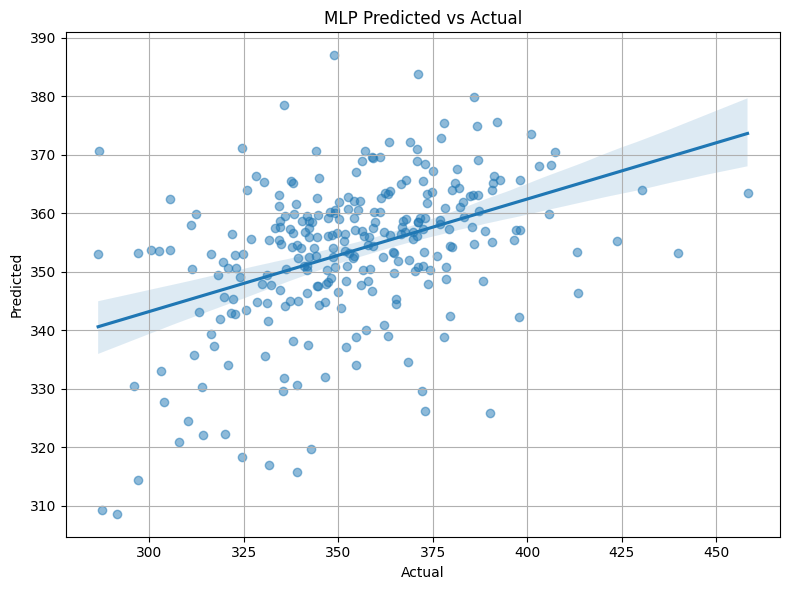

In [56]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

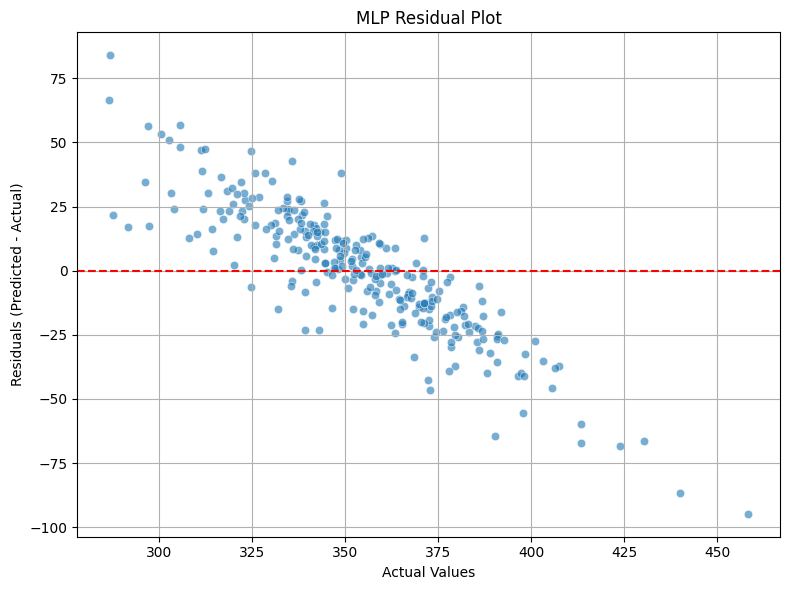

In [57]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only Location

In [59]:
pca_loc= X_dupe.drop(['BBD', 'LL', 'LW', 'PLH'], axis=1)
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,196,197,198,199,200,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,-0.029684,-0.021613,-0.062550,-0.013679,-0.004255,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,-0.014262,0.020761,-0.018963,-0.029273,-0.007213,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.096439,-0.033712,-0.023681,0.017747,0.021563,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,0.012487,0.008690,0.030832,0.041246,-0.031854,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,0.023067,-0.009843,0.023802,-0.018460,0.009567,0,1,0,1,0


In [60]:
pca_loc_dupe = X_dupe.drop(['BBD', 'LL', 'LW', 'PLH'], axis=1)
pca_loc_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,196,197,198,199,200,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,-0.029684,-0.021613,-0.062550,-0.013679,-0.004255,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,-0.014262,0.020761,-0.018963,-0.029273,-0.007213,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.096439,-0.033712,-0.023681,0.017747,0.021563,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,0.012487,0.008690,0.030832,0.041246,-0.031854,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,0.023067,-0.009843,0.023802,-0.018460,0.009567,0,1,0,1,0


In [61]:
X_tensor = torch.tensor(pca_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [62]:
print(X_tensor.shape)

torch.Size([1094, 205])


In [63]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [64]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 10:30:53,473] A new study created in memory with name: no-name-4e20d226-5217-49fa-9120-b92981c46369
[I 2025-05-27 10:30:55,336] Trial 0 finished with value: 486.23681640625 and parameters: {'hidden_size1': 100, 'dropout1': 0.02020128720346851, 'lr': 0.0004789139611641573, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.009312158504709855, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 486.23681640625.


Early stopping at epoch 90


[I 2025-05-27 10:30:58,112] Trial 1 finished with value: 127060.2890625 and parameters: {'hidden_size1': 100, 'dropout1': 0.07854982433858336, 'lr': 0.00014227385306046794, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 1.814833988229108e-05, 'n_layers': 1}. Best is trial 0 with value: 486.23681640625.
[I 2025-05-27 10:30:59,686] Trial 2 finished with value: 466.9988708496094 and parameters: {'hidden_size1': 100, 'dropout1': 0.028238211584612392, 'lr': 0.00037734204966772346, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.0012249764568175714, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 2 with value: 466.9988708496094.


Early stopping at epoch 47


[I 2025-05-27 10:31:01,550] Trial 3 finished with value: 119931.5234375 and parameters: {'hidden_size1': 200, 'dropout1': 0.09802281097215636, 'lr': 0.0020262133918408816, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.00953539425541795, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 2 with value: 466.9988708496094.
[I 2025-05-27 10:31:01,886] Trial 4 finished with value: 568.5654296875 and parameters: {'hidden_size1': 200, 'dropout1': 0.024879836498646266, 'lr': 0.0037339299589717687, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.00019641258541003328, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 2 with value: 466.9988708496094.


...

Early stopping at epoch 42


[I 2025-05-27 10:31:50,498] Trial 47 finished with value: 532.882080078125 and parameters: {'hidden_size1': 100, 'dropout1': 0.06005559187203456, 'lr': 0.0018739571679726732, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 3.144801825078462e-05, 'n_layers': 1}. Best is trial 11 with value: 459.5216369628906.
[I 2025-05-27 10:31:51,491] Trial 48 finished with value: 552.2158203125 and parameters: {'hidden_size1': 300, 'dropout1': 0.06832054855493505, 'lr': 0.0009306467193625056, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.0023170783046091593, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.0508638471823135}. Best is trial 11 with value: 459.5216369628906.


Early stopping at epoch 25


[I 2025-05-27 10:31:52,561] Trial 49 finished with value: 112653.578125 and parameters: {'hidden_size1': 300, 'dropout1': 0.03341292181936721, 'lr': 0.00017717272325962324, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.0065555246358353254, 'n_layers': 1}. Best is trial 11 with value: 459.5216369628906.


Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.047475256513694115, 'lr': 0.0011918652229218844, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.001742492132199267, 'n_layers': 1}


In [65]:
best_params = complete_params(study.best_params)

In [67]:
#def cross_validate(X, y, best_params, n_splits, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_200_best_model_onlyloc_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 84 for fold 1
Fold 1 validation loss: 462.5558
Training fold 2
Early stopping at epoch 84 for fold 2
Fold 2 validation loss: 475.9943
Training fold 3
Fold 3 validation loss: 457.3751
Training fold 4
Early stopping at epoch 95 for fold 4
Fold 4 validation loss: 497.6928
Training fold 5
Early stopping at epoch 67 for fold 5
Fold 5 validation loss: 474.1633
Training fold 6
Early stopping at epoch 85 for fold 6
Fold 6 validation loss: 525.6672
Training fold 7
Early stopping at epoch 96 for fold 7
Fold 7 validation loss: 542.2847
Training fold 8
Early stopping at epoch 94 for fold 8
Fold 8 validation loss: 478.2784
Training fold 9
Early stopping at epoch 71 for fold 9
Fold 9 validation loss: 612.1852
Training fold 10
Early stopping at epoch 72 for fold 10
Fold 10 validation loss: 484.9275

Average validation loss across all folds: 501.1124
Checkpoint saved as 'pca_200_best_model_onlyloc_mlp_prt.pth'.


In [75]:
X_holdout = pca_full_holdout.iloc[:, :509]
X_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,0.025688,61,6.83333,9.73333,109.567,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,0.039107,78,3.74000,9.98000,59.000,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.020326,30,6.86667,9.42667,77.000,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.017548,42,8.03333,10.66000,100.000,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.035709,47,8.00000,10.36670,59.400,1,0,0,1,0


In [76]:
y_holdout = pca_full_holdout.iloc[:, 509:]
y_holdout.head()

,PRT
Line,
s349,405.602
s723,307.984
s486,339.283
s426,370.721
s1576,337.116


In [77]:
# Ensure both training and holdout datasets have the same columns
pca_loc_dupe, X_holdout = pca_loc_dupe.align(X_holdout, join='inner', axis=1)

In [78]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s349 to s401
Columns: 205 entries, 1 to landrace
dtypes: float64(200), int64(5)
memory usage: 441.0+ KB


In [79]:
X_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,196,197,198,199,200,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,-0.013503,-0.030513,0.016369,-0.084505,-0.087644,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,-0.084770,0.027059,0.009162,-0.038436,0.040243,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.008475,0.013980,0.028233,-0.021271,0.035880,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.005758,0.004417,0.039982,0.038942,0.003705,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.041198,0.004964,-0.008812,-0.044021,-0.003862,1,0,0,1,0


In [80]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [81]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 628.1490
RMSE: 25.0629
MAE: 19.1084
R2: 0.1646
Holdout_Loss: 628.1490


In [82]:
pickle.dump(best_mlp_model, open("pca_200_best_model_onlyloc_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 405.602 359.44232
1 307.984 343.18442
2 339.283 357.73215
3 370.721 372.91092
4 337.116 341.00806
5 358.958 352.85654


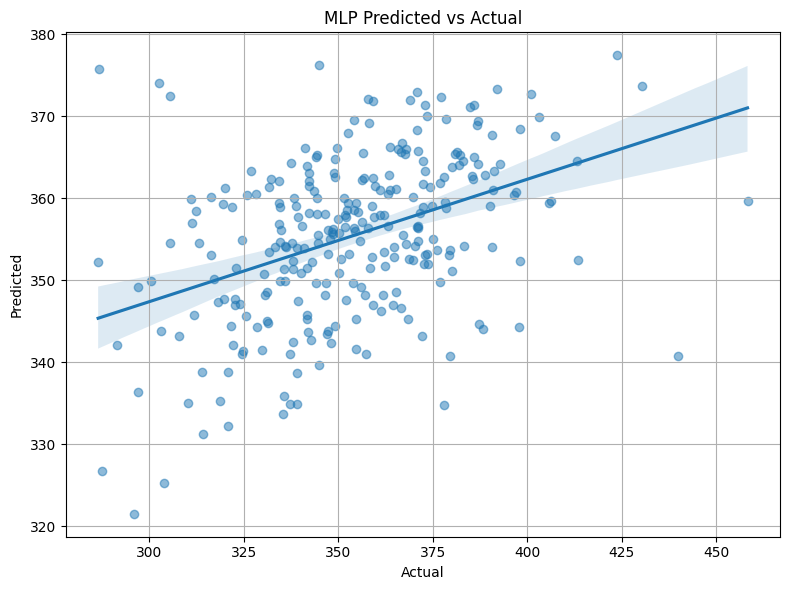

In [83]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

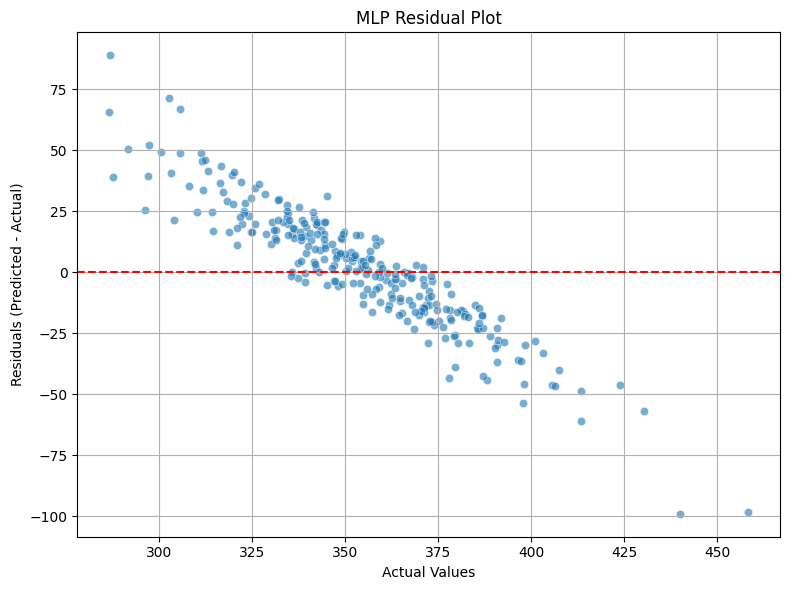

In [84]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only PCs

In [85]:
only_pca= pd.concat([pca_full_train.iloc[:, :200], pca_full_train.iloc[:, -3:]], axis=1)
only_pca= only_pca.drop(['PRT'], axis=1)
only_pca.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,0.014839,0.013609,0.008501,-0.029684,-0.021613,-0.062550,-0.013679,-0.004255,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,0.014234,-0.019987,-0.006039,-0.014262,0.020761,-0.018963,-0.029273,-0.007213,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.015354,0.037879,0.085191,0.096439,-0.033712,-0.023681,0.017747,0.021563,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,0.012463,0.065665,0.073180,0.012487,0.008690,0.030832,0.041246,-0.031854,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.016131,0.034417,-0.018315,0.023067,-0.009843,0.023802,-0.018460,0.009567,1,0


In [86]:
only_pca_dupe = pd.concat([pca_full_train.iloc[:, :200], pca_full_train.iloc[:, -3:]], axis=1)
only_pca_dupe = only_pca_dupe .drop(['PRT'], axis=1)
only_pca_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,0.014839,0.013609,0.008501,-0.029684,-0.021613,-0.062550,-0.013679,-0.004255,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,0.014234,-0.019987,-0.006039,-0.014262,0.020761,-0.018963,-0.029273,-0.007213,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.015354,0.037879,0.085191,0.096439,-0.033712,-0.023681,0.017747,0.021563,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,0.012463,0.065665,0.073180,0.012487,0.008690,0.030832,0.041246,-0.031854,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.016131,0.034417,-0.018315,0.023067,-0.009843,0.023802,-0.018460,0.009567,1,0


In [87]:
# Convert to tensor and move to GPU if available
X_tensor = torch.tensor(only_pca.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [88]:
print(X_tensor.shape)

torch.Size([1094, 202])


In [89]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [90]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 10:41:18,188] A new study created in memory with name: no-name-44e623d4-d608-4e2c-9240-7de78c387d01
[I 2025-05-27 10:41:18,994] Trial 0 finished with value: 483.4348449707031 and parameters: {'hidden_size1': 300, 'dropout1': 0.09588343171818475, 'lr': 0.0002905846348348614, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.003491343127333811, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.02410415073561948}. Best is trial 0 with value: 483.4348449707031.


Early stopping at epoch 36


[I 2025-05-27 10:41:20,006] Trial 1 finished with value: 124614.0390625 and parameters: {'hidden_size1': 100, 'dropout1': 0.06527253830668399, 'lr': 0.002789081599550373, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.00024889183475921086, 'n_layers': 1}. Best is trial 0 with value: 483.4348449707031.
[I 2025-05-27 10:41:20,642] Trial 2 finished with value: 635.2343139648438 and parameters: {'hidden_size1': 100, 'dropout1': 0.05516843598200062, 'lr': 0.003964979268393251, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.001386132542124999, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout2': 0.0527355966485065}. Best is trial 0 with value: 483.4348449707031.


Early stopping at epoch 27


[I 2025-05-27 10:41:21,775] Trial 3 finished with value: 529.1931762695312 and parameters: {'hidden_size1': 200, 'dropout1': 0.05462661816496105, 'lr': 0.00027923888938942795, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.000978597538362049, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout2': 0.010794773625704473}. Best is trial 0 with value: 483.4348449707031.


...

Early stopping at epoch 29


[I 2025-05-27 10:42:09,753] Trial 48 finished with value: 484.25372314453125 and parameters: {'hidden_size1': 300, 'dropout1': 0.03815517094454772, 'lr': 0.002676811265076763, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.004450720062999031, 'n_layers': 1}. Best is trial 17 with value: 466.355712890625.


Early stopping at epoch 48


[I 2025-05-27 10:42:12,222] Trial 49 finished with value: 479.8807067871094 and parameters: {'hidden_size1': 200, 'dropout1': 0.0933399742952466, 'lr': 0.0008385664272929272, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.0021959029547250018, 'n_layers': 1}. Best is trial 17 with value: 466.355712890625.


Early stopping at epoch 85
Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.09752476535235491, 'lr': 0.0014067613373765153, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.004930533857590609, 'n_layers': 1}


In [92]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, best_params, n_splits, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='"pca_200_best_model_onlypcs_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 82 for fold 1
Fold 1 validation loss: 467.9644
Training fold 2
Early stopping at epoch 77 for fold 2
Fold 2 validation loss: 455.5361
Training fold 3
Fold 3 validation loss: 492.5044
Training fold 4
Early stopping at epoch 86 for fold 4
Fold 4 validation loss: 499.1256
Training fold 5
Early stopping at epoch 77 for fold 5
Fold 5 validation loss: 472.1510
Training fold 6
Early stopping at epoch 81 for fold 6
Fold 6 validation loss: 523.4172
Training fold 7
Fold 7 validation loss: 559.4587
Training fold 8
Fold 8 validation loss: 474.7348
Training fold 9
Early stopping at epoch 76 for fold 9
Fold 9 validation loss: 625.6486
Training fold 10
Early stopping at epoch 78 for fold 10
Fold 10 validation loss: 497.8460

Average validation loss across all folds: 506.8387
Checkpoint saved as '"pca_200_best_model_onlypcs_mlp_prt.pth'.


In [93]:
best_mlp_model

Sequential(
  (0): Linear(in_features=202, out_features=300, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.09752476535235491, inplace=False)
  (3): Linear(in_features=300, out_features=1, bias=True)
)

In [94]:
pca_full_holdout = pd.read_pickle("pickle_files/pca_full_holdout_prt.pkl")
pca_full_holdout = pca_full_holdout.reset_index().set_index('Line')
pca_full_holdout = pca_full_holdout.drop(['index','new_line'], axis=1)
pca_full_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,61,6.83333,9.73333,109.567,1,0,0,1,0,405.602
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,78,3.74000,9.98000,59.000,0,0,1,1,0,307.984
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,30,6.86667,9.42667,77.000,0,1,0,1,0,339.283
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,42,8.03333,10.66000,100.000,0,1,0,1,0,370.721
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,47,8.00000,10.36670,59.400,1,0,0,1,0,337.116


In [95]:
X_holdout = pca_full_holdout.iloc[:, :509]
X_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,0.025688,61,6.83333,9.73333,109.567,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,0.039107,78,3.74000,9.98000,59.000,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.020326,30,6.86667,9.42667,77.000,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.017548,42,8.03333,10.66000,100.000,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.035709,47,8.00000,10.36670,59.400,1,0,0,1,0


In [96]:
y_holdout = pca_full_holdout.iloc[:, 509:]
y_holdout.head()

,PRT
Line,
s349,405.602
s723,307.984
s486,339.283
s426,370.721
s1576,337.116


In [97]:
# Ensure both training and holdout datasets have the same columns
only_pca_dupe, X_holdout =only_pca_dupe.align(X_holdout, join='inner', axis=1)

In [98]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s349 to s401
Columns: 202 entries, 1 to landrace
dtypes: float64(200), int64(2)
memory usage: 434.5+ KB


In [99]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [100]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 650.5845
RMSE: 25.5066
MAE: 19.7804
R2: 0.1347
Holdout_Loss: 650.5844


In [101]:
pickle.dump(best_mlp_model, open("pca_200_best_model_onlypcs_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

## PC500 

### All covariates

In [140]:
y_all = pca_full_train.iloc[:, 509:]
y_all.head()

,PRT
Line,
s233,328.773
s582,354.750
s472,332.734
s531,327.574
s848,376.204


In [141]:
X_all = pca_full_train.iloc[:, 0:509]
X_all.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,0.013360,33,6.88000,9.02667,41.0000,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,0.022377,61,7.20000,9.20000,62.5667,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,-0.039258,81,6.86667,9.60000,100.8670,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.024071,77,8.00000,9.13333,98.3333,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.011595,38,4.82000,9.82000,42.0000,0,1,0,1,0


In [142]:
X_all_dupe = pca_full_train.iloc[:, 0:509]
X_all_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,0.013360,33,6.88000,9.02667,41.0000,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,0.022377,61,7.20000,9.20000,62.5667,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,-0.039258,81,6.86667,9.60000,100.8670,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.024071,77,8.00000,9.13333,98.3333,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.011595,38,4.82000,9.82000,42.0000,0,1,0,1,0


In [143]:
X_tensor = torch.tensor(X_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [144]:
print(X_tensor.shape)

torch.Size([1094, 509])


In [145]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [146]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 11:08:40,435] A new study created in memory with name: no-name-48bc23d9-10ba-492d-9561-b8519b0499c5
[I 2025-05-27 11:08:41,571] Trial 0 finished with value: 108365.046875 and parameters: {'hidden_size1': 200, 'dropout1': 0.039046347722198414, 'lr': 0.0009763787292222855, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 7.264307760548468e-05, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 108365.046875.
[I 2025-05-27 11:08:43,716] Trial 1 finished with value: 9227.8564453125 and parameters: {'hidden_size1': 300, 'dropout1': 0.09632894795470699, 'lr': 0.001422294067998561, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.001182099467468194, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout2': 0.06288857571589392}. Best is trial 1 with value: 9227.8564453125.
[I 2025-05-27 11:08:45,490] Trial 2 finished with value: 1252.5181884765625 and parameters: {'hidden_size1': 200, 'dropout1': 0.012966685336805863, 'lr': 0.0018723921343956884

Early stopping at epoch 91


[I 2025-05-27 11:08:47,629] Trial 3 finished with value: 91391.421875 and parameters: {'hidden_size1': 200, 'dropout1': 0.09189624092539236, 'lr': 0.0007177160841684384, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.004627065013645456, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout2': 0.0567115358337448}. Best is trial 2 with value: 1252.5181884765625.
[I 2025-05-27 11:08:49,942] Trial 4 finished with value: 1524.5582275390625 and parameters: {'hidden_size1': 100, 'dropout1': 0.038134827131675875, 'lr': 0.0011440290684230812, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 5.998406168593821e-05, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout2': 0.07349726600526765}. Best is trial 2 with value: 1252.5181884765625.


Early stopping at epoch 59


[I 2025-05-27 11:08:52,736] Trial 5 finished with value: 8033.44873046875 and parameters: {'hidden_size1': 300, 'dropout1': 0.014520085160835638, 'lr': 0.0012293472469482201, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0014134900792877004, 'n_layers': 1}. Best is trial 2 with value: 1252.5181884765625.
[I 2025-05-27 11:08:55,080] Trial 6 finished with value: 780.7447509765625 and parameters: {'hidden_size1': 300, 'dropout1': 0.07050212870063247, 'lr': 0.0009913510431970442, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.00019922938351743717, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout2': 0.08906740939765173}. Best is trial 6 with value: 780.7447509765625.
[I 2025-05-27 11:08:57,245] Trial 7 finished with value: 124880.7265625 and parameters: {'hidden_size1': 300, 'dropout1': 0.08800838690954481, 'lr': 0.0003024947039075589, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.008648423848746428, 'n_layers': 3, 'hidden_size2': 100, 'hidden_si

...

Early stopping at epoch 82


[I 2025-05-27 11:10:23,739] Trial 47 finished with value: 7169.62548828125 and parameters: {'hidden_size1': 200, 'dropout1': 0.0265445760378678, 'lr': 0.003718633281018666, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 1.4290610203181414e-05, 'n_layers': 1}. Best is trial 23 with value: 506.9187927246094.
[I 2025-05-27 11:10:25,917] Trial 48 finished with value: 755.1519775390625 and parameters: {'hidden_size1': 200, 'dropout1': 0.03951000611807516, 'lr': 0.0027500814004163647, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 2.475930094290555e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 23 with value: 506.9187927246094.


Early stopping at epoch 58


[I 2025-05-27 11:10:28,498] Trial 49 finished with value: 474.54443359375 and parameters: {'hidden_size1': 200, 'dropout1': 0.026992055860015237, 'lr': 0.0047652848966854245, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1.955583237694557e-05, 'n_layers': 1}. Best is trial 49 with value: 474.54443359375.


Early stopping at epoch 82
Best hyperparameters: {'hidden_size1': 200, 'dropout1': 0.026992055860015237, 'lr': 0.0047652848966854245, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1.955583237694557e-05, 'n_layers': 1}


In [147]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_500_best_model_allfeats_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 73 for fold 1
Fold 1 validation loss: 484.8030
Training fold 2
Early stopping at epoch 62 for fold 2
Fold 2 validation loss: 529.5066
Training fold 3
Early stopping at epoch 60 for fold 3
Fold 3 validation loss: 500.0372
Training fold 4
Early stopping at epoch 90 for fold 4
Fold 4 validation loss: 458.9344
Training fold 5
Early stopping at epoch 62 for fold 5
Fold 5 validation loss: 495.4098
Training fold 6
Early stopping at epoch 71 for fold 6
Fold 6 validation loss: 530.7058
Training fold 7
Early stopping at epoch 71 for fold 7
Fold 7 validation loss: 554.1425
Training fold 8
Early stopping at epoch 65 for fold 8
Fold 8 validation loss: 517.7737
Training fold 9
Early stopping at epoch 82 for fold 9
Fold 9 validation loss: 596.5297
Training fold 10
Early stopping at epoch 61 for fold 10
Fold 10 validation loss: 550.9426

Average validation loss across all folds: 521.8785
Checkpoint saved as 'pca_500_best_model_allfeats_mlp_prt.pth'.


In [148]:
best_mlp_model

Sequential(
  (0): Linear(in_features=509, out_features=200, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.026992055860015237, inplace=False)
  (3): Linear(in_features=200, out_features=1, bias=True)
)

In [149]:
X_holdout = pca_full_holdout.iloc[:, 0:509]
X_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,0.025688,61,6.83333,9.73333,109.567,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,0.039107,78,3.74000,9.98000,59.000,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.020326,30,6.86667,9.42667,77.000,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.017548,42,8.03333,10.66000,100.000,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.035709,47,8.00000,10.36670,59.400,1,0,0,1,0


In [150]:
y_holdout = pca_full_holdout.iloc[:, 509:]
y_holdout.head()

,PRT
Line,
s349,405.602
s723,307.984
s486,339.283
s426,370.721
s1576,337.116


In [151]:
# Ensure both training and holdout datasets have the same columns
X_all_dupe, X_holdout = X_all_dupe.align(X_holdout, join='inner', axis=1)

In [152]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s349 to s401
Columns: 509 entries, 1 to landrace
dtypes: float64(503), int64(6)
memory usage: 1.1+ MB


In [153]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [154]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 665.7874
RMSE: 25.8029
MAE: 19.5612
R2: 0.1145
Holdout_Loss: 665.7874


In [155]:
pickle.dump(best_mlp_model, open("pca_500_best_model_allfeats_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 405.602 349.9851
1 307.984 339.72073
2 339.283 345.29086
3 370.721 360.96378
4 337.116 333.32874
5 358.958 325.01654


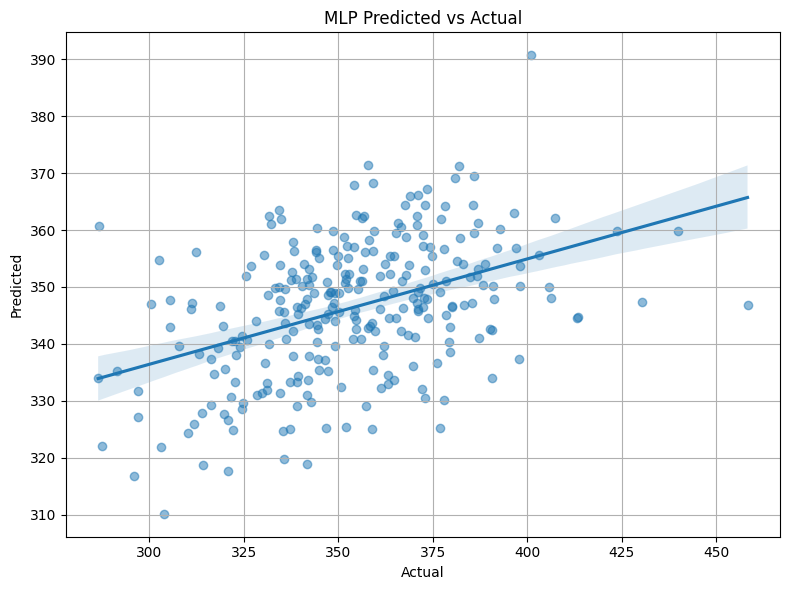

In [156]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

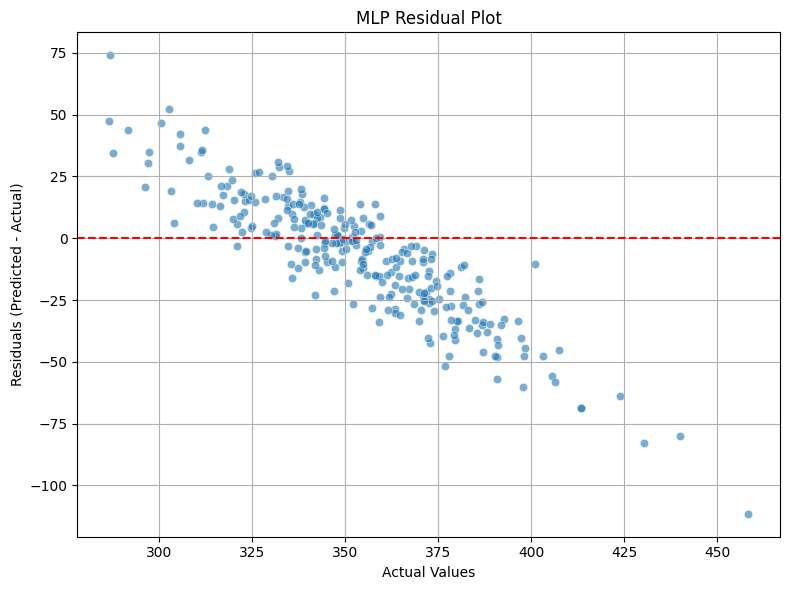

In [157]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [121]:
pca_loc= X_all_dupe.drop(['BBD', 'LL', 'LW', 'PLH'], axis=1)
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,496,497,498,499,500,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,-0.002424,-0.021051,-0.034366,-0.068256,0.013360,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,-0.032258,-0.006708,0.009431,-0.011996,0.022377,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,-0.023095,0.032951,0.037934,-0.014143,-0.039258,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.001107,0.003202,-0.018890,-0.008451,-0.024071,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.005132,-0.008824,-0.025641,-0.025157,-0.011595,0,1,0,1,0


In [122]:
pca_loc_dupe = X_all_dupe.drop(['BBD', 'LL', 'LW', 'PLH'], axis=1)
pca_loc_dupe .head()

,1,2,3,4,5,6,7,8,9,10,...,496,497,498,499,500,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,-0.002424,-0.021051,-0.034366,-0.068256,0.013360,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,-0.032258,-0.006708,0.009431,-0.011996,0.022377,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,-0.023095,0.032951,0.037934,-0.014143,-0.039258,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.001107,0.003202,-0.018890,-0.008451,-0.024071,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.005132,-0.008824,-0.025641,-0.025157,-0.011595,0,1,0,1,0


In [124]:
y = pca_full_train.iloc[:, 509:]
y.head()

,PRT
Line,
s233,328.773
s582,354.750
s472,332.734
s531,327.574
s848,376.204


In [125]:
X_tensor = torch.tensor(pca_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [126]:
print(X_tensor.shape)

torch.Size([1094, 505])


In [127]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [128]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 11:00:57,937] A new study created in memory with name: no-name-60a0976b-4851-421c-b9df-a3dcfa9ec9ad
[I 2025-05-27 11:00:59,965] Trial 0 finished with value: 507.16119384765625 and parameters: {'hidden_size1': 300, 'dropout1': 0.019124748592905826, 'lr': 0.00016862208078193805, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0010749202588438908, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 507.16119384765625.


Early stopping at epoch 56


[I 2025-05-27 11:01:00,404] Trial 1 finished with value: 637.1618041992188 and parameters: {'hidden_size1': 200, 'dropout1': 0.07754537808702058, 'lr': 0.0013844740540161608, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.00044034339887098436, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 0 with value: 507.16119384765625.


Early stopping at epoch 22


[I 2025-05-27 11:01:01,062] Trial 2 finished with value: 733.4552612304688 and parameters: {'hidden_size1': 200, 'dropout1': 0.043529751387952315, 'lr': 0.00103069041974108, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 2.59338233018085e-05, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 507.16119384765625.


...

Early stopping at epoch 81


[I 2025-05-27 11:02:23,249] Trial 48 finished with value: 591.2157592773438 and parameters: {'hidden_size1': 100, 'dropout1': 0.06283606094876057, 'lr': 0.0015726150550658317, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.003396975269050484, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 30 with value: 459.2083740234375.


Early stopping at epoch 20


[I 2025-05-27 11:02:26,207] Trial 49 finished with value: 67697.8046875 and parameters: {'hidden_size1': 300, 'dropout1': 0.054249278730748064, 'lr': 0.00011488651443098774, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.009775752240904876, 'n_layers': 1}. Best is trial 30 with value: 459.2083740234375.


Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.07626699487566933, 'lr': 0.001212017381692477, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0036541265316397723, 'n_layers': 1}


In [129]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_500_best_model_onlyloc_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 35 for fold 1
Fold 1 validation loss: 475.9675
Training fold 2
Early stopping at epoch 41 for fold 2
Fold 2 validation loss: 470.2872
Training fold 3
Early stopping at epoch 43 for fold 3
Fold 3 validation loss: 503.0469
Training fold 4
Early stopping at epoch 85 for fold 4
Fold 4 validation loss: 494.3856
Training fold 5
Early stopping at epoch 53 for fold 5
Fold 5 validation loss: 453.7119
Training fold 6
Early stopping at epoch 57 for fold 6
Fold 6 validation loss: 512.5018
Training fold 7
Early stopping at epoch 45 for fold 7
Fold 7 validation loss: 509.1935
Training fold 8
Early stopping at epoch 44 for fold 8
Fold 8 validation loss: 498.6134
Training fold 9
Early stopping at epoch 36 for fold 9
Fold 9 validation loss: 615.5385
Training fold 10
Early stopping at epoch 33 for fold 10
Fold 10 validation loss: 467.9992

Average validation loss across all folds: 500.1245
Checkpoint saved as 'pca_500_best_model_onlyloc_mlp_prt.pth'.


In [130]:
pca_full_holdout = pd.read_pickle("pickle_files/pca_full_holdout_prt.pkl")
pca_full_holdout = pca_full_holdout.reset_index().set_index('Line')
pca_full_holdout = pca_full_holdout.drop(['index','new_line'], axis=1)
pca_full_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,61,6.83333,9.73333,109.567,1,0,0,1,0,405.602
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,78,3.74000,9.98000,59.000,0,0,1,1,0,307.984
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,30,6.86667,9.42667,77.000,0,1,0,1,0,339.283
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,42,8.03333,10.66000,100.000,0,1,0,1,0,370.721
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,47,8.00000,10.36670,59.400,1,0,0,1,0,337.116


In [131]:
X_holdout = pca_full_holdout.iloc[:, :509]
X_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,0.025688,61,6.83333,9.73333,109.567,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,0.039107,78,3.74000,9.98000,59.000,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.020326,30,6.86667,9.42667,77.000,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.017548,42,8.03333,10.66000,100.000,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.035709,47,8.00000,10.36670,59.400,1,0,0,1,0


In [132]:
y_holdout = pca_full_holdout.iloc[:, 509:]
y_holdout.head()

,PRT
Line,
s349,405.602
s723,307.984
s486,339.283
s426,370.721
s1576,337.116


In [133]:
# Ensure both training and holdout datasets have the same columns
pca_loc_dupe, X_holdout = pca_loc_dupe.align(X_holdout, join='inner', axis=1)

In [134]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s349 to s401
Columns: 505 entries, 1 to landrace
dtypes: float64(500), int64(5)
memory usage: 1.1+ MB


In [135]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [136]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 620.6910
RMSE: 24.9137
MAE: 19.4256
R2: 0.1745
Holdout_Loss: 620.6910


In [137]:
pickle.dump(best_mlp_model, open("'pca_500_best_model_onlyloc_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 405.602 356.08807
1 307.984 338.40213
2 339.283 364.89166
3 370.721 362.6646
4 337.116 346.41638
5 358.958 343.6494


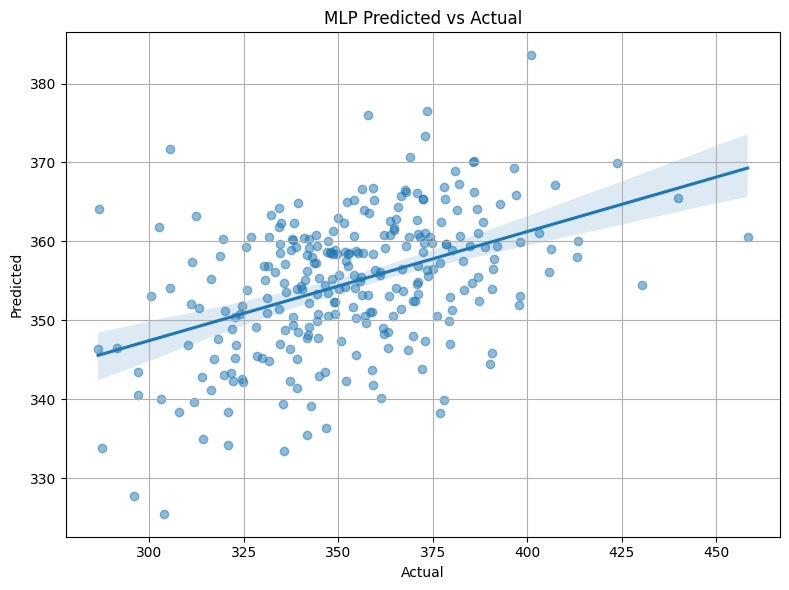

In [138]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

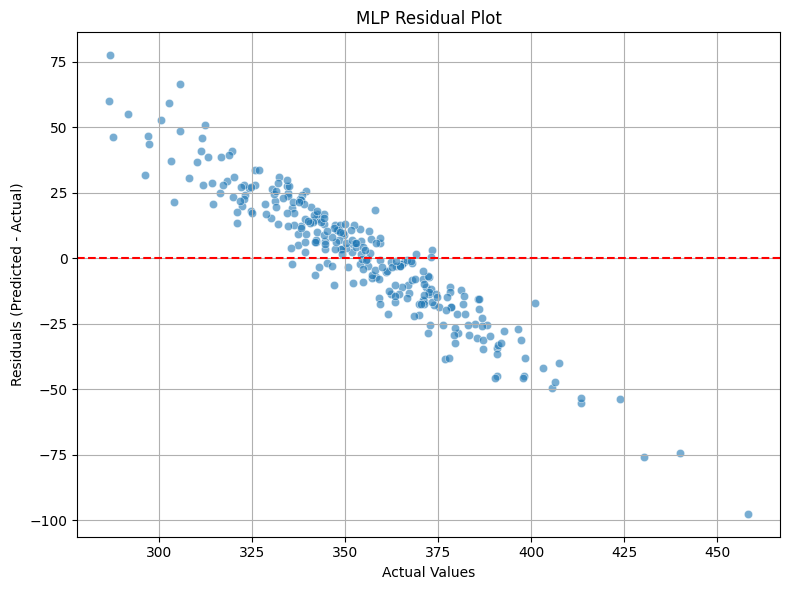

In [139]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [158]:
y = pca_full_train.iloc[:, 509:]
y.head()

,PRT
Line,
s233,328.773
s582,354.750
s472,332.734
s531,327.574
s848,376.204


In [159]:
pca_only =  pca_full_train.iloc[:, :500]
pca_only.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,0.081175,-0.008593,-0.021243,-0.019327,0.034828,-0.002424,-0.021051,-0.034366,-0.068256,0.013360
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,0.009136,-0.012727,-0.008576,0.011897,0.014173,-0.032258,-0.006708,0.009431,-0.011996,0.022377
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.046973,-0.011274,0.001273,-0.005819,0.034749,-0.023095,0.032951,0.037934,-0.014143,-0.039258
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.028776,0.025225,0.005238,-0.069780,-0.047269,-0.001107,0.003202,-0.018890,-0.008451,-0.024071
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.015445,0.019998,0.012256,0.001475,0.020746,-0.005132,-0.008824,-0.025641,-0.025157,-0.011595


In [160]:
pca_only_dupe =  pca_full_train.iloc[:, :500]
pca_only_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,0.081175,-0.008593,-0.021243,-0.019327,0.034828,-0.002424,-0.021051,-0.034366,-0.068256,0.013360
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,0.009136,-0.012727,-0.008576,0.011897,0.014173,-0.032258,-0.006708,0.009431,-0.011996,0.022377
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.046973,-0.011274,0.001273,-0.005819,0.034749,-0.023095,0.032951,0.037934,-0.014143,-0.039258
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.028776,0.025225,0.005238,-0.069780,-0.047269,-0.001107,0.003202,-0.018890,-0.008451,-0.024071
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.015445,0.019998,0.012256,0.001475,0.020746,-0.005132,-0.008824,-0.025641,-0.025157,-0.011595


In [161]:
X_tensor = torch.tensor(pca_only.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [162]:
print(X_tensor.shape)

torch.Size([1094, 500])


In [163]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [164]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 11:12:18,509] A new study created in memory with name: no-name-1a107639-5f80-4fc5-a308-50e9bf0b0d51
[I 2025-05-27 11:12:20,571] Trial 0 finished with value: 862.1325073242188 and parameters: {'hidden_size1': 100, 'dropout1': 0.08707742628413566, 'lr': 0.0004953278930235593, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 7.896423456502917e-05, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 862.1325073242188.


Early stopping at epoch 57


[I 2025-05-27 11:12:21,881] Trial 1 finished with value: 977.8662719726562 and parameters: {'hidden_size1': 100, 'dropout1': 0.08586037172776752, 'lr': 0.0006020620196795963, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 2.386313370505837e-05, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout2': 0.036219016981911045}. Best is trial 0 with value: 862.1325073242188.


Early stopping at epoch 55


[I 2025-05-27 11:12:22,986] Trial 2 finished with value: 125549.84375 and parameters: {'hidden_size1': 300, 'dropout1': 0.03785480150838651, 'lr': 0.00010130573620916817, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.006755641734226252, 'n_layers': 1}. Best is trial 0 with value: 862.1325073242188.
[I 2025-05-27 11:12:25,150] Trial 3 finished with value: 125234.9765625 and parameters: {'hidden_size1': 200, 'dropout1': 0.07827007047057292, 'lr': 0.0014508150009300974, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0012560829702786885, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout2': 0.06330044339580965}. Best is trial 0 with value: 862.1325073242188.
[I 2025-05-27 11:12:25,776] Trial 4 finished with value: 600.385986328125 and parameters: {'hidden_size1': 200, 'dropout1': 0.032462490128691214, 'lr': 0.0012201992356988397, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.006049717080407115, 'n_layers': 2, 'hidden_size2': 100}. Best is tria

...

Early stopping at epoch 81


[I 2025-05-27 11:13:55,879] Trial 45 finished with value: 561.729248046875 and parameters: {'hidden_size1': 100, 'dropout1': 0.08521006356738793, 'lr': 0.0002816269211360316, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.005846137036910996, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 32 with value: 490.6383972167969.
[I 2025-05-27 11:13:56,492] Trial 46 finished with value: 1065.711181640625 and parameters: {'hidden_size1': 100, 'dropout1': 0.05674673008806164, 'lr': 0.005343477638743798, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.00011009965286210108, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 32 with value: 490.6383972167969.


Early stopping at epoch 29


[I 2025-05-27 11:13:59,775] Trial 47 finished with value: 126990.2421875 and parameters: {'hidden_size1': 200, 'dropout1': 0.06701810656661798, 'lr': 0.0001557076923310188, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.001064634771751605, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 32 with value: 490.6383972167969.
[I 2025-05-27 11:14:00,928] Trial 48 finished with value: 124330.4609375 and parameters: {'hidden_size1': 100, 'dropout1': 0.08060230414173063, 'lr': 0.003375602879800943, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.000486485778513556, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 32 with value: 490.6383972167969.
[I 2025-05-27 11:14:02,937] Trial 49 finished with value: 477.6193542480469 and parameters: {'hidden_size1': 200, 'dropout1': 0.09388808389015404, 'lr': 0.0014906257951000127, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.00928245295725168, 'n_layers': 1}. Best is trial 49 with value: 477.6193542480469.


Early stopping at epoch 64
Best hyperparameters: {'hidden_size1': 200, 'dropout1': 0.09388808389015404, 'lr': 0.0014906257951000127, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.00928245295725168, 'n_layers': 1}


In [165]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_500_best_model_onlypcs_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 44 for fold 1
Fold 1 validation loss: 472.6624
Training fold 2
Early stopping at epoch 52 for fold 2
Fold 2 validation loss: 458.8681
Training fold 3
Early stopping at epoch 56 for fold 3
Fold 3 validation loss: 532.7185
Training fold 4
Early stopping at epoch 62 for fold 4
Fold 4 validation loss: 505.0806
Training fold 5
Early stopping at epoch 48 for fold 5
Fold 5 validation loss: 420.7494
Training fold 6
Early stopping at epoch 46 for fold 6
Fold 6 validation loss: 523.0513
Training fold 7
Early stopping at epoch 54 for fold 7
Fold 7 validation loss: 538.7891
Training fold 8
Early stopping at epoch 56 for fold 8
Fold 8 validation loss: 490.6716
Training fold 9
Early stopping at epoch 44 for fold 9
Fold 9 validation loss: 632.3589
Training fold 10
Early stopping at epoch 58 for fold 10
Fold 10 validation loss: 501.0904

Average validation loss across all folds: 507.6040
Checkpoint saved as 'pca_500_best_model_onlypcs_mlp_prt.pth'.


In [166]:
pca_full_holdout = pd.read_pickle("pickle_files/pca_full_holdout_prt.pkl")
pca_full_holdout = pca_full_holdout.reset_index().set_index('Line')
pca_full_holdout = pca_full_holdout.drop(['index','new_line'], axis=1)
pca_full_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,61,6.83333,9.73333,109.567,1,0,0,1,0,405.602
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,78,3.74000,9.98000,59.000,0,0,1,1,0,307.984
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,30,6.86667,9.42667,77.000,0,1,0,1,0,339.283
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,42,8.03333,10.66000,100.000,0,1,0,1,0,370.721
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,47,8.00000,10.36670,59.400,1,0,0,1,0,337.116


In [167]:
X_holdout = pca_full_holdout.iloc[:, :509]
X_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,0.025688,61,6.83333,9.73333,109.567,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,0.039107,78,3.74000,9.98000,59.000,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.020326,30,6.86667,9.42667,77.000,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.017548,42,8.03333,10.66000,100.000,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.035709,47,8.00000,10.36670,59.400,1,0,0,1,0


In [168]:
y_holdout = pca_full_holdout.iloc[:, 509:]
y_holdout.head()

,PRT
Line,
s349,405.602
s723,307.984
s486,339.283
s426,370.721
s1576,337.116


In [169]:
# Ensure both training and holdout datasets have the same columns
pca_only_dupe, X_holdout = pca_only_dupe.align(X_holdout, join='inner', axis=1)

In [170]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s349 to s401
Columns: 500 entries, 1 to 500
dtypes: float64(500)
memory usage: 1.0+ MB


In [171]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [172]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 668.5610
RMSE: 25.8565
MAE: 20.0684
R2: 0.1108
Holdout_Loss: 668.5611


In [173]:
pickle.dump(best_mlp_model, open("'pca_500_best_model_onlypcs_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 405.602 353.2651
1 307.984 351.26822
2 339.283 360.735
3 370.721 357.16302
4 337.116 340.89606
5 358.958 347.96494


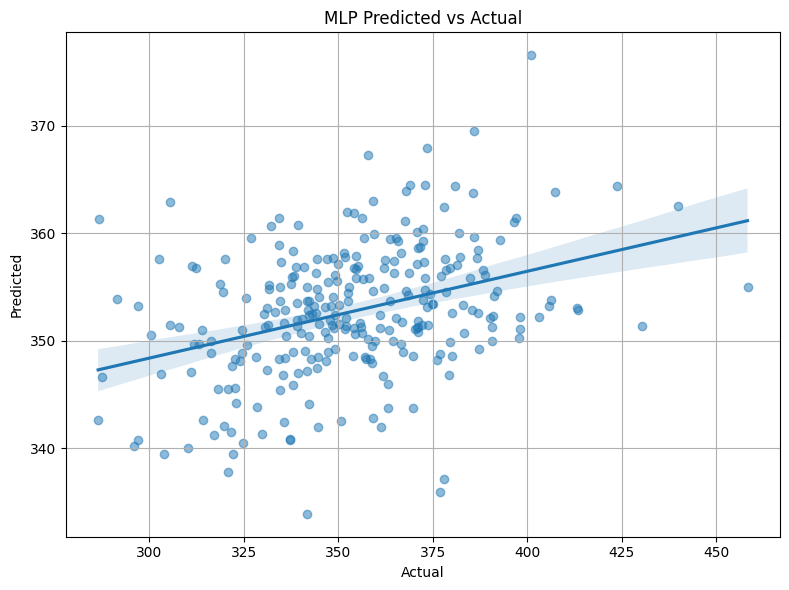

In [174]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

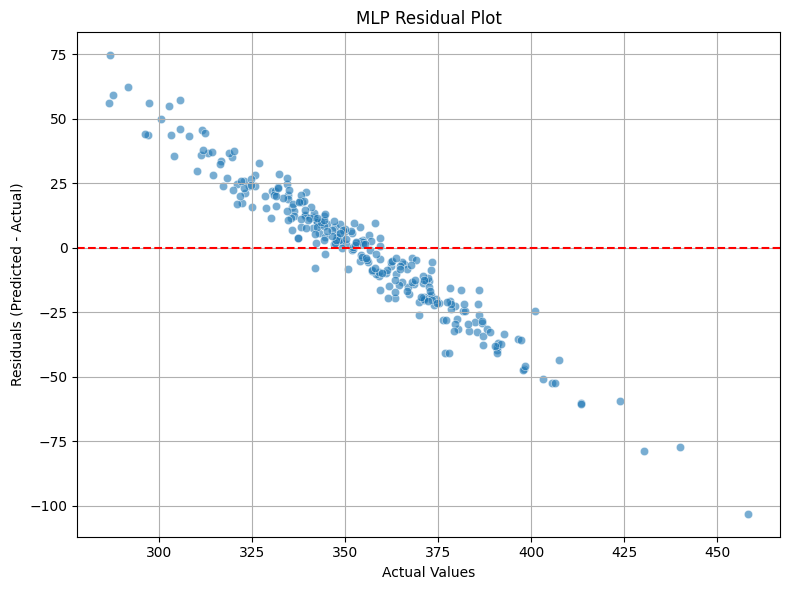

In [175]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

# GWAS

## GWAS top 1%

### All covariates

In [241]:
gwas_data = pd.read_pickle("pickle_files/GWAS_top1percent_prt_data.pkl")
gwas_data.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,1,0,2,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,0,0,0,0,0,1,0,2,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s101,0,0,1,2,0,0,2,0,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915
s1014,0,0,0,0,1,0,1,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,0,0,1,0,1,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667


In [242]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 2522 entries, Chr1_213719 to PRT
dtypes: float64(4), int64(2518)
memory usage: 21.1+ MB


In [243]:
gwas_y = gwas_data.iloc[:, 2521:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


In [244]:
gwas_all= gwas_data.drop(['PRT'], axis=1)
gwas_all.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_51326016,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,1,0,2,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,0,0,0,0,0,1,0,2,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s101,0,0,1,2,0,0,2,0,0,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1


In [245]:
gwas_all_dupe= gwas_data.drop(['PRT'], axis=1)
gwas_all_dupe.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_51326016,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,1,0,2,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,0,0,0,0,0,1,0,2,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s101,0,0,1,2,0,0,2,0,0,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1


In [246]:
X_tensor = torch.tensor(gwas_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [247]:
print(X_tensor.shape)

torch.Size([1094, 2521])


In [248]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [249]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 11:34:01,841] A new study created in memory with name: no-name-0f2d397c-57f8-4c75-bf4f-d5ec44123e1a
[I 2025-05-27 11:34:02,870] Trial 0 finished with value: 526.4492797851562 and parameters: {'hidden_size1': 200, 'dropout1': 0.013616000980235831, 'lr': 0.00026757236704271994, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.0036277783669270945, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout2': 0.011830403037122714}. Best is trial 0 with value: 526.4492797851562.


Early stopping at epoch 26


[I 2025-05-27 11:34:03,429] Trial 1 finished with value: 571.9942016601562 and parameters: {'hidden_size1': 100, 'dropout1': 0.01815523887415113, 'lr': 0.0034923675367940377, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1.401848270515743e-05, 'n_layers': 1}. Best is trial 0 with value: 526.4492797851562.


Early stopping at epoch 18


[I 2025-05-27 11:34:04,039] Trial 2 finished with value: 629.1035766601562 and parameters: {'hidden_size1': 200, 'dropout1': 0.07570845483919425, 'lr': 0.0021563855902263446, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0018386643669310878, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 526.4492797851562.


...

Early stopping at epoch 37


[I 2025-05-27 11:34:50,751] Trial 48 finished with value: 490.8450927734375 and parameters: {'hidden_size1': 200, 'dropout1': 0.039285131254989385, 'lr': 0.0001623887912881664, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0008867198218383256, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 40 with value: 460.1744384765625.


Early stopping at epoch 40


[I 2025-05-27 11:34:51,819] Trial 49 finished with value: 543.7601318359375 and parameters: {'hidden_size1': 300, 'dropout1': 0.0445713913642437, 'lr': 0.0001296042015209088, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 2.8577024676118744e-05, 'n_layers': 1}. Best is trial 40 with value: 460.1744384765625.


Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.05625926272940401, 'lr': 0.000542827459771594, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.006714777628195766, 'n_layers': 2, 'hidden_size2': 100}


In [250]:
#Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top1_best_model_allfeats_mlp_prt_test.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 23 for fold 1
Fold 1 validation loss: 470.3094
Training fold 2
Early stopping at epoch 26 for fold 2
Fold 2 validation loss: 597.4010
Training fold 3
Early stopping at epoch 35 for fold 3
Fold 3 validation loss: 483.4611
Training fold 4
Early stopping at epoch 32 for fold 4
Fold 4 validation loss: 462.6516
Training fold 5
Early stopping at epoch 29 for fold 5
Fold 5 validation loss: 551.2393
Training fold 6
Early stopping at epoch 36 for fold 6
Fold 6 validation loss: 621.8760
Training fold 7
Early stopping at epoch 30 for fold 7
Fold 7 validation loss: 551.2488
Training fold 8
Early stopping at epoch 28 for fold 8
Fold 8 validation loss: 724.9968
Training fold 9
Early stopping at epoch 26 for fold 9
Fold 9 validation loss: 541.4326
Training fold 10
Early stopping at epoch 30 for fold 10
Fold 10 validation loss: 515.3809

Average validation loss across all folds: 551.9997
Checkpoint saved as 'gwas_top1_best_model_allfeats_mlp_prt_test.pth'.


In [251]:
best_mlp_model

Sequential(
  (0): Linear(in_features=2521, out_features=300, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.05625926272940401, inplace=False)
  (3): Linear(in_features=300, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=1, bias=True)
)

In [252]:
print("Best hyperparameters found by Optuna:")
for key, value in best_params.items():
    print(f"{key}: {value}")

Best hyperparameters found by Optuna:
hidden_size1: 300
dropout1: 0.05625926272940401
lr: 0.000542827459771594
batch_size: 64
optimizer: Adam
weight_decay: 0.006714777628195766
n_layers: 2
hidden_size2: 100
num_epochs: 100
patience: 10


In [253]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [254]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [255]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [256]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [257]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [258]:
X_holdout.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_51326016,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,2,0,0,2,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,0,0,1,2,0,0,1,0,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,1,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,1,0,0,1,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,1,0,0,1,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [259]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 2521 entries, Chr1_213719 to landrace
dtypes: float64(3), int64(2518)
memory usage: 5.3+ MB


In [260]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [261]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 790.5961
RMSE: 28.1175
MAE: 22.6551
R2: -0.2585
Holdout_Loss: 790.5961


In [262]:
pickle.dump(best_mlp_model, open("gwas_top1_best_model_allfeats_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 365.6943
1 344.136 365.7165
2 351.481 341.87564
3 353.611 383.7581
4 390.342 353.66125
5 358.958 372.90195


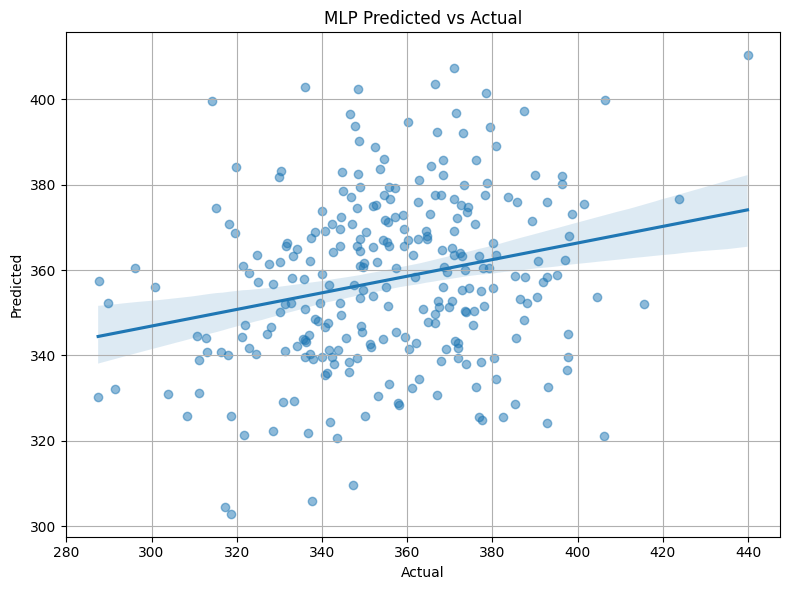

In [263]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

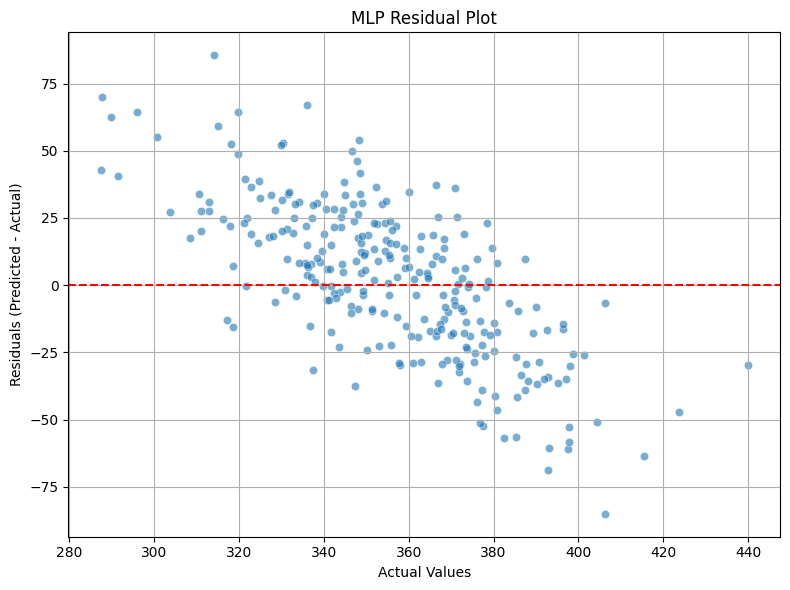

In [264]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [202]:
gwas_loc= gwas_data.drop(['PRT', 'LL',	'LW',	'PLH', 'BBD'], axis=1)
gwas_loc.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_47069666,Chr20_47283805,Chr20_47896428,Chr20_50361080,Chr20_51326016,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,1,0,1,0,0,0,1
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,1,0,0,1,0,0,1
s101,0,0,1,2,0,0,2,0,0,0,...,0,0,0,1,0,0,0,1,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,0,0,1,0,1,0,0,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,0,0,1,0,0,1,0,0,1


In [203]:
gwas_loc_dupe= gwas_data.drop(['PRT', 'LL',	'LW',	'PLH', 'BBD'], axis=1)
gwas_loc_dupe.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_47069666,Chr20_47283805,Chr20_47896428,Chr20_50361080,Chr20_51326016,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,1,0,1,0,0,0,1
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,1,0,0,1,0,0,1
s101,0,0,1,2,0,0,2,0,0,0,...,0,0,0,1,0,0,0,1,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,0,0,1,0,1,0,0,0,1
s1014,0,0,0,0,1,0,1,0,0,0,...,0,0,0,1,0,0,1,0,0,1


In [204]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 2517 entries, Chr1_213719 to landrace
dtypes: int64(2517)
memory usage: 21.0+ MB


In [207]:
gwas_y = gwas_data.iloc[:, 2521:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


In [208]:
X_tensor = torch.tensor(gwas_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [209]:
print(X_tensor.shape)

torch.Size([1094, 2517])


In [210]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [211]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 11:22:07,872] A new study created in memory with name: no-name-9ca8de27-c582-4cbd-9e13-d4526319abec
[I 2025-05-27 11:22:08,441] Trial 0 finished with value: 548.1988525390625 and parameters: {'hidden_size1': 300, 'dropout1': 0.03058849402746814, 'lr': 0.002075863391736396, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0002315876295792518, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 548.1988525390625.


Early stopping at epoch 27


[I 2025-05-27 11:22:10,595] Trial 1 finished with value: 889.3780517578125 and parameters: {'hidden_size1': 100, 'dropout1': 0.08043545397383237, 'lr': 0.003994499205417931, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0027885055431558564, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout2': 0.09329067289295667}. Best is trial 0 with value: 548.1988525390625.
[I 2025-05-27 11:22:10,933] Trial 2 finished with value: 536.827880859375 and parameters: {'hidden_size1': 300, 'dropout1': 0.08874316555068289, 'lr': 0.00489317299941103, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 3.3998780636188926e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout2': 0.03447853913709627}. Best is trial 2 with value: 536.827880859375.


Early stopping at epoch 24


[I 2025-05-27 11:22:11,324] Trial 3 finished with value: 2494.158203125 and parameters: {'hidden_size1': 100, 'dropout1': 0.06370475179359292, 'lr': 0.009842126472187648, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0009528511445110065, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 2 with value: 536.827880859375.


...

Early stopping at epoch 99


[I 2025-05-27 11:24:01,829] Trial 44 finished with value: 449.74822998046875 and parameters: {'hidden_size1': 200, 'dropout1': 0.06684343815921846, 'lr': 0.007707602113823354, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0073090999243097905, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout2': 0.07921100624850397}. Best is trial 31 with value: 434.12042236328125.
[I 2025-05-27 11:24:05,616] Trial 45 finished with value: 510.2552185058594 and parameters: {'hidden_size1': 200, 'dropout1': 0.07569371045075225, 'lr': 0.004363765646316351, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0018707385375477884, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout2': 0.030069721310565983}. Best is trial 31 with value: 434.12042236328125.
[I 2025-05-27 11:24:08,415] Trial 46 finished with value: 479.6842346191406 and parameters: {'hidden_size1': 200, 'dropout1': 0.061432411028079996, 'lr': 0.009970830195121296, 'batch_size': 32, 'optimizer': 'SGD', 'we

Early stopping at epoch 18


[I 2025-05-27 11:24:14,233] Trial 49 finished with value: 119075.71875 and parameters: {'hidden_size1': 200, 'dropout1': 0.04798754416414175, 'lr': 0.00165935800947014, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.002514771783143104, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout2': 0.04861759354814841}. Best is trial 31 with value: 434.12042236328125.


Best hyperparameters: {'hidden_size1': 200, 'dropout1': 0.06501647869066365, 'lr': 0.008559557102614176, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.007726558528696615, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout2': 0.04488203539983273}


In [212]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top1_best_model_onlyloc_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 22 for fold 1
Fold 1 validation loss: 430.3029
Training fold 2
Early stopping at epoch 24 for fold 2
Fold 2 validation loss: 558.1697
Training fold 3
Early stopping at epoch 20 for fold 3
Fold 3 validation loss: 393.0168
Training fold 4
Early stopping at epoch 21 for fold 4
Fold 4 validation loss: 434.9006
Training fold 5
Early stopping at epoch 46 for fold 5
Fold 5 validation loss: 470.7467
Training fold 6
Early stopping at epoch 26 for fold 6
Fold 6 validation loss: 477.0328
Training fold 7
Early stopping at epoch 21 for fold 7
Fold 7 validation loss: 549.7805
Training fold 8
Early stopping at epoch 21 for fold 8
Fold 8 validation loss: 588.9321
Training fold 9
Early stopping at epoch 17 for fold 9
Fold 9 validation loss: 506.4348
Training fold 10
Early stopping at epoch 31 for fold 10
Fold 10 validation loss: 506.0517

Average validation loss across all folds: 491.5368
Checkpoint saved as 'gwas_top1_best_model_onlyloc_mlp_prt.pth'.


In [213]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [214]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [215]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [216]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [217]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [218]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 2517 entries, Chr1_213719 to landrace
dtypes: int64(2517)
memory usage: 5.3+ MB


In [219]:
X_holdout.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_47069666,Chr20_47283805,Chr20_47896428,Chr20_50361080,Chr20_51326016,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,2,0,0,2,0,0,0,...,0,0,0,1,0,1,0,0,0,1
s102,0,0,1,2,0,0,1,0,0,0,...,0,0,0,1,0,0,0,1,0,1
s110,0,0,0,0,0,0,1,0,0,0,...,0,0,1,1,0,1,0,0,0,1
s112,0,0,0,1,0,0,1,0,0,0,...,0,0,0,1,0,1,0,0,0,1
s113,0,0,0,1,0,0,1,0,0,0,...,1,2,2,1,0,1,0,0,0,1


In [220]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [221]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 777.5068
RMSE: 27.8838
MAE: 21.9738
R2: -0.2377
Holdout_Loss: 777.5068


In [222]:
pickle.dump(best_mlp_model, open("'gwas_top1_best_model_onlyloc_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 392.6768
1 344.136 380.9375
2 351.481 316.29218
3 353.611 359.50714
4 390.342 342.3971
5 358.958 338.21402


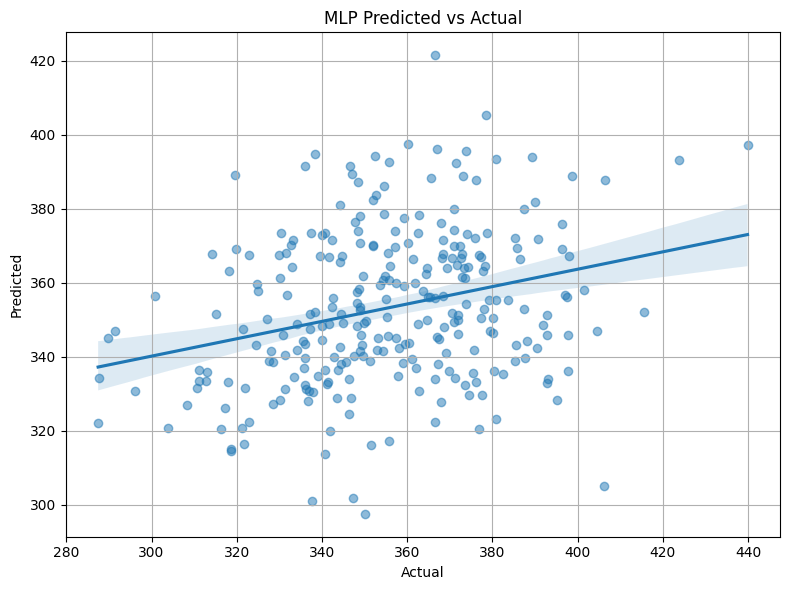

In [223]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

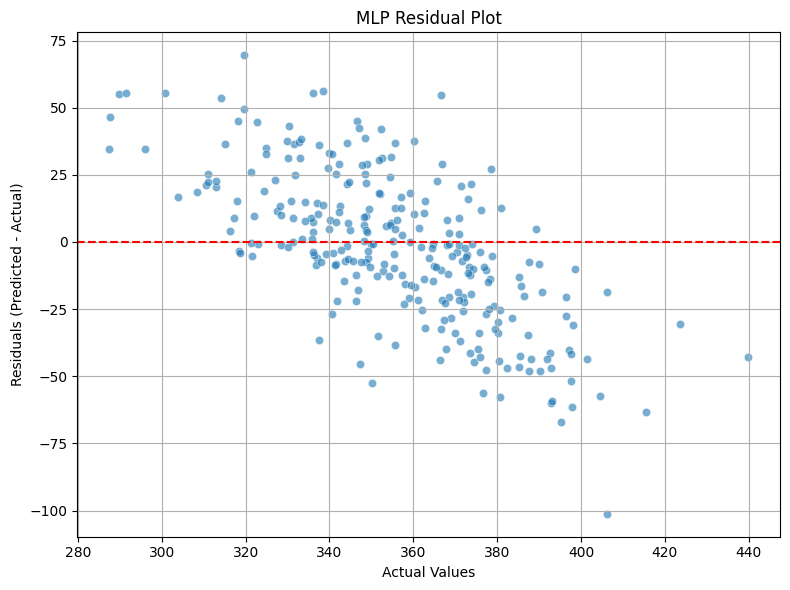

In [224]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [225]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 2522 entries, Chr1_213719 to PRT
dtypes: float64(4), int64(2518)
memory usage: 21.1+ MB


In [226]:
gwas_snps = gwas_data.iloc[:, 0:2512]
gwas_snps.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_43735393,Chr20_44853253,Chr20_45110567,Chr20_46932167,Chr20_47048517,Chr20_47069666,Chr20_47283805,Chr20_47896428,Chr20_50361080,Chr20_51326016
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,0,0,0,0,0,1,0
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,0,0,0,0,0,1,0
s101,0,0,1,2,0,0,2,0,0,0,...,1,0,1,0,1,0,0,0,1,0
s1014,0,0,0,0,1,0,1,0,0,0,...,0,2,2,0,0,0,0,0,1,0
s1014,0,0,0,0,1,0,1,0,0,0,...,0,2,2,0,0,0,0,0,1,0


In [227]:
gwas_snps_dupe = gwas_data.iloc[:, 0:2512]
gwas_snps_dupe.head()

,Chr1_213719,Chr1_213796,Chr1_213831,Chr1_541805,Chr1_4323656,Chr1_5028106,Chr1_6788897,Chr1_6926781,Chr1_7293438,Chr1_8122682,...,Chr20_43735393,Chr20_44853253,Chr20_45110567,Chr20_46932167,Chr20_47048517,Chr20_47069666,Chr20_47283805,Chr20_47896428,Chr20_50361080,Chr20_51326016
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,0,0,0,0,0,1,0
s100,0,0,0,0,0,0,1,0,2,0,...,0,0,0,0,0,0,0,0,1,0
s101,0,0,1,2,0,0,2,0,0,0,...,1,0,1,0,1,0,0,0,1,0
s1014,0,0,0,0,1,0,1,0,0,0,...,0,2,2,0,0,0,0,0,1,0
s1014,0,0,0,0,1,0,1,0,0,0,...,0,2,2,0,0,0,0,0,1,0


In [229]:
gwas_y = gwas_data.iloc[:, 2521:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


In [230]:
X_tensor = torch.tensor(gwas_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [231]:
print(X_tensor.shape)

torch.Size([1094, 2512])


In [232]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [233]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 11:29:45,746] A new study created in memory with name: no-name-24993543-bc00-48eb-aa68-5bde1bd70b21
[I 2025-05-27 11:29:47,036] Trial 0 finished with value: 127048.90625 and parameters: {'hidden_size1': 200, 'dropout1': 0.011708262997604144, 'lr': 0.0005111691736991566, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.009263084705878433, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout2': 0.05717172152825428}. Best is trial 0 with value: 127048.90625.
[I 2025-05-27 11:29:48,417] Trial 1 finished with value: 520.1215209960938 and parameters: {'hidden_size1': 200, 'dropout1': 0.09379573434140653, 'lr': 0.00013121081033949745, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 1.682316725168733e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.0918456904499453}. Best is trial 1 with value: 520.1215209960938.
[I 2025-05-27 11:29:48,853] Trial 2 finished with value: 688.499267578125 and parameters: {'hidden_size1': 200, 'dr

Early stopping at epoch 31


[I 2025-05-27 11:29:50,739] Trial 3 finished with value: 518.6480712890625 and parameters: {'hidden_size1': 200, 'dropout1': 0.08775926301201412, 'lr': 0.008085452414148478, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.003978203876803351, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 3 with value: 518.6480712890625.
[I 2025-05-27 11:29:52,697] Trial 4 finished with value: 492.4939880371094 and parameters: {'hidden_size1': 100, 'dropout1': 0.03351763043073572, 'lr': 0.00031503255452773116, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0029306781345658822, 'n_layers': 1}. Best is trial 4 with value: 492.4939880371094.


Early stopping at epoch 63


[I 2025-05-27 11:29:53,059] Trial 5 finished with value: 2436.646484375 and parameters: {'hidden_size1': 300, 'dropout1': 0.03269618201151146, 'lr': 0.007386256679520149, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0024332170893233214, 'n_layers': 1}. Best is trial 4 with value: 492.4939880371094.


...

Early stopping at epoch 82


[I 2025-05-27 11:30:47,606] Trial 47 finished with value: 554.7872924804688 and parameters: {'hidden_size1': 300, 'dropout1': 0.06914079986760123, 'lr': 0.0005584688416573884, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0011605835602696455, 'n_layers': 1}. Best is trial 42 with value: 457.8296203613281.


Early stopping at epoch 30


[I 2025-05-27 11:30:49,252] Trial 48 finished with value: 122466.6875 and parameters: {'hidden_size1': 100, 'dropout1': 0.05667027810182691, 'lr': 0.0004352432266709214, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0001767010194122349, 'n_layers': 1}. Best is trial 42 with value: 457.8296203613281.
[I 2025-05-27 11:30:49,541] Trial 49 finished with value: 514.1526489257812 and parameters: {'hidden_size1': 200, 'dropout1': 0.034602343145242395, 'lr': 0.0011380375819599912, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.003865177885257973, 'n_layers': 1}. Best is trial 42 with value: 457.8296203613281.


Early stopping at epoch 26
Best hyperparameters: {'hidden_size1': 100, 'dropout1': 0.05812528813694356, 'lr': 0.0004489369340464061, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.004065838829748128, 'n_layers': 1}


In [234]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top1_best_model_onlysnps_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 76 for fold 1
Fold 1 validation loss: 440.2317
Training fold 2
Early stopping at epoch 45 for fold 2
Fold 2 validation loss: 592.6140
Training fold 3
Early stopping at epoch 51 for fold 3
Fold 3 validation loss: 405.2498
Training fold 4
Early stopping at epoch 56 for fold 4
Fold 4 validation loss: 436.3240
Training fold 5
Early stopping at epoch 99 for fold 5
Fold 5 validation loss: 463.9308
Training fold 6
Early stopping at epoch 62 for fold 6
Fold 6 validation loss: 490.3940
Training fold 7
Early stopping at epoch 61 for fold 7
Fold 7 validation loss: 529.8159
Training fold 8
Early stopping at epoch 57 for fold 8
Fold 8 validation loss: 598.8705
Training fold 9
Early stopping at epoch 50 for fold 9
Fold 9 validation loss: 496.8661
Training fold 10
Early stopping at epoch 74 for fold 10
Fold 10 validation loss: 501.7076

Average validation loss across all folds: 495.6005
Checkpoint saved as 'gwas_top1_best_model_onlysnps_mlp_prt.pth'.


In [235]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [236]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [237]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [238]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [239]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [240]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 780.9010
RMSE: 27.9446
MAE: 22.1540
R2: -0.2431
Holdout_Loss: 780.9010


In [92]:
pickle.dump(best_mlp_model, open("gwas_top1_best_model_onlysnps_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

## Top 5% SNPs

### All covariates

In [324]:
gwas_data = pd.read_pickle("pickle_files/GWAS_top5percent_prt_data.pkl")
gwas_data.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,0,0,0,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s101,0,0,0,0,0,0,0,1,1,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915
s1014,0,0,0,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,0,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667


In [325]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 12571 entries, Chr1_17750 to PRT
dtypes: float64(4), int64(12567)
memory usage: 104.9+ MB


In [268]:
gwas_y = gwas_data.iloc[:, 12570:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


In [269]:
gwas_all= gwas_data.drop(['PRT'], axis=1)
gwas_all.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_52241655,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s101,0,0,0,0,0,0,0,1,1,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1


In [270]:
gwas_all_dupe= gwas_data.drop(['PRT'], axis=1)
gwas_all_dupe.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_52241655,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s101,0,0,0,0,0,0,0,1,1,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1


In [271]:
X_tensor = torch.tensor(gwas_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [272]:
print(X_tensor.shape)

torch.Size([1094, 12570])


In [273]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [274]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 11:41:08,580] A new study created in memory with name: no-name-d5996c73-af59-450d-a9e2-9e6f60602d2a
[I 2025-05-27 11:41:09,626] Trial 0 finished with value: 1152.12744140625 and parameters: {'hidden_size1': 200, 'dropout1': 0.029966523423609386, 'lr': 0.000958156029253708, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 3.550239961255094e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 0 with value: 1152.12744140625.


Early stopping at epoch 30


[I 2025-05-27 11:41:10,454] Trial 1 finished with value: 467.2954406738281 and parameters: {'hidden_size1': 100, 'dropout1': 0.048692124919272474, 'lr': 0.00011603769855395249, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0012615255024052098, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 1 with value: 467.2954406738281.


Early stopping at epoch 65


[I 2025-05-27 11:41:14,270] Trial 2 finished with value: 123831.484375 and parameters: {'hidden_size1': 200, 'dropout1': 0.0995740486984552, 'lr': 0.00011737410142414002, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 9.876014331818034e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.012923798806129847}. Best is trial 1 with value: 467.2954406738281.
[I 2025-05-27 11:41:18,105] Trial 3 finished with value: 114075.8125 and parameters: {'hidden_size1': 100, 'dropout1': 0.04477724244990539, 'lr': 0.00023694116427988175, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0009532306606489685, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout2': 0.019965393950468903}. Best is trial 1 with value: 467.2954406738281.
[I 2025-05-27 11:41:18,581] Trial 4 finished with value: 578.8056640625 and parameters: {'hidden_size1': 300, 'dropout1': 0.08885551718008207, 'lr': 0.0008435593247719145, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 1

...

Early stopping at epoch 73


[I 2025-05-27 11:41:58,267] Trial 47 finished with value: 122676.90625 and parameters: {'hidden_size1': 200, 'dropout1': 0.07079312356413851, 'lr': 0.00040575578740592393, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 1.113790894533351e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 13 with value: 431.1065368652344.
[I 2025-05-27 11:41:58,820] Trial 48 finished with value: 592.3088989257812 and parameters: {'hidden_size1': 100, 'dropout1': 0.09146320921868341, 'lr': 0.0009970352329525258, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0005272875609205114, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 13 with value: 431.1065368652344.


Early stopping at epoch 27


[I 2025-05-27 11:41:59,982] Trial 49 finished with value: 450.79962158203125 and parameters: {'hidden_size1': 100, 'dropout1': 0.04859148390976194, 'lr': 0.00020509851081059417, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0002343761502164601, 'n_layers': 1}. Best is trial 13 with value: 431.1065368652344.


Early stopping at epoch 36
Best hyperparameters: {'hidden_size1': 100, 'dropout1': 0.07351959296093015, 'lr': 0.00011044873020132091, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0025994635326230487, 'n_layers': 2, 'hidden_size2': 150}


In [275]:
#Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top5_best_model_allfeats_mlp_prt_test.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 69 for fold 1
Fold 1 validation loss: 421.0238
Training fold 2
Early stopping at epoch 76 for fold 2
Fold 2 validation loss: 470.3368
Training fold 3
Early stopping at epoch 60 for fold 3
Fold 3 validation loss: 413.0334
Training fold 4
Early stopping at epoch 67 for fold 4
Fold 4 validation loss: 439.6320
Training fold 5
Early stopping at epoch 74 for fold 5
Fold 5 validation loss: 436.4140
Training fold 6
Early stopping at epoch 61 for fold 6
Fold 6 validation loss: 471.6608
Training fold 7
Early stopping at epoch 80 for fold 7
Fold 7 validation loss: 481.8986
Training fold 8
Early stopping at epoch 66 for fold 8
Fold 8 validation loss: 587.1094
Training fold 9
Early stopping at epoch 65 for fold 9
Fold 9 validation loss: 428.0368
Training fold 10
Early stopping at epoch 74 for fold 10
Fold 10 validation loss: 410.2377

Average validation loss across all folds: 455.9383
Checkpoint saved as 'gwas_top5_best_model_allfeats_mlp_prt_test.pth'.


In [276]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [277]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [278]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [279]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [280]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [281]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 12570 entries, Chr1_17750 to landrace
dtypes: float64(3), int64(12567)
memory usage: 26.3+ MB


In [282]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [283]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 683.6074
RMSE: 26.1459
MAE: 21.0025
R2: -0.0882
Holdout_Loss: 683.6074


In [284]:
pickle.dump(best_mlp_model, open("gwas_top5_best_model_allfeats_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 367.0426
1 344.136 362.0253
2 351.481 342.88336
3 353.611 373.37454
4 390.342 349.06345
5 358.958 360.8522


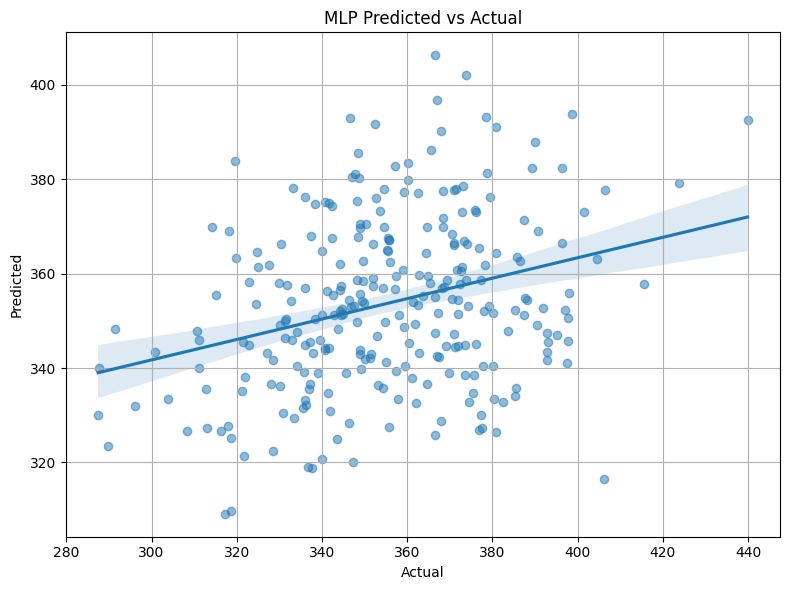

In [285]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

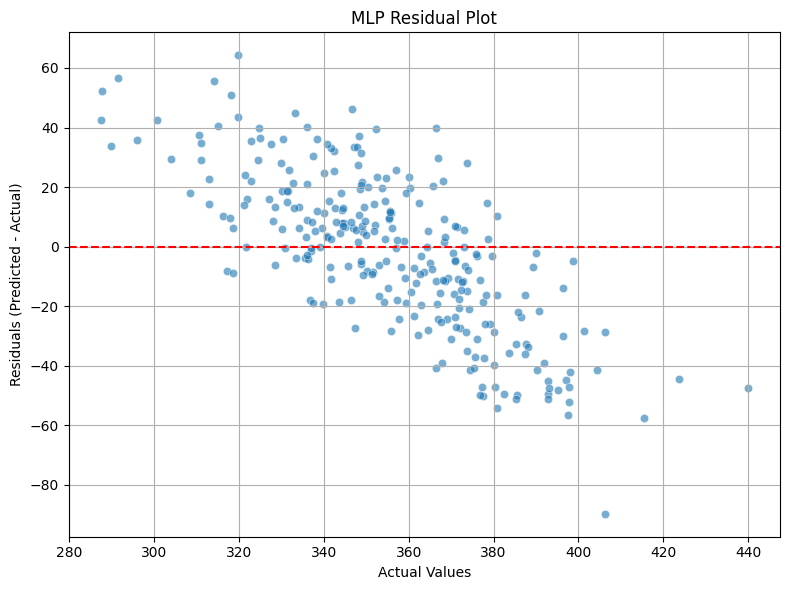

In [286]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [287]:
gwas_loc= gwas_data.drop(['PRT', 'LL',	'LW',	'PLH', 'BBD'], axis=1)
gwas_loc.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_51568577,Chr20_51595684,Chr20_51888995,Chr20_51890470,Chr20_52241655,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
s101,0,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1


In [288]:
gwas_loc_dupe= gwas_data.drop(['PRT', 'LL',	'LW',	'PLH', 'BBD'], axis=1)
gwas_loc_dupe.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_51568577,Chr20_51595684,Chr20_51888995,Chr20_51890470,Chr20_52241655,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
s101,0,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1


In [289]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 12566 entries, Chr1_17750 to landrace
dtypes: int64(12566)
memory usage: 104.9+ MB


In [290]:
gwas_y = gwas_data.iloc[:, 12570:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


In [291]:
X_tensor = torch.tensor(gwas_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [292]:
print(X_tensor.shape)

torch.Size([1094, 12566])


In [293]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [294]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 11:49:24,495] A new study created in memory with name: no-name-3f7d8b5f-c9e6-40d1-bd6a-05545b6d0ef3
[I 2025-05-27 11:49:24,916] Trial 0 finished with value: 869.1796875 and parameters: {'hidden_size1': 300, 'dropout1': 0.08647099465417916, 'lr': 0.0021054170132423387, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.001549883906331905, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 869.1796875.


Early stopping at epoch 18


[I 2025-05-27 11:49:26,107] Trial 1 finished with value: 492.906982421875 and parameters: {'hidden_size1': 300, 'dropout1': 0.06997590319070852, 'lr': 0.00010918392775156953, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 5.463185497252275e-05, 'n_layers': 1}. Best is trial 1 with value: 492.906982421875.


Early stopping at epoch 59


[I 2025-05-27 11:49:26,803] Trial 2 finished with value: 491.5768737792969 and parameters: {'hidden_size1': 300, 'dropout1': 0.06954054904693913, 'lr': 0.00016211606699574878, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0006787732107891078, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 2 with value: 491.5768737792969.


...

Early stopping at epoch 97


[I 2025-05-27 11:51:06,593] Trial 47 finished with value: 437.4378967285156 and parameters: {'hidden_size1': 100, 'dropout1': 0.025331104369755063, 'lr': 0.005230841229138103, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.009405466118563688, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.011141104493453735}. Best is trial 46 with value: 388.4400939941406.
[I 2025-05-27 11:51:08,279] Trial 48 finished with value: 522.6620483398438 and parameters: {'hidden_size1': 100, 'dropout1': 0.020372786450368864, 'lr': 0.00010946207861202965, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 2.183609498130828e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.0519582591247799}. Best is trial 46 with value: 388.4400939941406.


Early stopping at epoch 42


[I 2025-05-27 11:51:09,608] Trial 49 finished with value: 108356.5625 and parameters: {'hidden_size1': 100, 'dropout1': 0.015776132467082468, 'lr': 0.0016047214385541324, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 1.3852047030268538e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout2': 0.04366764643355584}. Best is trial 46 with value: 388.4400939941406.


Best hyperparameters: {'hidden_size1': 100, 'dropout1': 0.027268969956228573, 'lr': 0.0053200266124298415, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.009019060227793576, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.011309841601361122}


In [295]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top5_best_model_onlyloc_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 23 for fold 1
Fold 1 validation loss: 405.4202
Training fold 2
Early stopping at epoch 21 for fold 2
Fold 2 validation loss: 471.6427
Training fold 3
Early stopping at epoch 19 for fold 3
Fold 3 validation loss: 409.1852
Training fold 4
Early stopping at epoch 22 for fold 4
Fold 4 validation loss: 419.6022
Training fold 5
Early stopping at epoch 25 for fold 5
Fold 5 validation loss: 385.0524
Training fold 6
Early stopping at epoch 22 for fold 6
Fold 6 validation loss: 383.6759
Training fold 7
Early stopping at epoch 22 for fold 7
Fold 7 validation loss: 484.7781
Training fold 8
Early stopping at epoch 21 for fold 8
Fold 8 validation loss: 530.9458
Training fold 9
Early stopping at epoch 22 for fold 9
Fold 9 validation loss: 390.5415
Training fold 10
Early stopping at epoch 32 for fold 10
Fold 10 validation loss: 428.1450

Average validation loss across all folds: 430.8989
Checkpoint saved as 'gwas_top5_best_model_onlyloc_mlp_prt.pth'.


In [296]:
best_mlp_model

Sequential(
  (0): Linear(in_features=12566, out_features=100, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.027268969956228573, inplace=False)
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.011309841601361122, inplace=False)
  (6): Linear(in_features=100, out_features=50, bias=True)
  (7): ReLU()
  (8): Linear(in_features=50, out_features=1, bias=True)
)

In [297]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [298]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [299]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [300]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 12566 entries, Chr1_17750 to landrace
dtypes: int64(12566)
memory usage: 26.3+ MB


In [301]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [302]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 693.2816
RMSE: 26.3302
MAE: 20.8453
R2: -0.1036
Holdout_Loss: 693.2816


In [303]:
pickle.dump(best_mlp_model, open("'gwas_top5_best_model_onlyloc_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 381.31055
1 344.136 359.402
2 351.481 337.31482
3 353.611 370.35635
4 390.342 349.33267
5 358.958 355.5259


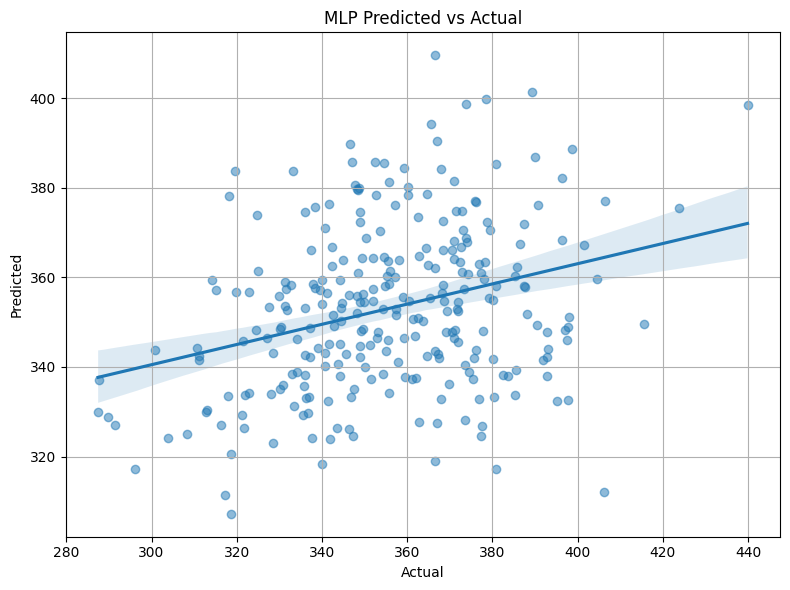

In [304]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

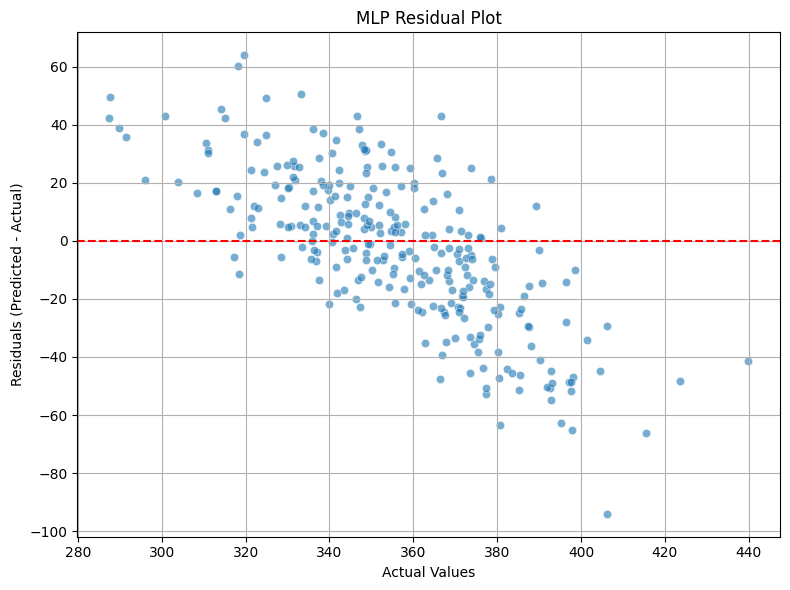

In [305]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [306]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 12571 entries, Chr1_17750 to PRT
dtypes: float64(4), int64(12567)
memory usage: 104.9+ MB


In [307]:
gwas_snps = gwas_data.iloc[:, 0:12561]
gwas_snps.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_51124213,Chr20_51274941,Chr20_51322653,Chr20_51326016,Chr20_51476391,Chr20_51568577,Chr20_51595684,Chr20_51888995,Chr20_51890470,Chr20_52241655
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s101,0,0,0,0,0,0,0,1,1,0,...,2,1,1,0,0,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0


In [308]:
gwas_snps_dupe = gwas_data.iloc[:, 0:12561]
gwas_snps_dupe.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_51124213,Chr20_51274941,Chr20_51322653,Chr20_51326016,Chr20_51476391,Chr20_51568577,Chr20_51595684,Chr20_51888995,Chr20_51890470,Chr20_52241655
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s101,0,0,0,0,0,0,0,1,1,0,...,2,1,1,0,0,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0


In [310]:
gwas_y = gwas_data.iloc[:, 12570:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


In [311]:
X_tensor = torch.tensor(gwas_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [312]:
print(X_tensor.shape)

torch.Size([1094, 12561])


In [313]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [314]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 11:54:03,847] A new study created in memory with name: no-name-5e4510e6-4505-40c0-99ae-4e33d63450df
[I 2025-05-27 11:54:04,400] Trial 0 finished with value: 553.7576293945312 and parameters: {'hidden_size1': 300, 'dropout1': 0.029881996871679875, 'lr': 0.0009530001765147173, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 8.285459012272857e-05, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout2': 0.03125772208394874}. Best is trial 0 with value: 553.7576293945312.


Early stopping at epoch 21


[I 2025-05-27 11:54:05,405] Trial 1 finished with value: 489.493896484375 and parameters: {'hidden_size1': 100, 'dropout1': 0.060000396253170635, 'lr': 0.0002329315163432301, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0002413140029019688, 'n_layers': 1}. Best is trial 1 with value: 489.493896484375.


Early stopping at epoch 87


[I 2025-05-27 11:54:08,693] Trial 2 finished with value: 77589.0 and parameters: {'hidden_size1': 100, 'dropout1': 0.06365902030817527, 'lr': 0.0005652778888536971, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 7.349618061567299e-05, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 1 with value: 489.493896484375.
[I 2025-05-27 11:54:10,982] Trial 3 finished with value: 126411.1171875 and parameters: {'hidden_size1': 300, 'dropout1': 0.05530165794539395, 'lr': 0.0003206436419848305, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 1.3321531652890567e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout2': 0.04508851462224472}. Best is trial 1 with value: 489.493896484375.
[I 2025-05-27 11:54:12,247] Trial 4 finished with value: 904.5745849609375 and parameters: {'hidden_size1': 300, 'dropout1': 0.03903143652784674, 'lr': 0.005623568081643394, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.001377867994896159, 'n_layers': 2, 'hidden_size2': 50}. Bes

...

Early stopping at epoch 35


[I 2025-05-27 11:55:01,732] Trial 48 finished with value: 438.1795959472656 and parameters: {'hidden_size1': 100, 'dropout1': 0.05280404340405363, 'lr': 0.00016536548232945605, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.004251781817423878, 'n_layers': 1}. Best is trial 43 with value: 420.1293029785156.


Early stopping at epoch 86


[I 2025-05-27 11:55:02,595] Trial 49 finished with value: 431.8571472167969 and parameters: {'hidden_size1': 300, 'dropout1': 0.07876484135140804, 'lr': 0.00040156551323065095, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.009879641332777401, 'n_layers': 1}. Best is trial 43 with value: 420.1293029785156.


Early stopping at epoch 42
Best hyperparameters: {'hidden_size1': 100, 'dropout1': 0.05940956627922665, 'lr': 0.00013105427237571714, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.002816838444602929, 'n_layers': 1}


In [315]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top5_best_model_onlysnps_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 94 for fold 1
Fold 1 validation loss: 427.0699
Training fold 2
Early stopping at epoch 72 for fold 2
Fold 2 validation loss: 492.2241
Training fold 3
Early stopping at epoch 60 for fold 3
Fold 3 validation loss: 376.1574
Training fold 4
Early stopping at epoch 79 for fold 4
Fold 4 validation loss: 429.2166
Training fold 5
Early stopping at epoch 78 for fold 5
Fold 5 validation loss: 432.5735
Training fold 6
Early stopping at epoch 79 for fold 6
Fold 6 validation loss: 429.5500
Training fold 7
Early stopping at epoch 70 for fold 7
Fold 7 validation loss: 489.5227
Training fold 8
Early stopping at epoch 74 for fold 8
Fold 8 validation loss: 539.3531
Training fold 9
Early stopping at epoch 77 for fold 9
Fold 9 validation loss: 430.6259
Training fold 10
Early stopping at epoch 83 for fold 10
Fold 10 validation loss: 424.4135

Average validation loss across all folds: 447.0707
Checkpoint saved as 'gwas_top5_best_model_onlysnps_mlp_prt.pth'.


In [316]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [317]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [318]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [319]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [320]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 650.9229
RMSE: 25.5132
MAE: 20.2629
R2: -0.0362
Holdout_Loss: 650.9229


In [321]:
pickle.dump(best_mlp_model, open("gwas_top5_best_model_onlysnps_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 364.09158
1 344.136 367.56067
2 351.481 332.94302
3 353.611 371.63776
4 390.342 355.88638
5 358.958 349.73724


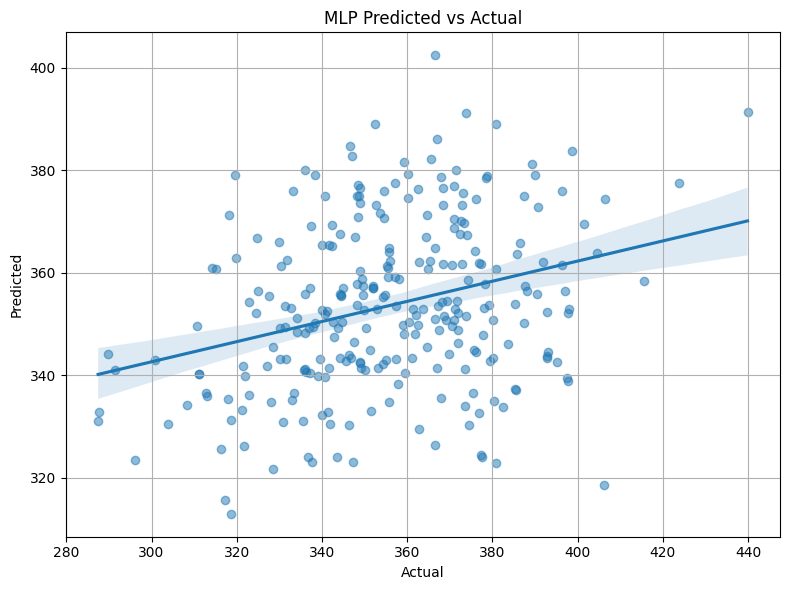

In [322]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

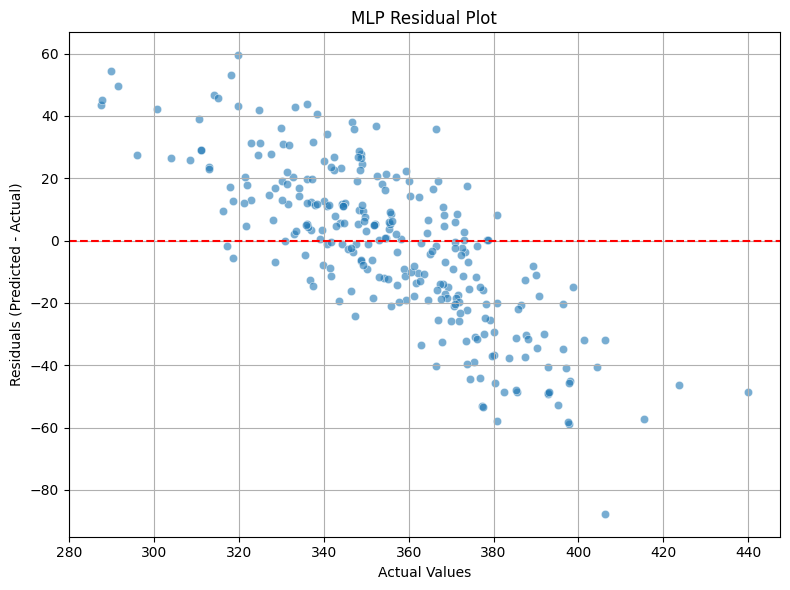

In [323]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

## Top 10% SNPs

In [70]:
gwas_data = pd.read_pickle("pickle_files/GWAS_top10percent_prt_data.pkl")
gwas_data.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,1,1,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,1,1,1,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s101,0,0,0,0,0,0,0,0,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915
s1014,0,0,1,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,1,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667


In [71]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 25133 entries, Chr1_17750 to PRT
dtypes: float64(4), int64(25129)
memory usage: 209.8+ MB


In [72]:
gwas_y = gwas_data.iloc[:, 25132:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


In [73]:
gwas_y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PRT     1094 non-null   float64
dtypes: float64(1)
memory usage: 17.1+ KB


### All covariates

In [74]:
gwas_all= gwas_data.drop(['PRT'], axis=1)
gwas_all.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,1,1,0,0,0,0,0,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,1,1,1,0,0,0,0,0,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s101,0,0,0,0,0,0,0,0,0,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1


In [75]:
gwas_all_dupe= gwas_data.drop(['PRT'], axis=1)
gwas_all_dupe.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,1,1,0,0,0,0,0,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,1,1,1,0,0,0,0,0,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s101,0,0,0,0,0,0,0,0,0,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1


In [76]:
gwas_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 25132 entries, Chr1_17750 to landrace
dtypes: float64(3), int64(25129)
memory usage: 209.8+ MB


In [77]:
X_tensor = torch.tensor(gwas_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [78]:
print(X_tensor.shape)

torch.Size([1094, 25132])


In [79]:
print(y_tensor.shape)

torch.Size([1094, 1])


In [80]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [81]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 13:37:08,054] A new study created in memory with name: no-name-9163026a-2b31-402a-ab8d-29639fec87d8
[I 2025-05-27 13:37:09,587] Trial 0 finished with value: 661.5060424804688 and parameters: {'hidden_size1': 100, 'dropout1': 0.0616828786565077, 'lr': 0.008873922404360598, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.00018529820994945563, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.08733832594224396}. Best is trial 0 with value: 661.5060424804688.
[I 2025-05-27 13:37:09,771] Trial 1 finished with value: 949.0664672851562 and parameters: {'hidden_size1': 200, 'dropout1': 0.030517400732967492, 'lr': 0.001892412242204484, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.0017617416600128246, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 661.5060424804688.


Early stopping at epoch 11


[I 2025-05-27 13:37:14,180] Trial 2 finished with value: 124613.84375 and parameters: {'hidden_size1': 300, 'dropout1': 0.07098241482626333, 'lr': 0.00012589874330240765, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0001386987554125972, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout2': 0.03489630023910924}. Best is trial 0 with value: 661.5060424804688.
[I 2025-05-27 13:37:16,471] Trial 3 finished with value: 93067.4453125 and parameters: {'hidden_size1': 300, 'dropout1': 0.08362327233113943, 'lr': 0.0006032928925003364, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.006894669652736195, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 0 with value: 661.5060424804688.
[I 2025-05-27 13:37:17,076] Trial 4 finished with value: 1863.77587890625 and parameters: {'hidden_size1': 300, 'dropout1': 0.045854693063679876, 'lr': 0.0016583144875844983, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.004840560191327334, 'n_layers': 3, 'hidden_size2': 

Early stopping at epoch 29


[I 2025-05-27 13:37:17,509] Trial 5 finished with value: 611.1610107421875 and parameters: {'hidden_size1': 200, 'dropout1': 0.07607765654580613, 'lr': 0.0011597739318172633, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 7.880092238390938e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout2': 0.04397930548095689}. Best is trial 5 with value: 611.1610107421875.


...

Early stopping at epoch 37


[I 2025-05-27 13:38:15,105] Trial 48 finished with value: 438.52520751953125 and parameters: {'hidden_size1': 100, 'dropout1': 0.07710263287354677, 'lr': 0.000586879431004486, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0016013921731399552, 'n_layers': 1}. Best is trial 31 with value: 406.5511779785156.


Early stopping at epoch 27


[I 2025-05-27 13:38:17,071] Trial 49 finished with value: 106746.34375 and parameters: {'hidden_size1': 100, 'dropout1': 0.03917300012754904, 'lr': 0.0003481371463611437, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0025306622793618556, 'n_layers': 1}. Best is trial 31 with value: 406.5511779785156.


Best hyperparameters: {'hidden_size1': 100, 'dropout1': 0.06260417334352969, 'lr': 0.00015477008902413676, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0035707599320337034, 'n_layers': 1}


In [82]:
#Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top10_best_model_allfeats_mlp_prt_test.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 43 for fold 1
Fold 1 validation loss: 396.8370
Training fold 2
Early stopping at epoch 42 for fold 2
Fold 2 validation loss: 488.1415
Training fold 3
Early stopping at epoch 35 for fold 3
Fold 3 validation loss: 400.1835
Training fold 4
Early stopping at epoch 39 for fold 4
Fold 4 validation loss: 443.3110
Training fold 5
Early stopping at epoch 34 for fold 5
Fold 5 validation loss: 445.3708
Training fold 6
Early stopping at epoch 28 for fold 6
Fold 6 validation loss: 462.9310
Training fold 7
Early stopping at epoch 59 for fold 7
Fold 7 validation loss: 496.5008
Training fold 8
Early stopping at epoch 26 for fold 8
Fold 8 validation loss: 619.8952
Training fold 9
Early stopping at epoch 38 for fold 9
Fold 9 validation loss: 421.1740
Training fold 10
Early stopping at epoch 41 for fold 10
Fold 10 validation loss: 405.9294

Average validation loss across all folds: 458.0274
Checkpoint saved as 'gwas_top10_best_model_allfeats_mlp_prt_test.pth'.


In [83]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [84]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [85]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [86]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [87]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [88]:
X_holdout.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,0,0,0,0,0,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,0,0,0,0,0,0,0,0,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,1,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,1,2,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,1,0,1,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [89]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [90]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 630.1432
RMSE: 25.1027
MAE: 19.9974
R2: -0.0031
Holdout_Loss: 630.1432


In [91]:
pickle.dump(best_mlp_model, open("gwas_top10_best_model_allfeats_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 356.98685
1 344.136 368.21637
2 351.481 348.38208
3 353.611 380.9301
4 390.342 358.30014
5 358.958 354.29187


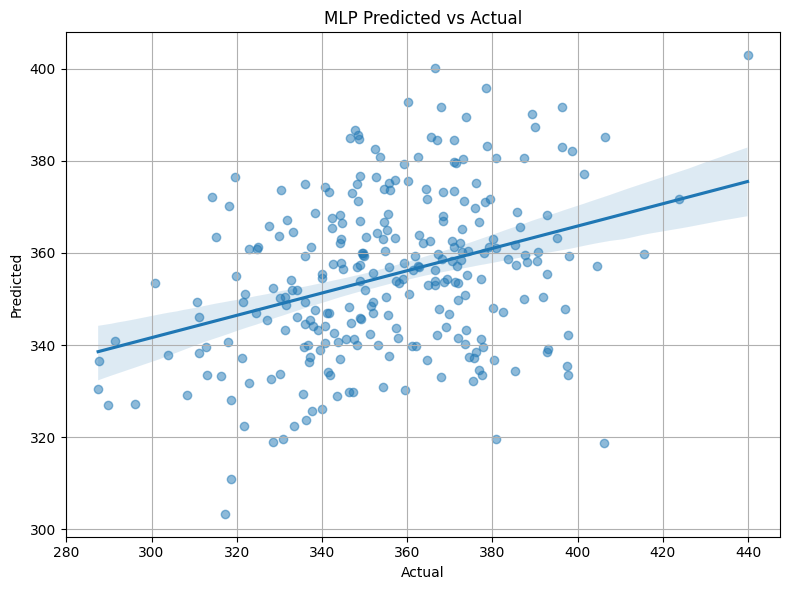

In [92]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

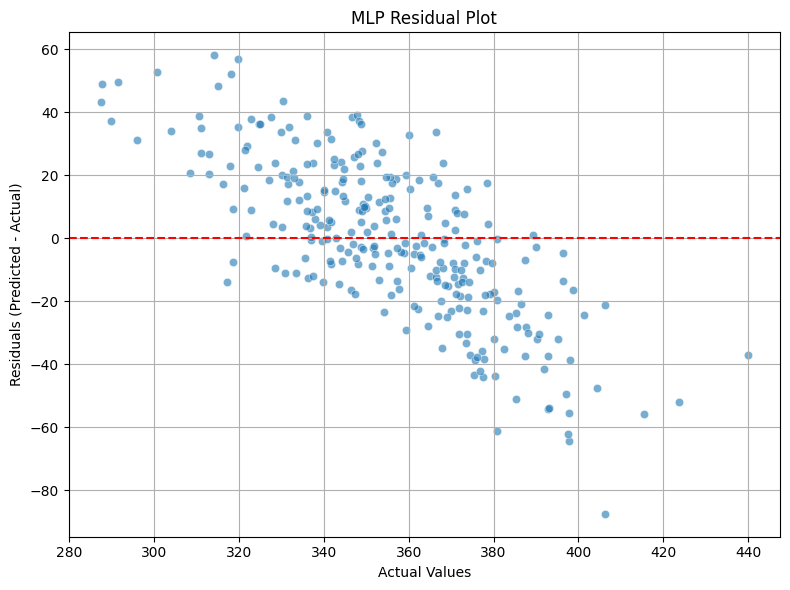

In [93]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only Location

In [51]:
gwas_loc= gwas_data.drop(['PRT', 'LL',	'LW',	'PLH', 'BBD'], axis=1)
gwas_loc.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52241655,Chr20_52270629,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,1,1,0,0,0,0,0,0,...,2,0,0,0,0,1,0,0,0,1
s100,0,1,1,1,0,0,0,0,0,0,...,2,0,0,0,0,0,1,0,0,1
s101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,2,0,0,0,0,1,0,0,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,2,0,0,0,0,0,1,0,0,1


In [52]:
gwas_loc_dupe= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'PRT'], axis=1)
gwas_loc_dupe.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52241655,Chr20_52270629,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,1,1,0,0,0,0,0,0,...,2,0,0,0,0,1,0,0,0,1
s100,0,1,1,1,0,0,0,0,0,0,...,2,0,0,0,0,0,1,0,0,1
s101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,2,0,0,0,0,1,0,0,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,2,0,0,0,0,0,1,0,0,1


In [53]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 25128 entries, Chr1_17750 to landrace
dtypes: int64(25128)
memory usage: 209.7+ MB


In [55]:
gwas_y = gwas_data.iloc[:, 25132:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


In [56]:
X_tensor = torch.tensor(gwas_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [57]:
print(X_tensor.shape)

torch.Size([1094, 25128])


In [58]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [59]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 13:30:21,940] A new study created in memory with name: no-name-91758a1d-1cfa-4f13-bbd3-5cf0168ba71f
[I 2025-05-27 13:30:22,214] Trial 0 finished with value: 36774.7734375 and parameters: {'hidden_size1': 200, 'dropout1': 0.042282888375100115, 'lr': 0.008102867391911482, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.0013106439327528498, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 36774.7734375.


Early stopping at epoch 17


[I 2025-05-27 13:30:24,402] Trial 1 finished with value: 123951.5703125 and parameters: {'hidden_size1': 100, 'dropout1': 0.0691948602161185, 'lr': 0.00021098532217898045, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0005467892655485507, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 0 with value: 36774.7734375.
[I 2025-05-27 13:30:25,977] Trial 2 finished with value: 17461.89453125 and parameters: {'hidden_size1': 300, 'dropout1': 0.03289114300494152, 'lr': 0.002838545633158545, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 4.6590809050351405e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.08943936462990464}. Best is trial 2 with value: 17461.89453125.
[I 2025-05-27 13:30:26,957] Trial 3 finished with value: 1368.77978515625 and parameters: {'hidden_size1': 300, 'dropout1': 0.034066412178941775, 'lr': 0.0006885259424842813, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0020671444038365644, 'n_layers': 3, 'hidden_size2': 

Early stopping at epoch 29


[I 2025-05-27 13:30:27,613] Trial 4 finished with value: 606.8641967773438 and parameters: {'hidden_size1': 300, 'dropout1': 0.020293163304659974, 'lr': 0.000479781295694862, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 3.132534151770003e-05, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 4 with value: 606.8641967773438.


...

Early stopping at epoch 60


[I 2025-05-27 13:31:26,084] Trial 48 finished with value: 1643.846923828125 and parameters: {'hidden_size1': 100, 'dropout1': 0.0505178182370679, 'lr': 0.0004165600038502447, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.004483977656107363, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 47 with value: 418.7003173828125.


Early stopping at epoch 18


[I 2025-05-27 13:31:26,681] Trial 49 finished with value: 653.2647705078125 and parameters: {'hidden_size1': 100, 'dropout1': 0.06671483486744274, 'lr': 0.0006102268765503347, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0033975146644082237, 'n_layers': 1}. Best is trial 47 with value: 418.7003173828125.


Early stopping at epoch 28
Best hyperparameters: {'hidden_size1': 100, 'dropout1': 0.06487023555681624, 'lr': 0.00020396376884493172, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.003275219865081242, 'n_layers': 1}


In [60]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top10_best_model_onlyloc_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 41 for fold 1
Fold 1 validation loss: 390.8222
Training fold 2
Early stopping at epoch 31 for fold 2
Fold 2 validation loss: 481.6529
Training fold 3
Early stopping at epoch 23 for fold 3
Fold 3 validation loss: 367.2183
Training fold 4
Early stopping at epoch 41 for fold 4
Fold 4 validation loss: 442.3835
Training fold 5
Early stopping at epoch 29 for fold 5
Fold 5 validation loss: 414.5034
Training fold 6
Early stopping at epoch 31 for fold 6
Fold 6 validation loss: 428.2295
Training fold 7
Early stopping at epoch 43 for fold 7
Fold 7 validation loss: 458.3819
Training fold 8
Early stopping at epoch 36 for fold 8
Fold 8 validation loss: 515.8207
Training fold 9
Early stopping at epoch 30 for fold 9
Fold 9 validation loss: 403.3895
Training fold 10
Early stopping at epoch 35 for fold 10
Fold 10 validation loss: 417.6235

Average validation loss across all folds: 432.0025
Checkpoint saved as 'gwas_top10_best_model_onlyloc_mlp_prt.pth'.


In [61]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [62]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [63]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [64]:
X_holdout.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52241655,Chr20_52270629,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s102,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
s110,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
s112,0,0,0,0,0,0,1,2,0,0,...,2,0,0,0,0,1,0,0,0,1
s113,0,0,0,1,0,1,0,0,0,0,...,2,0,0,0,0,1,0,0,0,1


In [65]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [66]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 614.0749
RMSE: 24.7805
MAE: 19.7538
R2: 0.0225
Holdout_Loss: 614.0749


In [67]:
pickle.dump(best_mlp_model, open("gwas_top10_best_model_onlyloc_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 370.10425
1 344.136 370.48505
2 351.481 341.38034
3 353.611 371.0182
4 390.342 360.4796
5 358.958 352.67075


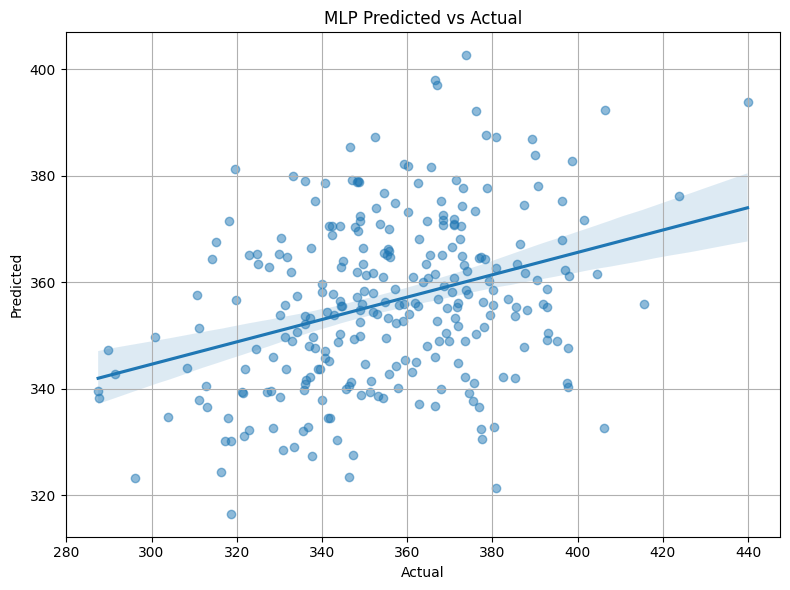

In [68]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

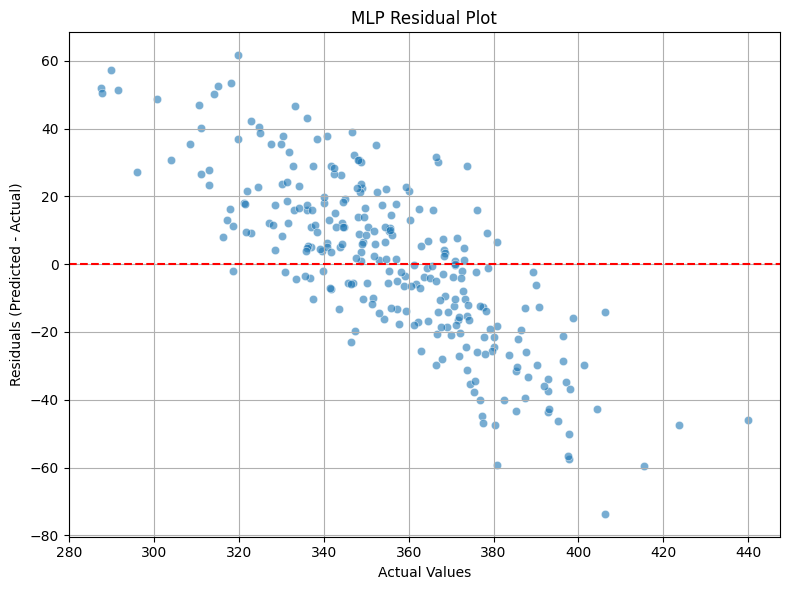

In [69]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [94]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 25133 entries, Chr1_17750 to PRT
dtypes: float64(4), int64(25129)
memory usage: 209.8+ MB


In [95]:
gwas_snps = gwas_data.iloc[:, 0:25123]
gwas_snps.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_51886171,Chr20_51888913,Chr20_51888995,Chr20_51890470,Chr20_51977670,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52241655,Chr20_52270629
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
s100,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
s101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s1014,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
s1014,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0


In [96]:
gwas_snps_dupe = gwas_data.iloc[:, 0:25123]
gwas_snps_dupe.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_51886171,Chr20_51888913,Chr20_51888995,Chr20_51890470,Chr20_51977670,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52241655,Chr20_52270629
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
s100,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
s101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s1014,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
s1014,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0


In [97]:
gwas_y = gwas_data.iloc[:, 25132:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


In [98]:
X_tensor = torch.tensor(gwas_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [99]:
print(X_tensor.shape)

torch.Size([1094, 25123])


In [100]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [101]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 13:39:43,319] A new study created in memory with name: no-name-9c16fbf5-02f0-4d8b-b1ee-c61387773f6f
[I 2025-05-27 13:39:45,860] Trial 0 finished with value: 126068.421875 and parameters: {'hidden_size1': 200, 'dropout1': 0.012693152896952166, 'lr': 0.0002209354917266291, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.004402876983470105, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.09200798927824043}. Best is trial 0 with value: 126068.421875.
[I 2025-05-27 13:39:46,379] Trial 1 finished with value: 536.0631103515625 and parameters: {'hidden_size1': 100, 'dropout1': 0.014210164749654572, 'lr': 0.0005557970138222173, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.0008196273433375971, 'n_layers': 1}. Best is trial 1 with value: 536.0631103515625.


Early stopping at epoch 39


[I 2025-05-27 13:39:50,855] Trial 2 finished with value: 126198.8828125 and parameters: {'hidden_size1': 300, 'dropout1': 0.0839159711453239, 'lr': 0.00010028930959989685, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0007810397307757105, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.05183897643779052}. Best is trial 1 with value: 536.0631103515625.
[I 2025-05-27 13:39:52,824] Trial 3 finished with value: 1280.4620361328125 and parameters: {'hidden_size1': 100, 'dropout1': 0.03361282184265668, 'lr': 0.0025754586101222085, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.00896298869862789, 'n_layers': 1}. Best is trial 1 with value: 536.0631103515625.
[I 2025-05-27 13:39:53,494] Trial 4 finished with value: 479.9217834472656 and parameters: {'hidden_size1': 100, 'dropout1': 0.023955055173497018, 'lr': 0.0002135741982971729, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 3.76882090463902e-05, 'n_layers': 1}. Best is trial 4 with value: 

Early stopping at epoch 32


[I 2025-05-27 13:39:54,266] Trial 5 finished with value: 746.4579467773438 and parameters: {'hidden_size1': 300, 'dropout1': 0.012700822781962454, 'lr': 0.002248865011301851, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 6.669284176461165e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.0630195175221838}. Best is trial 4 with value: 479.9217834472656.


...

Early stopping at epoch 25


[I 2025-05-27 13:40:37,237] Trial 47 finished with value: 125755.5703125 and parameters: {'hidden_size1': 100, 'dropout1': 0.078754850556715, 'lr': 0.00012454645309257885, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.0034515727625921665, 'n_layers': 1}. Best is trial 34 with value: 403.6256103515625.
[I 2025-05-27 13:40:37,884] Trial 48 finished with value: 450.5848083496094 and parameters: {'hidden_size1': 100, 'dropout1': 0.018306166881547667, 'lr': 0.0003432464832662043, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.00040442980009937937, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 34 with value: 403.6256103515625.


Early stopping at epoch 27


[I 2025-05-27 13:40:38,586] Trial 49 finished with value: 2562.25390625 and parameters: {'hidden_size1': 200, 'dropout1': 0.01980625735863628, 'lr': 0.0007437392564919468, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0006237537894603987, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout2': 0.08185088020646608}. Best is trial 34 with value: 403.6256103515625.


Early stopping at epoch 25
Best hyperparameters: {'hidden_size1': 100, 'dropout1': 0.07953865318499123, 'lr': 0.00016531464822223079, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.004363646786990498, 'n_layers': 2, 'hidden_size2': 50}


In [102]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top10_best_model_onlysnps_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 46 for fold 1
Fold 1 validation loss: 396.5020
Training fold 2
Early stopping at epoch 32 for fold 2
Fold 2 validation loss: 475.5646
Training fold 3
Early stopping at epoch 45 for fold 3
Fold 3 validation loss: 353.8775
Training fold 4
Early stopping at epoch 49 for fold 4
Fold 4 validation loss: 426.5766
Training fold 5
Early stopping at epoch 43 for fold 5
Fold 5 validation loss: 417.2913
Training fold 6
Early stopping at epoch 37 for fold 6
Fold 6 validation loss: 422.1827
Training fold 7
Early stopping at epoch 68 for fold 7
Fold 7 validation loss: 488.5795
Training fold 8
Early stopping at epoch 52 for fold 8
Fold 8 validation loss: 507.5472
Training fold 9
Early stopping at epoch 36 for fold 9
Fold 9 validation loss: 386.6287
Training fold 10
Early stopping at epoch 64 for fold 10
Fold 10 validation loss: 395.4375

Average validation loss across all folds: 427.0188
Checkpoint saved as 'gwas_top10_best_model_onlysnps_mlp_prt.pth'.


In [103]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [104]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [105]:
# Ensure both training and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [106]:
X_holdout.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_51886171,Chr20_51888913,Chr20_51888995,Chr20_51890470,Chr20_51977670,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52241655,Chr20_52270629
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s102,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s110,0,0,0,0,1,0,0,0,0,0,...,0,0,2,0,2,0,0,0,1,0
s112,0,0,0,0,0,0,1,2,0,0,...,0,0,0,0,2,2,0,0,0,0
s113,0,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0


In [107]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [108]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 667.2527
RMSE: 25.8312
MAE: 20.4977
R2: -0.0622
Holdout_Loss: 667.2527


In [109]:
pickle.dump(best_mlp_model, open("gwas_top10_best_model_onlysnps_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 365.8216
1 344.136 366.7045
2 351.481 334.82425
3 353.611 366.3734
4 390.342 353.791
5 358.958 345.23633


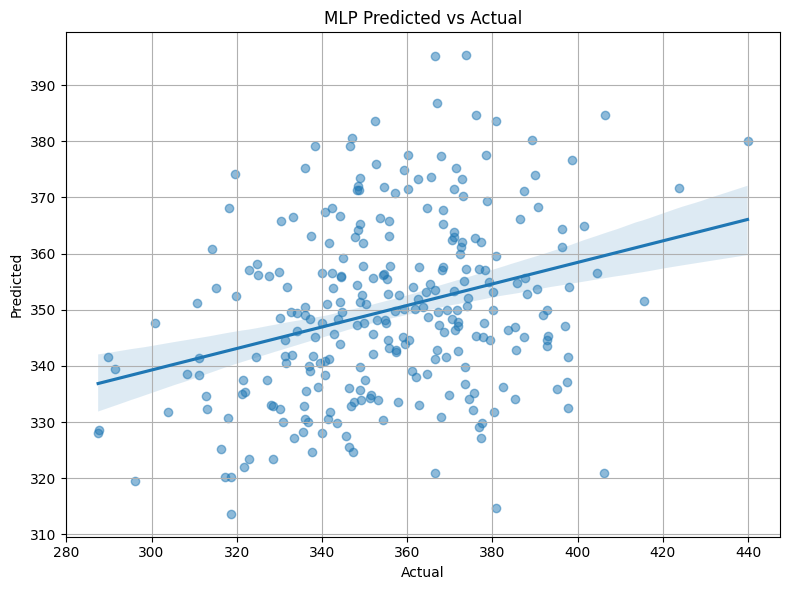

In [110]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

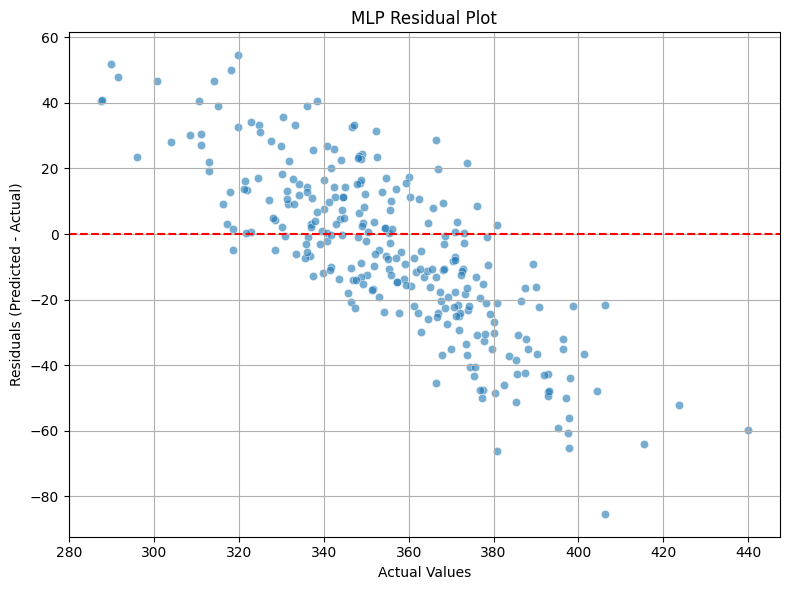

In [111]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

# LASSO regression 

In [251]:
fs_data = pd.read_pickle("pickle_files/fs_prt_lasso_training_data_new.pkl")

In [252]:
fs_data.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,0,0,0,0,0,0,2,0,2,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,2,0,0,0,0,0,0,2,0,2,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014,0,0,0,0,0,0,0,0,0,2,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,0,0,0,0,0,0,0,2,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101,2,0,2,2,0,2,0,2,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


### All features

In [253]:
X_all = fs_data.drop("PRT", axis=1).values
y_all = fs_data["PRT"].values

In [254]:
X_dupe = fs_data.drop("PRT", axis=1)
X_dupe.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,Chr20_50084112,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,0,0,0,0,0,0,2,0,2,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,2,0,0,0,0,0,0,2,0,2,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,2,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,2,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1
s101,2,0,2,2,0,2,0,2,0,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1


In [255]:
X_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [256]:
print(X_tensor.shape)

torch.Size([1094, 299])


In [257]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [258]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 14:09:06,655] A new study created in memory with name: no-name-86468900-5851-4cd6-ad2f-c7163eb28555
[I 2025-05-27 14:09:08,797] Trial 0 finished with value: 49625.38671875 and parameters: {'hidden_size1': 100, 'dropout1': 0.06552446959565558, 'lr': 0.0008819059944601594, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.00010517164286567692, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 49625.38671875.
[I 2025-05-27 14:09:10,276] Trial 1 finished with value: 117193.2578125 and parameters: {'hidden_size1': 100, 'dropout1': 0.09208300658098814, 'lr': 0.0007209827908572378, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.003461395453479584, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout2': 0.050218958784102666}. Best is trial 0 with value: 49625.38671875.
[I 2025-05-27 14:09:10,970] Trial 2 finished with value: 558.871337890625 and parameters: {'hidden_size1': 300, 'dropout1': 0.06486074745011636, 'lr': 0.001018285119497985

Early stopping at epoch 43


[I 2025-05-27 14:09:11,263] Trial 3 finished with value: 1007.182373046875 and parameters: {'hidden_size1': 300, 'dropout1': 0.045437580069898405, 'lr': 0.002063974487141258, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.0006342994429672891, 'n_layers': 1}. Best is trial 2 with value: 558.871337890625.


Early stopping at epoch 24


[I 2025-05-27 14:09:13,715] Trial 4 finished with value: 19281.994140625 and parameters: {'hidden_size1': 200, 'dropout1': 0.02144811063393844, 'lr': 0.0012117190116830794, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 2.812240807403694e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout2': 0.04500351723764531}. Best is trial 2 with value: 558.871337890625.
[I 2025-05-27 14:09:15,795] Trial 5 finished with value: 514.36962890625 and parameters: {'hidden_size1': 200, 'dropout1': 0.026662764808430765, 'lr': 0.00014369503209094448, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 1.1723204848469961e-05, 'n_layers': 1}. Best is trial 5 with value: 514.36962890625.
[I 2025-05-27 14:09:20,076] Trial 6 finished with value: 4681.77783203125 and parameters: {'hidden_size1': 200, 'dropout1': 0.062077759447865304, 'lr': 0.0026790261600050853, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0014428386799160743, 'n_layers': 3, 'hidden_size2': 100, 'hidden_siz

...

Early stopping at epoch 46


[I 2025-05-27 14:10:42,970] Trial 47 finished with value: 111362.2265625 and parameters: {'hidden_size1': 200, 'dropout1': 0.010239527863491138, 'lr': 0.00012968119162059093, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 2.0780354107406345e-05, 'n_layers': 1}. Best is trial 24 with value: 501.0991516113281.
[I 2025-05-27 14:10:43,909] Trial 48 finished with value: 528.5571899414062 and parameters: {'hidden_size1': 200, 'dropout1': 0.03629834890403942, 'lr': 0.0007120589841760802, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 7.7830203938357e-05, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 24 with value: 501.0991516113281.


Early stopping at epoch 24


[I 2025-05-27 14:10:45,193] Trial 49 finished with value: 2855.978759765625 and parameters: {'hidden_size1': 200, 'dropout1': 0.0223569137113205, 'lr': 0.00010300243643619747, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.00010598957029012695, 'n_layers': 1}. Best is trial 24 with value: 501.0991516113281.


Best hyperparameters: {'hidden_size1': 200, 'dropout1': 0.017660040079866365, 'lr': 0.0003956406134172189, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 7.612649413005442e-05, 'n_layers': 1}


In [259]:
#Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='lasso_allfeats_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 31 for fold 1
Fold 1 validation loss: 513.3802
Training fold 2
Early stopping at epoch 67 for fold 2
Fold 2 validation loss: 712.6016
Training fold 3
Early stopping at epoch 40 for fold 3
Fold 3 validation loss: 549.5947
Training fold 4
Early stopping at epoch 39 for fold 4
Fold 4 validation loss: 502.0591
Training fold 5
Early stopping at epoch 77 for fold 5
Fold 5 validation loss: 481.1102
Training fold 6
Early stopping at epoch 52 for fold 6
Fold 6 validation loss: 672.5797
Training fold 7
Early stopping at epoch 59 for fold 7
Fold 7 validation loss: 662.2378
Training fold 8
Early stopping at epoch 48 for fold 8
Fold 8 validation loss: 527.6732
Training fold 9
Early stopping at epoch 57 for fold 9
Fold 9 validation loss: 627.0901
Training fold 10
Early stopping at epoch 37 for fold 10
Fold 10 validation loss: 582.0300

Average validation loss across all folds: 583.0357
Checkpoint saved as 'lasso_allfeats_mlp_prt.pth'.


In [260]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [261]:
holdout_data = holdout_data.set_index('Line')

In [262]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [263]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [264]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [265]:
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [266]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 299 entries, Chr1_1046903 to landrace
dtypes: float64(3), int64(296)
memory usage: 642.2+ KB


In [267]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [268]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 897.2782
RMSE: 29.9546
MAE: 24.2219
R2: -0.4283
Holdout_Loss: 897.2781


In [269]:
pickle.dump(best_mlp_model, open("lasso_allfeats_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 399.3947
1 344.136 385.64346
2 351.481 352.28503
3 353.611 363.7749
4 390.342 314.50864
5 358.958 391.77658


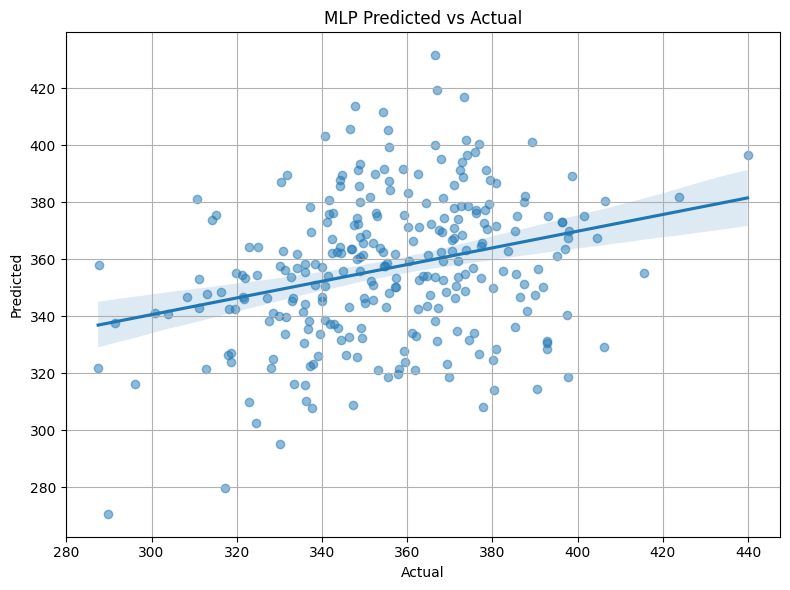

In [270]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

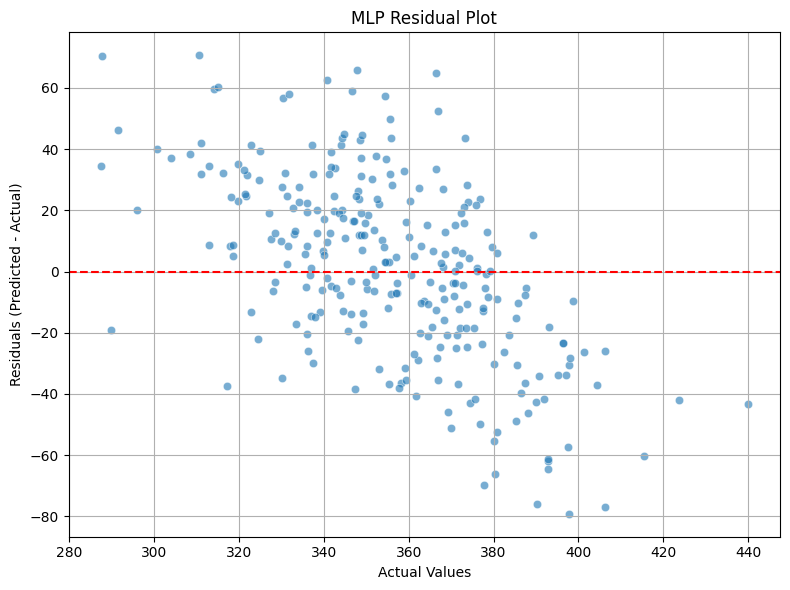

In [271]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [272]:
snps_loc= fs_data.drop(['BBD', 'LL', 'LW', 'PLH', 'PRT'], axis=1)
snps_loc.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,Chr20_40346647,Chr20_40962479,Chr20_45033350,Chr20_48338919,Chr20_50084112,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,0,0,0,0,0,0,2,0,2,...,1,0,0,0,0,1,0,0,0,1
s100,2,0,0,0,0,0,0,2,0,2,...,1,0,0,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,2,...,0,2,2,0,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,2,...,0,2,2,0,0,0,1,0,0,1
s101,2,0,2,2,0,2,0,2,0,0,...,1,0,0,2,0,0,0,1,0,1


In [273]:
snps_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 295 entries, Chr1_1046903 to landrace
dtypes: int64(295)
memory usage: 2.5+ MB


In [274]:
snps_loc_dupe= fs_data.drop(['BBD', 'LL',	'LW',	'PLH', 'PRT'], axis=1)
snps_loc_dupe.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,Chr20_40346647,Chr20_40962479,Chr20_45033350,Chr20_48338919,Chr20_50084112,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,0,0,0,0,0,0,2,0,2,...,1,0,0,0,0,1,0,0,0,1
s100,2,0,0,0,0,0,0,2,0,2,...,1,0,0,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,2,...,0,2,2,0,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,2,...,0,2,2,0,0,0,1,0,0,1
s101,2,0,2,2,0,2,0,2,0,0,...,1,0,0,2,0,0,0,1,0,1


In [275]:
y_all = fs_data["PRT"].values

In [276]:
X_tensor = torch.tensor(snps_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [277]:
print(X_tensor.shape)

torch.Size([1094, 295])


In [278]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [279]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 14:12:32,984] A new study created in memory with name: no-name-603be1c8-8de7-499a-afaa-7e3fadcd3aba
[I 2025-05-27 14:12:33,415] Trial 0 finished with value: 2491.91552734375 and parameters: {'hidden_size1': 200, 'dropout1': 0.08429396653631534, 'lr': 0.005535881928658638, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.00017321564057846644, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 2491.91552734375.


Early stopping at epoch 11


[I 2025-05-27 14:12:34,838] Trial 1 finished with value: 553.4691772460938 and parameters: {'hidden_size1': 200, 'dropout1': 0.09636226306722823, 'lr': 0.00016838298423884604, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 1.4051894497336003e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 1 with value: 553.4691772460938.


Early stopping at epoch 100


[I 2025-05-27 14:12:35,510] Trial 2 finished with value: 1036.1566162109375 and parameters: {'hidden_size1': 200, 'dropout1': 0.06062976260458157, 'lr': 0.002828634670770462, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.008942214736017274, 'n_layers': 1}. Best is trial 1 with value: 553.4691772460938.


...

Early stopping at epoch 55


[I 2025-05-27 14:13:45,263] Trial 47 finished with value: 560.780517578125 and parameters: {'hidden_size1': 300, 'dropout1': 0.08635557651432892, 'lr': 0.0002264767290684391, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.0012277352018998308, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 42 with value: 539.2695922851562.


Early stopping at epoch 41


[I 2025-05-27 14:13:48,971] Trial 48 finished with value: 121941.9296875 and parameters: {'hidden_size1': 300, 'dropout1': 0.09934781799783365, 'lr': 0.0003156211983431724, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.00975775014385072, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 42 with value: 539.2695922851562.
[I 2025-05-27 14:13:50,830] Trial 49 finished with value: 601.5526733398438 and parameters: {'hidden_size1': 300, 'dropout1': 0.08159691700579856, 'lr': 0.00012512913877847856, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.002481066329528319, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.01222851622283562}. Best is trial 42 with value: 539.2695922851562.


Early stopping at epoch 41
Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.08594602951957608, 'lr': 0.00016599358410106233, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.009983548106783034, 'n_layers': 2, 'hidden_size2': 150}


In [280]:
best_params = complete_params(study.best_params)

In [281]:
#def cross_validate(X, y, best_params, n_splits, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='lasso_onlyloc_mlp_PRT.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 28 for fold 1
Fold 1 validation loss: 542.6594
Training fold 2
Early stopping at epoch 76 for fold 2
Fold 2 validation loss: 704.2744
Training fold 3
Early stopping at epoch 39 for fold 3
Fold 3 validation loss: 561.1005
Training fold 4
Early stopping at epoch 67 for fold 4
Fold 4 validation loss: 552.5631
Training fold 5
Early stopping at epoch 44 for fold 5
Fold 5 validation loss: 593.1708
Training fold 6
Early stopping at epoch 60 for fold 6
Fold 6 validation loss: 732.8994
Training fold 7
Early stopping at epoch 61 for fold 7
Fold 7 validation loss: 715.4521
Training fold 8
Early stopping at epoch 48 for fold 8
Fold 8 validation loss: 543.9459
Training fold 9
Early stopping at epoch 72 for fold 9
Fold 9 validation loss: 657.3617
Training fold 10
Early stopping at epoch 43 for fold 10
Fold 10 validation loss: 704.2436

Average validation loss across all folds: 630.7671
Checkpoint saved as 'lasso_onlyloc_mlp_PRT.pth'.


In [282]:
best_mlp_model

Sequential(
  (0): Linear(in_features=295, out_features=300, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.08594602951957608, inplace=False)
  (3): Linear(in_features=300, out_features=150, bias=True)
  (4): ReLU()
  (5): Linear(in_features=150, out_features=1, bias=True)
)

In [283]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [284]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [285]:
# Ensure both trainjg and holdout datasets have the same columns
snps_loc_dupe, X_holdout = snps_loc_dupe.align(X_holdout, join='inner', axis=1)

In [286]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 295 entries, Chr1_1046903 to landrace
dtypes: int64(295)
memory usage: 633.6+ KB


In [287]:
X_holdout.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,Chr20_40346647,Chr20_40962479,Chr20_45033350,Chr20_48338919,Chr20_50084112,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,2,0,2,2,0,2,0,2,0,0,...,1,0,0,2,0,1,0,0,0,1
s102,2,0,0,2,2,0,0,2,0,0,...,2,0,0,0,0,0,0,1,0,1
s110,0,0,0,0,0,0,2,2,0,2,...,2,2,0,0,0,1,0,0,0,1
s112,2,2,0,0,0,1,2,2,1,1,...,1,2,2,0,2,1,0,0,0,1
s113,0,0,0,0,0,0,0,2,0,2,...,0,2,0,0,2,1,0,0,0,1


In [288]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [289]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 952.3781
RMSE: 30.8606
MAE: 24.6594
R2: -0.5160
Holdout_Loss: 952.3782


In [290]:
pickle.dump(best_mlp_model, open("lasso_onlyloc_mlp_PRT.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 392.467
1 344.136 406.95795
2 351.481 348.7421
3 353.611 349.08752
4 390.342 313.26807
5 358.958 357.13046


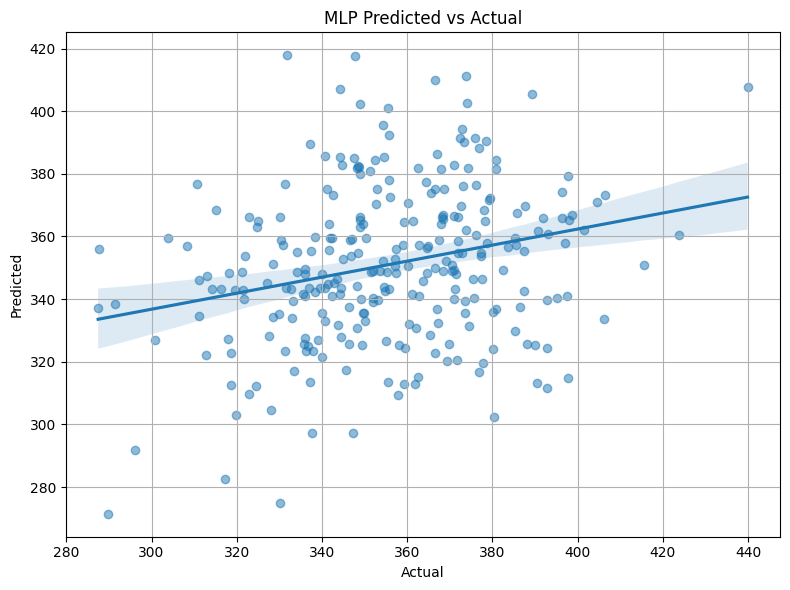

In [291]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

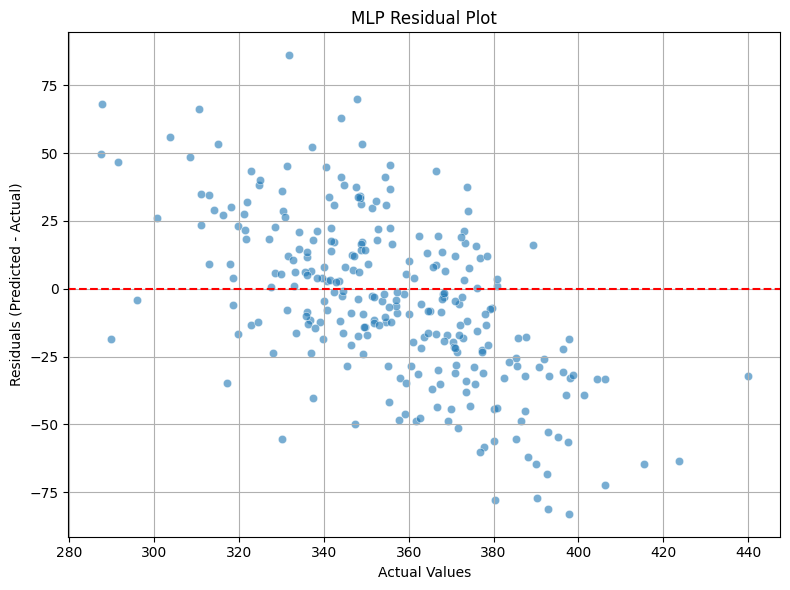

In [292]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [293]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 300 entries, Chr1_1046903 to PRT
dtypes: float64(4), int64(296)
memory usage: 2.5+ MB


In [294]:
only_snps = fs_data.iloc[:, 0:290]
only_snps.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,Chr20_2406752,Chr20_3272852,Chr20_4691294,Chr20_15867030,Chr20_23836589,Chr20_40346647,Chr20_40962479,Chr20_45033350,Chr20_48338919,Chr20_50084112
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,0,0,0,0,0,0,2,0,2,...,2,0,1,0,0,1,0,0,0,0
s100,2,0,0,0,0,0,0,2,0,2,...,2,0,1,0,0,1,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,2,2,0,0
s1014,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,2,2,0,0
s101,2,0,2,2,0,2,0,2,0,0,...,2,0,0,1,0,1,0,0,2,0


In [295]:
only_snps_dupe = fs_data.iloc[:, 0:290]
only_snps_dupe.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,Chr20_2406752,Chr20_3272852,Chr20_4691294,Chr20_15867030,Chr20_23836589,Chr20_40346647,Chr20_40962479,Chr20_45033350,Chr20_48338919,Chr20_50084112
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,0,0,0,0,0,0,2,0,2,...,2,0,1,0,0,1,0,0,0,0
s100,2,0,0,0,0,0,0,2,0,2,...,2,0,1,0,0,1,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,2,2,0,0
s1014,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,2,2,0,0
s101,2,0,2,2,0,2,0,2,0,0,...,2,0,0,1,0,1,0,0,2,0


In [296]:
y_all = fs_data["PRT"]
y_all.head()

Line
s100     340.553
s100     358.104
s1014    366.116
s1014    326.667
s101     385.915
Name: PRT, dtype: float64

In [297]:
# Convert to tensor and move to GPU if available
X_tensor = torch.tensor(only_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [298]:
print(X_tensor.shape)

torch.Size([1094, 290])


In [299]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [300]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 14:15:34,576] A new study created in memory with name: no-name-2aacb886-7150-43eb-baf5-09a9aa4b70df
[I 2025-05-27 14:15:37,100] Trial 0 finished with value: 581.287353515625 and parameters: {'hidden_size1': 200, 'dropout1': 0.06127383305106602, 'lr': 0.00013518296135958514, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.0005122828648816758, 'n_layers': 1}. Best is trial 0 with value: 581.287353515625.


Early stopping at epoch 75


[I 2025-05-27 14:15:38,979] Trial 1 finished with value: 40470.71484375 and parameters: {'hidden_size1': 300, 'dropout1': 0.06632681586336306, 'lr': 0.0028313258163514027, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0007138235990513288, 'n_layers': 1}. Best is trial 0 with value: 581.287353515625.
[I 2025-05-27 14:15:39,392] Trial 2 finished with value: 665.0894165039062 and parameters: {'hidden_size1': 200, 'dropout1': 0.06414755321668203, 'lr': 0.002118550851011454, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 3.726006529524947e-05, 'n_layers': 1}. Best is trial 0 with value: 581.287353515625.


Early stopping at epoch 21


[I 2025-05-27 14:15:39,739] Trial 3 finished with value: 643.489990234375 and parameters: {'hidden_size1': 300, 'dropout1': 0.013751119731192784, 'lr': 0.004133922263147979, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0032886427066598314, 'n_layers': 1}. Best is trial 0 with value: 581.287353515625.


...

Early stopping at epoch 64


[I 2025-05-27 14:16:42,896] Trial 33 finished with value: 590.7257690429688 and parameters: {'hidden_size1': 200, 'dropout1': 0.020205951624519023, 'lr': 0.0035832459403823875, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 2.623498582283588e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 30 with value: 557.7969360351562.
[I 2025-05-27 14:16:46,594] Trial 34 finished with value: 715.1066284179688 and parameters: {'hidden_size1': 200, 'dropout1': 0.06778777302153231, 'lr': 0.002407617139012601, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 1.5223358618286457e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 30 with value: 557.7969360351562.
[I 2025-05-27 14:16:48,742] Trial 35 finished with value: 568.3594360351562 and parameters: {'hidden_size1': 200, 'dropout1': 0.06283653478375537, 'lr': 0.00710662033954069, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 3.5039476167313825e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 30 with value: 557.7

Early stopping at epoch 65


[I 2025-05-27 14:17:13,470] Trial 46 finished with value: 699.7142944335938 and parameters: {'hidden_size1': 100, 'dropout1': 0.07676218226515519, 'lr': 0.004081762662527226, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 4.610170330283403e-05, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout2': 0.024419914100386644}. Best is trial 45 with value: 553.6976928710938.
[I 2025-05-27 14:17:15,939] Trial 47 finished with value: 599.275634765625 and parameters: {'hidden_size1': 200, 'dropout1': 0.09979124673362225, 'lr': 0.007870152573690174, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 2.332884859154211e-05, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout2': 0.04719217142038962}. Best is trial 45 with value: 553.6976928710938.
[I 2025-05-27 14:17:18,402] Trial 48 finished with value: 588.6312866210938 and parameters: {'hidden_size1': 100, 'dropout1': 0.09368539726217331, 'lr': 0.009990488614590313, 'batch_size': 64, 'optimizer': 'SGD', 'weight_d

Early stopping at epoch 35
Best hyperparameters: {'hidden_size1': 200, 'dropout1': 0.07942094435951885, 'lr': 0.009861815188547025, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 4.9130994097814604e-05, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout2': 0.029481359021167407}


In [302]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, best_params, n_splits, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='lasso_onlysnps_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 19 for fold 1
Fold 1 validation loss: 586.7322
Training fold 2
Early stopping at epoch 41 for fold 2
Fold 2 validation loss: 702.6755
Training fold 3
Early stopping at epoch 32 for fold 3
Fold 3 validation loss: 561.5522
Training fold 4
Early stopping at epoch 41 for fold 4
Fold 4 validation loss: 548.8849
Training fold 5
Early stopping at epoch 39 for fold 5
Fold 5 validation loss: 588.0169
Training fold 6
Early stopping at epoch 40 for fold 6
Fold 6 validation loss: 754.8233
Training fold 7
Early stopping at epoch 36 for fold 7
Fold 7 validation loss: 722.2288
Training fold 8
Early stopping at epoch 23 for fold 8
Fold 8 validation loss: 555.3795
Training fold 9
Early stopping at epoch 51 for fold 9
Fold 9 validation loss: 665.6098
Training fold 10
Early stopping at epoch 21 for fold 10
Fold 10 validation loss: 700.9455

Average validation loss across all folds: 638.6849
Checkpoint saved as 'lasso_onlysnps_mlp_prt.pth'.


In [303]:
best_mlp_model

Sequential(
  (0): Linear(in_features=290, out_features=200, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.07942094435951885, inplace=False)
  (3): Linear(in_features=200, out_features=50, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.029481359021167407, inplace=False)
  (6): Linear(in_features=50, out_features=25, bias=True)
  (7): ReLU()
  (8): Linear(in_features=25, out_features=1, bias=True)
)

In [304]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [305]:
holdout_data = holdout_data.set_index('Line')

In [306]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [307]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [308]:
# Ensure both trainjg and holdout datasets have the same columns
only_snps_dupe, X_holdout = only_snps_dupe.align(X_holdout, join='inner', axis=1)

In [309]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 290 entries, Chr1_1046903 to Chr20_50084112
dtypes: int64(290)
memory usage: 622.9+ KB


In [310]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [311]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 903.6183
RMSE: 30.0602
MAE: 24.0629
R2: -0.4384
Holdout_Loss: 903.6184


In [440]:
pickle.dump(best_mlp_model, open("lasso_onlysnps_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

# ElasticNet

In [196]:
fs_data = pd.read_pickle("pickle_files/fs_prt_enet_training_data.pkl")

In [197]:
fs_data.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,2,0,0,0,0,2,2,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,0,2,0,0,0,0,2,2,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014,0,0,0,0,0,0,0,0,2,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,0,0,0,0,0,0,2,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101,2,0,2,0,0,2,2,2,0,2,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


### All covariates

In [198]:
X_all = fs_data.drop("PRT", axis=1).values
y_all = fs_data["PRT"].values

In [199]:
X_dupe = fs_data.drop("PRT", axis=1)
X_dupe.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,Chr20_50084112,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,2,0,0,0,0,2,2,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,0,2,0,0,0,0,2,2,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,2,0,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,2,0,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1
s101,2,0,2,0,0,2,2,2,0,2,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1


In [200]:
X_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [201]:
print(X_tensor.shape)

torch.Size([1094, 773])


In [202]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [203]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 13:57:40,019] A new study created in memory with name: no-name-3b8a3ad0-7774-40ce-9d6d-78d80cda6a7d
[I 2025-05-27 13:57:41,243] Trial 0 finished with value: 388.9693908691406 and parameters: {'hidden_size1': 200, 'dropout1': 0.09255379074267348, 'lr': 0.000149123373606866, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 1.5060482408957094e-05, 'n_layers': 1}. Best is trial 0 with value: 388.9693908691406.
[I 2025-05-27 13:57:42,063] Trial 1 finished with value: 597.3449096679688 and parameters: {'hidden_size1': 200, 'dropout1': 0.04874828784722204, 'lr': 0.0021063771485152266, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 7.082500034537932e-05, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout2': 0.034059321104886374}. Best is trial 0 with value: 388.9693908691406.


Early stopping at epoch 30


[I 2025-05-27 13:57:42,844] Trial 2 finished with value: 412.61505126953125 and parameters: {'hidden_size1': 200, 'dropout1': 0.01575510343764675, 'lr': 0.00030869024386208073, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.00037275700026948326, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 388.9693908691406.


Early stopping at epoch 35


[I 2025-05-27 13:57:45,300] Trial 3 finished with value: 126651.5 and parameters: {'hidden_size1': 100, 'dropout1': 0.030792376300102932, 'lr': 0.00011992062563350487, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.008384924814875275, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout2': 0.07094446593281012}. Best is trial 0 with value: 388.9693908691406.
[I 2025-05-27 13:57:48,989] Trial 4 finished with value: 438.6582946777344 and parameters: {'hidden_size1': 200, 'dropout1': 0.01157851322601804, 'lr': 0.009727585399172053, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 5.192770950475533e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 388.9693908691406.
[I 2025-05-27 13:57:51,120] Trial 5 finished with value: 2276.499267578125 and parameters: {'hidden_size1': 100, 'dropout1': 0.019234991638804093, 'lr': 0.0040740571538282234, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0016840563345021516, 'n_layers': 2, 'hidden_size2': 

...

Early stopping at epoch 87


[I 2025-05-27 13:58:41,093] Trial 47 finished with value: 373.5482482910156 and parameters: {'hidden_size1': 100, 'dropout1': 0.06110160159726082, 'lr': 0.00017478004597347465, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0010102744386155625, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 20 with value: 354.3554992675781.


Early stopping at epoch 65


[I 2025-05-27 13:58:42,414] Trial 48 finished with value: 125711.71875 and parameters: {'hidden_size1': 100, 'dropout1': 0.05171959558723063, 'lr': 0.00025449594693548357, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.0005760238521123078, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 20 with value: 354.3554992675781.
[I 2025-05-27 13:58:42,831] Trial 49 finished with value: 461.05340576171875 and parameters: {'hidden_size1': 100, 'dropout1': 0.05556494902256799, 'lr': 0.00994598941259238, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.001426418823332972, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 20 with value: 354.3554992675781.


Early stopping at epoch 28
Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.09920085414353935, 'lr': 0.00010416467040783699, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0008230450007137847, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.0608625002739943}


In [204]:
#Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='enet_allfeats_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 44 for fold 1
Fold 1 validation loss: 360.8716
Training fold 2
Early stopping at epoch 63 for fold 2
Fold 2 validation loss: 431.6763
Training fold 3
Early stopping at epoch 69 for fold 3
Fold 3 validation loss: 391.0941
Training fold 4
Early stopping at epoch 53 for fold 4
Fold 4 validation loss: 346.7069
Training fold 5
Early stopping at epoch 52 for fold 5
Fold 5 validation loss: 368.8660
Training fold 6
Early stopping at epoch 65 for fold 6
Fold 6 validation loss: 375.7026
Training fold 7
Early stopping at epoch 59 for fold 7
Fold 7 validation loss: 399.1535
Training fold 8
Early stopping at epoch 38 for fold 8
Fold 8 validation loss: 345.3289
Training fold 9
Early stopping at epoch 44 for fold 9
Fold 9 validation loss: 404.6339
Training fold 10
Early stopping at epoch 57 for fold 10
Fold 10 validation loss: 337.1259

Average validation loss across all folds: 376.1160
Checkpoint saved as 'enet_allfeats_mlp_prt.pth'.


In [205]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [206]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [207]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [208]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [209]:
# Ensure both trainjg and holdout datasets have the same columns
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [210]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 773 entries, Chr1_371931 to landrace
dtypes: float64(3), int64(770)
memory usage: 1.6+ MB


In [211]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [212]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 786.2521
RMSE: 28.0402
MAE: 22.3499
R2: -0.2516
Holdout_Loss: 786.2521


In [213]:
pickle.dump(best_mlp_model, open("enet_allfeats_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 392.45123
1 344.136 364.67477
2 351.481 349.37988
3 353.611 354.94794
4 390.342 354.15326
5 358.958 382.71286


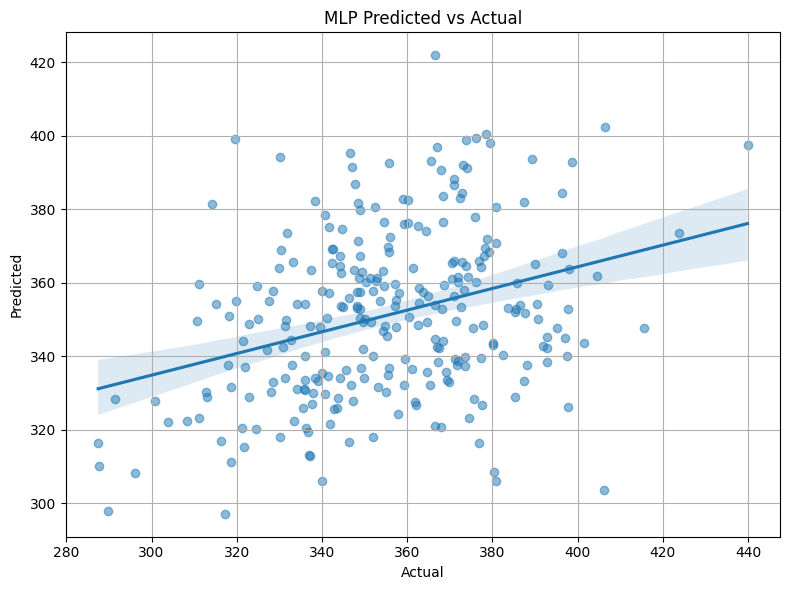

In [214]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

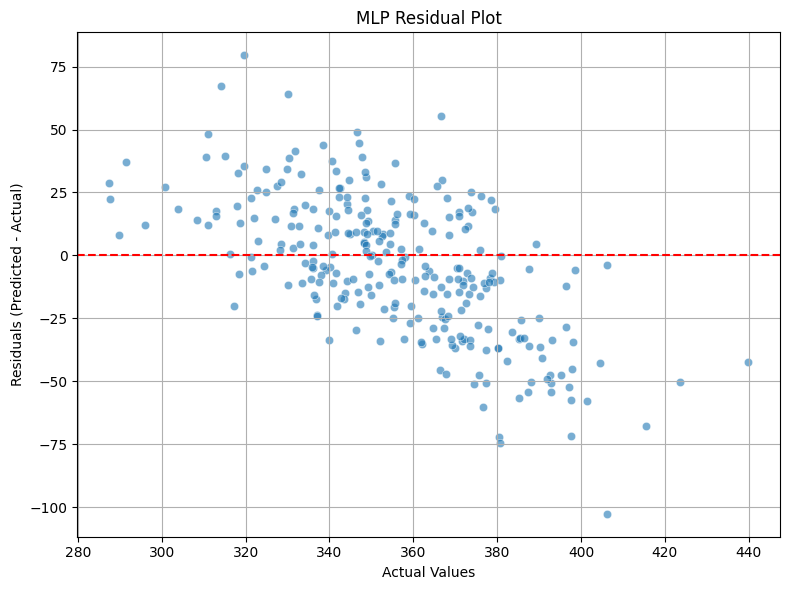

In [215]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [216]:
snps_loc= fs_data.drop(['BBD', 'LL', 'LW', 'PLH', 'PRT'], axis=1)
snps_loc.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,Chr20_45033350,Chr20_48338919,Chr20_48582557,Chr20_48641652,Chr20_50084112,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,2,0,0,0,0,2,2,0,...,0,0,0,2,0,1,0,0,0,1
s100,0,0,2,0,0,0,0,2,2,0,...,0,0,0,2,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,2,0,...,2,0,0,0,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,2,0,...,2,0,0,0,0,0,1,0,0,1
s101,2,0,2,0,0,2,2,2,0,2,...,0,2,0,0,0,0,0,1,0,1


In [217]:
snps_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 769 entries, Chr1_371931 to landrace
dtypes: int64(769)
memory usage: 6.4+ MB


In [218]:
snps_loc_dupe= fs_data.drop(['BBD', 'LL',	'LW',	'PLH', 'PRT'], axis=1)
snps_loc_dupe.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,Chr20_45033350,Chr20_48338919,Chr20_48582557,Chr20_48641652,Chr20_50084112,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,2,0,0,0,0,2,2,0,...,0,0,0,2,0,1,0,0,0,1
s100,0,0,2,0,0,0,0,2,2,0,...,0,0,0,2,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,2,0,...,2,0,0,0,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,2,0,...,2,0,0,0,0,0,1,0,0,1
s101,2,0,2,0,0,2,2,2,0,2,...,0,2,0,0,0,0,0,1,0,1


In [219]:
y_all = fs_data["PRT"].values

In [220]:
X_tensor = torch.tensor(snps_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [221]:
print(X_tensor.shape)

torch.Size([1094, 769])


In [222]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [223]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 14:00:59,077] A new study created in memory with name: no-name-b77bd952-331b-4d5c-86b2-f59eaa28182c
[I 2025-05-27 14:00:59,861] Trial 0 finished with value: 435.64544677734375 and parameters: {'hidden_size1': 200, 'dropout1': 0.019611214819137385, 'lr': 0.0007630429233949823, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 5.925115131339621e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 0 with value: 435.64544677734375.


Early stopping at epoch 21


[I 2025-05-27 14:01:01,763] Trial 1 finished with value: 401.9604797363281 and parameters: {'hidden_size1': 100, 'dropout1': 0.09964867406154501, 'lr': 0.00022898943942907806, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.00010980816869046874, 'n_layers': 1}. Best is trial 1 with value: 401.9604797363281.


Early stopping at epoch 63


[I 2025-05-27 14:01:02,807] Trial 2 finished with value: 49786.42578125 and parameters: {'hidden_size1': 200, 'dropout1': 0.03773131618540795, 'lr': 0.004162104754132774, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.0001314994038268385, 'n_layers': 1}. Best is trial 1 with value: 401.9604797363281.
[I 2025-05-27 14:01:03,190] Trial 3 finished with value: 2817.90771484375 and parameters: {'hidden_size1': 100, 'dropout1': 0.0347547822117167, 'lr': 0.0037728512911963507, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.0002691832128804666, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 1 with value: 401.9604797363281.


...

Early stopping at epoch 39


[I 2025-05-27 14:02:26,736] Trial 48 finished with value: 392.2266540527344 and parameters: {'hidden_size1': 200, 'dropout1': 0.04747416727443075, 'lr': 0.00026970734058692417, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0008724433777191577, 'n_layers': 1}. Best is trial 23 with value: 369.6043701171875.


Early stopping at epoch 56


[I 2025-05-27 14:02:27,067] Trial 49 finished with value: 2075.84326171875 and parameters: {'hidden_size1': 300, 'dropout1': 0.06250560599611699, 'lr': 0.002166607916291625, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.007536287740227388, 'n_layers': 1}. Best is trial 23 with value: 369.6043701171875.


Early stopping at epoch 26
Best hyperparameters: {'hidden_size1': 200, 'dropout1': 0.05496596646065271, 'lr': 0.00010163623279838365, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.006969185383691635, 'n_layers': 1}


In [224]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='enet_onlyloc_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 100 for fold 1
Fold 1 validation loss: 374.7616
Training fold 2
Fold 2 validation loss: 444.6284
Training fold 3
Early stopping at epoch 83 for fold 3
Fold 3 validation loss: 403.0974
Training fold 4
Fold 4 validation loss: 349.2319
Training fold 5
Fold 5 validation loss: 375.3480
Training fold 6
Fold 6 validation loss: 377.6947
Training fold 7
Fold 7 validation loss: 405.6048
Training fold 8
Early stopping at epoch 88 for fold 8
Fold 8 validation loss: 340.2301
Training fold 9
Fold 9 validation loss: 403.9275
Training fold 10
Early stopping at epoch 83 for fold 10
Fold 10 validation loss: 371.1791

Average validation loss across all folds: 384.5704
Checkpoint saved as 'enet_onlyloc_mlp_prt.pth'.


In [225]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [226]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [227]:
# Ensure both trainjg and holdout datasets have the same columns
snps_loc_dupe, X_holdout = snps_loc_dupe.align(X_holdout, join='inner', axis=1)

In [228]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 769 entries, Chr1_371931 to landrace
dtypes: int64(769)
memory usage: 1.6+ MB


In [229]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [230]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 737.4651
RMSE: 27.1563
MAE: 21.7401
R2: -0.1739
Holdout_Loss: 737.4651


In [231]:
pickle.dump(best_mlp_model, open("enet_onlyloc_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 395.2585
1 344.136 375.19995
2 351.481 355.00433
3 353.611 360.0253
4 390.342 354.8878
5 358.958 369.0603


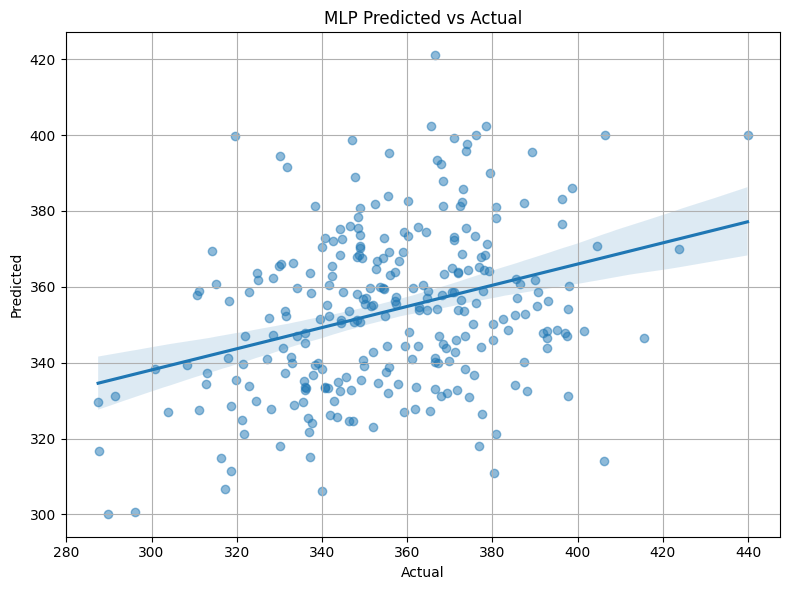

In [232]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

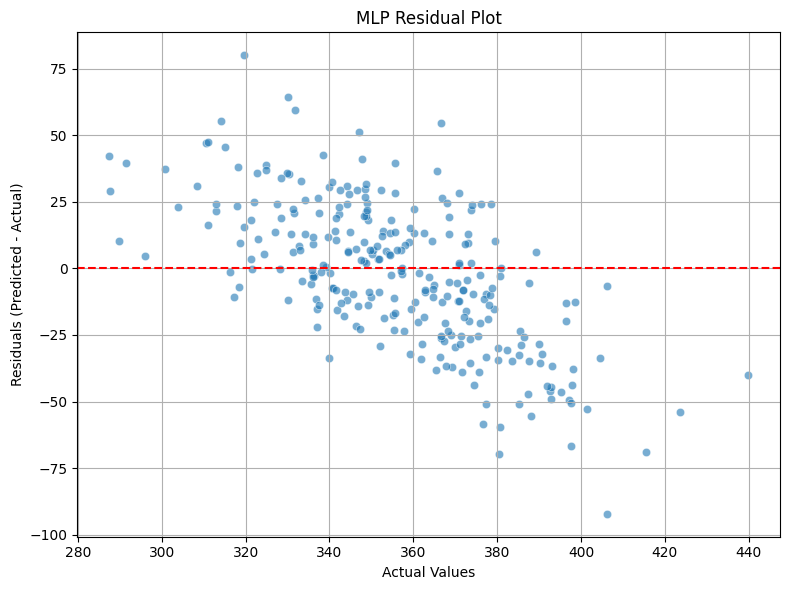

In [233]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [234]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 774 entries, Chr1_371931 to PRT
dtypes: float64(4), int64(770)
memory usage: 6.5+ MB


In [237]:
X_snps = fs_data.iloc[:, 0:764]
X_snps.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,Chr20_39346951,Chr20_40346647,Chr20_40447898,Chr20_40962479,Chr20_41298997,Chr20_45033350,Chr20_48338919,Chr20_48582557,Chr20_48641652,Chr20_50084112
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,2,0,0,0,0,2,2,0,...,0,1,0,0,2,0,0,0,2,0
s100,0,0,2,0,0,0,0,2,2,0,...,0,1,0,0,2,0,0,0,2,0
s1014,0,0,0,0,0,0,0,0,2,0,...,0,0,0,2,0,2,0,0,0,0
s1014,0,0,0,0,0,0,0,0,2,0,...,0,0,0,2,0,2,0,0,0,0
s101,2,0,2,0,0,2,2,2,0,2,...,0,1,1,0,2,0,2,0,0,0


In [238]:
X_snps_dupe = fs_data.iloc[:, 0:764]
X_snps_dupe.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,Chr20_39346951,Chr20_40346647,Chr20_40447898,Chr20_40962479,Chr20_41298997,Chr20_45033350,Chr20_48338919,Chr20_48582557,Chr20_48641652,Chr20_50084112
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,2,0,0,0,0,2,2,0,...,0,1,0,0,2,0,0,0,2,0
s100,0,0,2,0,0,0,0,2,2,0,...,0,1,0,0,2,0,0,0,2,0
s1014,0,0,0,0,0,0,0,0,2,0,...,0,0,0,2,0,2,0,0,0,0
s1014,0,0,0,0,0,0,0,0,2,0,...,0,0,0,2,0,2,0,0,0,0
s101,2,0,2,0,0,2,2,2,0,2,...,0,1,1,0,2,0,2,0,0,0


In [239]:
y_all = fs_data.iloc[:, 773:]
y_all.head()

,PRT
Line,
s100,340.553
s100,358.104
s1014,366.116
s1014,326.667
s101,385.915


In [240]:
X_tensor = torch.tensor(X_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [241]:
print(X_tensor.shape)

torch.Size([1094, 764])


In [242]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [243]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-27 14:04:50,127] A new study created in memory with name: no-name-7c188575-2ca5-4316-80b0-e57889935a66
[I 2025-05-27 14:04:51,160] Trial 0 finished with value: 498.1673278808594 and parameters: {'hidden_size1': 100, 'dropout1': 0.04764476648716322, 'lr': 0.0025548415877455965, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.00026994382493697173, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout2': 0.03014859546794566}. Best is trial 0 with value: 498.1673278808594.


Early stopping at epoch 23


[I 2025-05-27 14:04:52,469] Trial 1 finished with value: 121825.65625 and parameters: {'hidden_size1': 200, 'dropout1': 0.09980529117282397, 'lr': 0.0009605818173882961, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 4.992022713532819e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 498.1673278808594.
[I 2025-05-27 14:04:56,163] Trial 2 finished with value: 126579.0078125 and parameters: {'hidden_size1': 200, 'dropout1': 0.027179310331544568, 'lr': 0.00012267635259226005, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.00016101516774295869, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 498.1673278808594.
[I 2025-05-27 14:04:59,368] Trial 3 finished with value: 116723.046875 and parameters: {'hidden_size1': 300, 'dropout1': 0.05796374415228987, 'lr': 0.00031682047036473554, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.00045809986266757193, 'n_layers': 1}. Best is trial 0 with value: 498.1673278808594.
[I 2025-05-27 14:05:

Early stopping at epoch 62


[I 2025-05-27 14:05:03,374] Trial 6 finished with value: 559.1502685546875 and parameters: {'hidden_size1': 200, 'dropout1': 0.049508267199713026, 'lr': 0.0013458716434800416, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 4.406925069628981e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout2': 0.0692408511940335}. Best is trial 5 with value: 385.33673095703125.


...

Early stopping at epoch 87


[I 2025-05-27 14:06:03,685] Trial 48 finished with value: 391.6266784667969 and parameters: {'hidden_size1': 200, 'dropout1': 0.08320628380957241, 'lr': 0.00012499982133228917, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0024841988238177067, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 8 with value: 381.7749938964844.


Early stopping at epoch 42


[I 2025-05-27 14:06:04,378] Trial 49 finished with value: 510.28509521484375 and parameters: {'hidden_size1': 300, 'dropout1': 0.043734993860342464, 'lr': 0.00028388304845869714, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.007301843986670024, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 8 with value: 381.7749938964844.


Early stopping at epoch 50
Best hyperparameters: {'hidden_size1': 200, 'dropout1': 0.0650045806596197, 'lr': 0.00010815676201246501, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.00047927796993208594, 'n_layers': 2, 'hidden_size2': 50}


In [244]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='enet_onlysnps_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 59 for fold 1
Fold 1 validation loss: 379.6728
Training fold 2
Early stopping at epoch 58 for fold 2
Fold 2 validation loss: 448.1878
Training fold 3
Early stopping at epoch 69 for fold 3
Fold 3 validation loss: 418.4704
Training fold 4
Early stopping at epoch 63 for fold 4
Fold 4 validation loss: 357.7650
Training fold 5
Early stopping at epoch 61 for fold 5
Fold 5 validation loss: 398.9285
Training fold 6
Early stopping at epoch 61 for fold 6
Fold 6 validation loss: 371.4841
Training fold 7
Early stopping at epoch 58 for fold 7
Fold 7 validation loss: 398.4384
Training fold 8
Early stopping at epoch 61 for fold 8
Fold 8 validation loss: 340.3925
Training fold 9
Early stopping at epoch 60 for fold 9
Fold 9 validation loss: 418.6247
Training fold 10
Early stopping at epoch 67 for fold 10
Fold 10 validation loss: 343.5828

Average validation loss across all folds: 387.5547
Checkpoint saved as 'enet_onlysnps_mlp_prt.pth'.


In [245]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [246]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [247]:
# Ensure both trainjg and holdout datasets have the same columns
X_snps_dupe, X_holdout = X_snps_dupe.align(X_holdout, join='inner', axis=1)

In [248]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [249]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 792.8071
RMSE: 28.1568
MAE: 22.4621
R2: -0.2620
Holdout_Loss: 792.8071


In [250]:
pickle.dump(best_mlp_model, open("enet_onlysnps_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

# XGBoost

In [9]:
tt_data = pd.read_pickle("fs_prt_xgboost_training_data.pkl")
tt_data.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,2,0,0,0,2,0,2,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014,2,2,0,2,2,0,0,2,1,2,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,2,2,0,2,2,0,0,2,1,2,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101,0,0,0,0,0,2,2,0,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [10]:
# All covariates

In [11]:
tt_y = tt_data.iloc[:, 1009:]
tt_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s1014,366.116
s1014,326.667
s101,385.915


In [12]:
tt_all= tt_data.drop(['PRT'], axis=1)
tt_all.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr15_44305656,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,2,0,0,0,2,0,2,0,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1
s101,0,0,0,0,0,2,2,0,0,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1


In [13]:
tt_all_dupe= tt_data.drop(['PRT'], axis=1)
tt_all_dupe.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr15_44305656,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,2,0,0,0,2,0,2,0,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1
s101,0,0,0,0,0,2,2,0,0,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1


In [14]:
X_tensor = torch.tensor(tt_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(tt_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [15]:
print(X_tensor.shape)

torch.Size([1094, 1009])


In [16]:
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [17]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-29 18:58:54,971] A new study created in memory with name: no-name-96d52c96-1eda-4e2d-8da0-2f8fee09c591
[I 2025-05-29 18:58:56,523] Trial 0 finished with value: 915.7748413085938 and parameters: {'hidden_size1': 200, 'dropout1': 0.0897327114425954, 'lr': 0.002024483517394221, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.00016561247153639837, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 915.7748413085938.


Early stopping at epoch 51


[I 2025-05-29 18:58:58,643] Trial 1 finished with value: 803.9841918945312 and parameters: {'hidden_size1': 100, 'dropout1': 0.03626354091064309, 'lr': 0.0001890214886751159, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.009508692948939372, 'n_layers': 1}. Best is trial 1 with value: 803.9841918945312.
[I 2025-05-29 18:58:59,044] Trial 2 finished with value: 698.9354858398438 and parameters: {'hidden_size1': 200, 'dropout1': 0.093722520009483, 'lr': 0.0037168728713744023, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0013898668981187576, 'n_layers': 1}. Best is trial 2 with value: 698.9354858398438.


Early stopping at epoch 31


[I 2025-05-29 18:59:02,406] Trial 3 finished with value: 589.2998046875 and parameters: {'hidden_size1': 300, 'dropout1': 0.09712926564865731, 'lr': 0.00010191419183415562, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 3.81213071037968e-05, 'n_layers': 1}. Best is trial 3 with value: 589.2998046875.
[I 2025-05-29 18:59:04,337] Trial 4 finished with value: 606.709228515625 and parameters: {'hidden_size1': 200, 'dropout1': 0.014386690206290229, 'lr': 0.00019293862388741238, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0018717923632400584, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 3 with value: 589.2998046875.


...

Early stopping at epoch 73


[I 2025-05-29 19:00:40,058] Trial 46 finished with value: 597.4756469726562 and parameters: {'hidden_size1': 200, 'dropout1': 0.03155479146020522, 'lr': 0.00012817991881454565, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1.3935625633224577e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 23 with value: 576.3533935546875.


Early stopping at epoch 64


[I 2025-05-29 19:00:43,775] Trial 47 finished with value: 108180.9921875 and parameters: {'hidden_size1': 100, 'dropout1': 0.03603452181099507, 'lr': 0.00023450279766893734, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0011648256778187822, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 23 with value: 576.3533935546875.
[I 2025-05-29 19:00:45,218] Trial 48 finished with value: 657.9215698242188 and parameters: {'hidden_size1': 200, 'dropout1': 0.027622426321363858, 'lr': 0.00012045316349745435, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 1.122675520290518e-05, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 23 with value: 576.3533935546875.
[I 2025-05-29 19:00:45,979] Trial 49 finished with value: 760.0173950195312 and parameters: {'hidden_size1': 300, 'dropout1': 0.017177705880934934, 'lr': 0.0020634703077187827, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.002356303866337929, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 23 with value: 576

Early stopping at epoch 18
Best hyperparameters: {'hidden_size1': 200, 'dropout1': 0.06130955615246177, 'lr': 0.00010094537964129686, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 9.799229409485474e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.07294264076311295}


In [18]:
#Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='xgboost_allfeats_mlp_prt_test.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 66 for fold 1
Fold 1 validation loss: 567.1880
Training fold 2
Early stopping at epoch 59 for fold 2
Fold 2 validation loss: 897.7190
Training fold 3
Early stopping at epoch 65 for fold 3
Fold 3 validation loss: 540.8743
Training fold 4
Early stopping at epoch 67 for fold 4
Fold 4 validation loss: 657.9597
Training fold 5
Early stopping at epoch 68 for fold 5
Fold 5 validation loss: 686.2908
Training fold 6
Early stopping at epoch 50 for fold 6
Fold 6 validation loss: 592.7936
Training fold 7
Early stopping at epoch 59 for fold 7
Fold 7 validation loss: 601.4792
Training fold 8
Early stopping at epoch 86 for fold 8
Fold 8 validation loss: 575.1359
Training fold 9
Early stopping at epoch 69 for fold 9
Fold 9 validation loss: 642.0872
Training fold 10
Early stopping at epoch 78 for fold 10
Fold 10 validation loss: 493.5099

Average validation loss across all folds: 625.5038
Checkpoint saved as 'xgboost_allfeats_mlp_prt_test.pth'.


In [19]:
best_mlp_model

Sequential(
  (0): Linear(in_features=1009, out_features=200, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.06130955615246177, inplace=False)
  (3): Linear(in_features=200, out_features=100, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.07294264076311295, inplace=False)
  (6): Linear(in_features=100, out_features=50, bias=True)
  (7): ReLU()
  (8): Linear(in_features=50, out_features=1, bias=True)
)

In [20]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [21]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [22]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [23]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [24]:
tt_all_dupe, X_holdout = tt_all_dupe.align(X_holdout, join='inner', axis=1)

In [25]:
X_holdout.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr15_44305656,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,0,0,0,2,2,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,0,1,2,0,0,2,0,0,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,2,0,0,0,2,0,0,2,1,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,1,0,0,2,2,0,2,2,1,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,2,0,0,2,2,0,0,0,1,0,...,1,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [26]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [27]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 828.5714
RMSE: 28.7849
MAE: 23.0206
R2: -0.3189
Holdout_Loss: 828.5714


In [28]:
pickle.dump(best_mlp_model, open("xgboost_allfeats_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 349.40967
1 344.136 369.61118
2 351.481 357.31934
3 353.611 361.49493
4 390.342 375.41586
5 358.958 385.97192


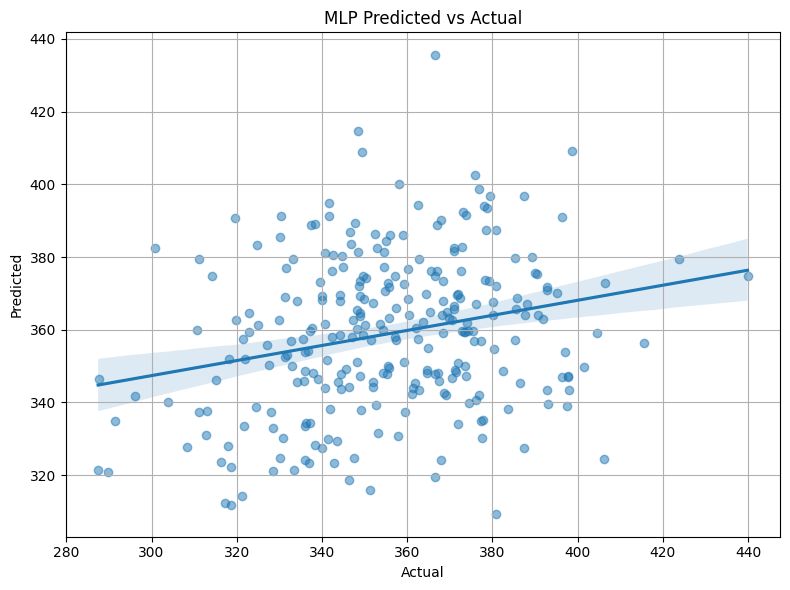

In [29]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

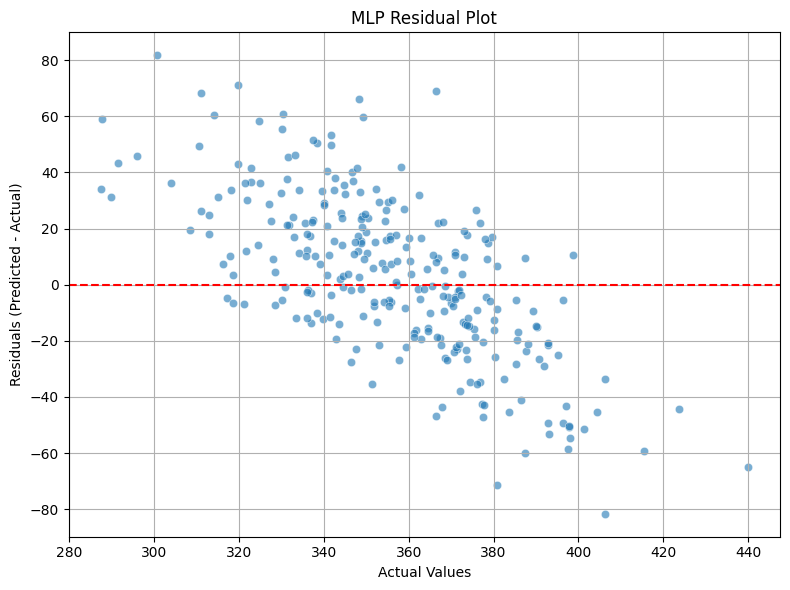

In [30]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

## Only Location

In [31]:
tt_loc= tt_data.drop(['BBD', 'LL',	'LW',	'PLH', 'PRT'], axis=1)
tt_loc.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr18_7976151,Chr3_32202833,Chr3_40181839,Chr6_46052745,Chr15_44305656,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,1,0,1,0,0,0,1
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,1,0,0,1,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,0,0,0,0,1,0,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,0,0,0,0,0,1,0,0,1
s101,0,0,0,0,0,2,2,0,0,0,...,0,0,0,0,0,0,0,1,0,1


In [32]:
tt_loc_dupe= tt_data.drop(['BBD', 'LL',	'LW',	'PLH', 'PRT'], axis=1)
tt_loc_dupe.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr18_7976151,Chr3_32202833,Chr3_40181839,Chr6_46052745,Chr15_44305656,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,1,0,1,0,0,0,1
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,1,0,0,1,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,0,0,0,0,1,0,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,0,0,0,0,0,1,0,0,1
s101,0,0,0,0,0,2,2,0,0,0,...,0,0,0,0,0,0,0,1,0,1


In [34]:
tt_y = tt_data.iloc[:, 1009:]
tt_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s1014,366.116
s1014,326.667
s101,385.915


In [36]:
X_tensor = torch.tensor(tt_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(tt_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [37]:
print(X_tensor.shape)

torch.Size([1094, 1005])


In [38]:
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [39]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-29 19:05:56,095] A new study created in memory with name: no-name-7a166ac1-f9a4-4b03-a7b6-054c9c6a0842
[I 2025-05-29 19:05:57,589] Trial 0 finished with value: 125425.390625 and parameters: {'hidden_size1': 200, 'dropout1': 0.03440058865712958, 'lr': 0.000987021646955384, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.006661831012019033, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout2': 0.08891263318501781}. Best is trial 0 with value: 125425.390625.
[I 2025-05-29 19:05:58,543] Trial 1 finished with value: 716.8541870117188 and parameters: {'hidden_size1': 200, 'dropout1': 0.0727072892462848, 'lr': 0.0015811187593306464, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.0007767331884039145, 'n_layers': 1}. Best is trial 1 with value: 716.8541870117188.


Early stopping at epoch 28


[I 2025-05-29 19:06:00,451] Trial 2 finished with value: 847.8793334960938 and parameters: {'hidden_size1': 300, 'dropout1': 0.09146450868617648, 'lr': 0.006839191683459866, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.005389288829821557, 'n_layers': 1}. Best is trial 1 with value: 716.8541870117188.
[I 2025-05-29 19:06:01,138] Trial 3 finished with value: 668.8779296875 and parameters: {'hidden_size1': 100, 'dropout1': 0.09398613573348265, 'lr': 0.0007310841347861087, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 3.134694255011657e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 3 with value: 668.8779296875.


Early stopping at epoch 50


[I 2025-05-29 19:06:01,971] Trial 4 finished with value: 793.6243896484375 and parameters: {'hidden_size1': 200, 'dropout1': 0.06921789994675523, 'lr': 0.001380591846137947, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.00017048562401797104, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 3 with value: 668.8779296875.


...

Early stopping at epoch 35


[I 2025-05-29 19:07:21,062] Trial 47 finished with value: 80331.1640625 and parameters: {'hidden_size1': 300, 'dropout1': 0.05029754319462114, 'lr': 0.0009724313214353728, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.00040204088790641787, 'n_layers': 1}. Best is trial 14 with value: 589.0824584960938.
[I 2025-05-29 19:07:21,805] Trial 48 finished with value: 996.271240234375 and parameters: {'hidden_size1': 300, 'dropout1': 0.015881977594076842, 'lr': 0.001702612999146564, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0006420006727008975, 'n_layers': 1}. Best is trial 14 with value: 589.0824584960938.


Early stopping at epoch 20


[I 2025-05-29 19:07:24,111] Trial 49 finished with value: 617.094970703125 and parameters: {'hidden_size1': 300, 'dropout1': 0.04636833272065822, 'lr': 0.00021905966257919284, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.001622575320719647, 'n_layers': 1}. Best is trial 14 with value: 589.0824584960938.


Early stopping at epoch 63
Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.04258544499850492, 'lr': 0.0002384440804545741, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.002056611562123053, 'n_layers': 1}


In [40]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='xgboost_onlyloc_mlp_prt.pth') # add the epochs and batch from best paramete

Training fold 1
Early stopping at epoch 55 for fold 1
Fold 1 validation loss: 585.1299
Training fold 2
Early stopping at epoch 48 for fold 2
Fold 2 validation loss: 862.6743
Training fold 3
Early stopping at epoch 75 for fold 3
Fold 3 validation loss: 520.5114
Training fold 4
Early stopping at epoch 58 for fold 4
Fold 4 validation loss: 611.1506
Training fold 5
Early stopping at epoch 42 for fold 5
Fold 5 validation loss: 705.2557
Training fold 6
Early stopping at epoch 40 for fold 6
Fold 6 validation loss: 548.7637
Training fold 7
Early stopping at epoch 45 for fold 7
Fold 7 validation loss: 599.8531
Training fold 8
Early stopping at epoch 53 for fold 8
Fold 8 validation loss: 582.8333
Training fold 9
Early stopping at epoch 46 for fold 9
Fold 9 validation loss: 647.2200
Training fold 10
Early stopping at epoch 46 for fold 10
Fold 10 validation loss: 509.5978

Average validation loss across all folds: 617.2990
Checkpoint saved as 'xgboost_onlyloc_mlp_prt.pth'.


In [41]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [42]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [43]:
tt_loc, X_holdout = tt_loc_dupe.align(X_holdout, join='inner', axis=1)

In [44]:
X_holdout.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr18_7976151,Chr3_32202833,Chr3_40181839,Chr6_46052745,Chr15_44305656,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,0,0,0,2,2,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s102,0,1,2,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
s110,2,0,0,0,2,0,0,2,1,0,...,1,0,0,0,0,1,0,0,0,1
s112,1,0,0,2,2,0,2,2,1,0,...,0,0,0,0,0,1,0,0,0,1
s113,2,0,0,2,2,0,0,0,1,0,...,1,0,2,0,1,1,0,0,0,1


In [45]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [46]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 801.7881
RMSE: 28.3159
MAE: 22.5927
R2: -0.2763
Holdout_Loss: 801.7881


In [47]:
pickle.dump(best_mlp_model, open("xgboost_onlyloc_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 349.88852
1 344.136 372.88516
2 351.481 346.27594
3 353.611 354.95758
4 390.342 376.11185
5 358.958 366.22742


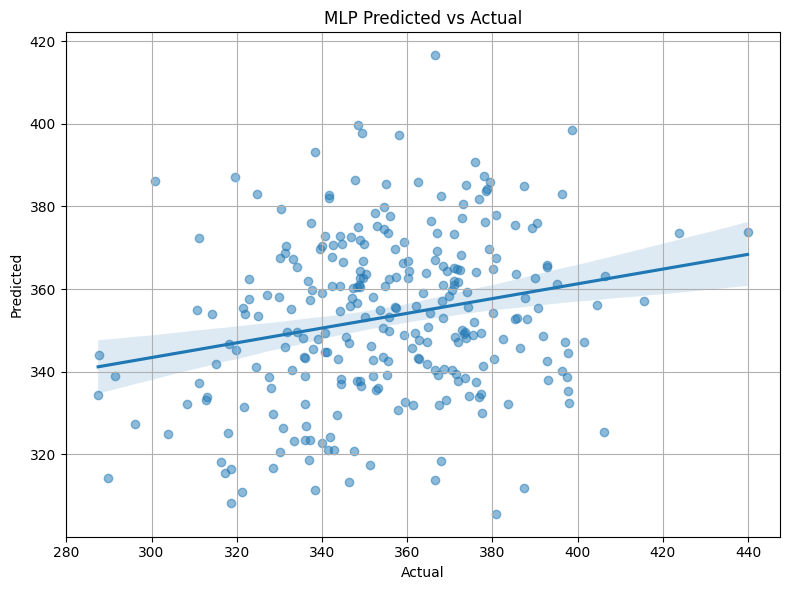

In [48]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

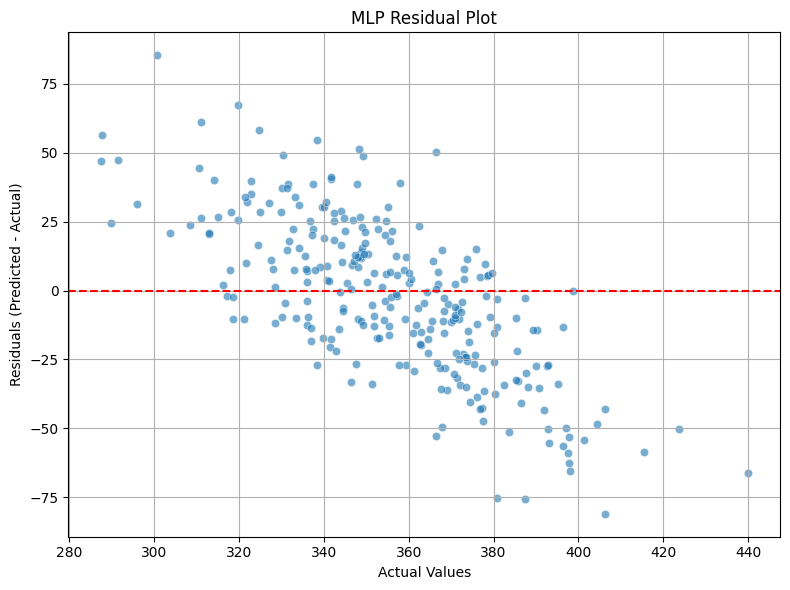

In [49]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

## Only SNPs

In [50]:
tt_snps = tt_data.iloc[:, 0:1000]
tt_snps.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr10_24459648,Chr9_49958169,Chr1_7217576,Chr14_17499839,Chr7_5661467,Chr18_7976151,Chr3_32202833,Chr3_40181839,Chr6_46052745,Chr15_44305656
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,0,1,0
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,0,1,0
s1014,2,2,0,2,2,0,0,2,1,2,...,1,0,0,0,0,0,0,0,0,0
s1014,2,2,0,2,2,0,0,2,1,2,...,1,0,0,0,0,0,0,0,0,0
s101,0,0,0,0,0,2,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [51]:
tt_snps_dupe = tt_data.iloc[:, 0:1000]
tt_snps_dupe.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr10_24459648,Chr9_49958169,Chr1_7217576,Chr14_17499839,Chr7_5661467,Chr18_7976151,Chr3_32202833,Chr3_40181839,Chr6_46052745,Chr15_44305656
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,0,1,0
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,0,1,0
s1014,2,2,0,2,2,0,0,2,1,2,...,1,0,0,0,0,0,0,0,0,0
s1014,2,2,0,2,2,0,0,2,1,2,...,1,0,0,0,0,0,0,0,0,0
s101,0,0,0,0,0,2,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
tt_y = tt_data.iloc[:, 1009:]
tt_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s1014,366.116
s1014,326.667
s101,385.915


In [53]:
X_tensor = torch.tensor(tt_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(tt_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [54]:
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [55]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-29 19:10:27,762] A new study created in memory with name: no-name-1041af1d-432d-411b-9cb6-a595f36e322f
[I 2025-05-29 19:10:28,826] Trial 0 finished with value: 789.6234130859375 and parameters: {'hidden_size1': 100, 'dropout1': 0.06461157864057578, 'lr': 0.002436270659124523, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 1.3019059361271036e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 0 with value: 789.6234130859375.


Early stopping at epoch 27


[I 2025-05-29 19:10:30,153] Trial 1 finished with value: 127233.578125 and parameters: {'hidden_size1': 100, 'dropout1': 0.03157561351096177, 'lr': 0.00020731245022357933, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.00010707726044407346, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 789.6234130859375.
[I 2025-05-29 19:10:32,128] Trial 2 finished with value: 706.63623046875 and parameters: {'hidden_size1': 100, 'dropout1': 0.07427590040714493, 'lr': 0.000450349115399642, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 2.5980146510441452e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.04663773749245409}. Best is trial 2 with value: 706.63623046875.


Early stopping at epoch 41


[I 2025-05-29 19:10:32,759] Trial 3 finished with value: 639.087158203125 and parameters: {'hidden_size1': 200, 'dropout1': 0.02052162464972193, 'lr': 0.0007799981041418611, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 4.150914683497734e-05, 'n_layers': 1}. Best is trial 3 with value: 639.087158203125.


...

Early stopping at epoch 96


[I 2025-05-29 19:11:34,122] Trial 42 finished with value: 728.6954345703125 and parameters: {'hidden_size1': 300, 'dropout1': 0.06165519028747497, 'lr': 0.00013112577879455817, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.002891526049094684, 'n_layers': 1}. Best is trial 38 with value: 595.9261474609375.
[I 2025-05-29 19:11:35,369] Trial 43 finished with value: 599.2271118164062 and parameters: {'hidden_size1': 300, 'dropout1': 0.05182329679626373, 'lr': 0.00021468073427842541, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.004038947890550369, 'n_layers': 1}. Best is trial 38 with value: 595.9261474609375.
[I 2025-05-29 19:11:36,618] Trial 44 finished with value: 617.8311157226562 and parameters: {'hidden_size1': 300, 'dropout1': 0.05300826003978547, 'lr': 0.00019733180711529257, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.00414497660795219, 'n_layers': 1}. Best is trial 38 with value: 595.9261474609375.
[I 2025-05-29 19:11:37,864] Trial 4

Early stopping at epoch 97


[I 2025-05-29 19:11:45,370] Trial 49 finished with value: 662.325927734375 and parameters: {'hidden_size1': 300, 'dropout1': 0.08365996835223427, 'lr': 0.00010468553715078832, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0018738516545699884, 'n_layers': 1}. Best is trial 38 with value: 595.9261474609375.


Best hyperparameters: {'hidden_size1': 200, 'dropout1': 0.08479620916364776, 'lr': 0.00040409942852905924, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0030905956085442382, 'n_layers': 1}


In [56]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='xgboost_onlysnps_mlp_prt.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 78 for fold 1
Fold 1 validation loss: 594.6989
Training fold 2
Early stopping at epoch 58 for fold 2
Fold 2 validation loss: 863.7715
Training fold 3
Early stopping at epoch 65 for fold 3
Fold 3 validation loss: 548.9781
Training fold 4
Early stopping at epoch 45 for fold 4
Fold 4 validation loss: 616.4417
Training fold 5
Early stopping at epoch 44 for fold 5
Fold 5 validation loss: 731.1499
Training fold 6
Early stopping at epoch 50 for fold 6
Fold 6 validation loss: 530.7028
Training fold 7
Early stopping at epoch 55 for fold 7
Fold 7 validation loss: 609.0024
Training fold 8
Early stopping at epoch 66 for fold 8
Fold 8 validation loss: 570.7260
Training fold 9
Early stopping at epoch 55 for fold 9
Fold 9 validation loss: 641.9318
Training fold 10
Early stopping at epoch 59 for fold 10
Fold 10 validation loss: 511.7970

Average validation loss across all folds: 621.9200
Checkpoint saved as 'xgboost_onlysnps_mlp_prt.pth'.


In [57]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [58]:
tt_snps_dupe, X_holdout = tt_snps_dupe.align(X_holdout, join='inner', axis=1)

In [59]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

AttributeError: 'numpy.ndarray' object has no attribute 'to_numpy'

In [60]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 798.9583
RMSE: 28.2658
MAE: 22.4683
R2: -0.2718
Holdout_Loss: 798.9583


In [61]:
pickle.dump(best_mlp_model, open("xgboost_onlysnps_mlp_prt.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 355.712 349.03387
1 344.136 375.09198
2 351.481 346.02948
3 353.611 356.71704
4 390.342 381.54446
5 358.958 366.15295


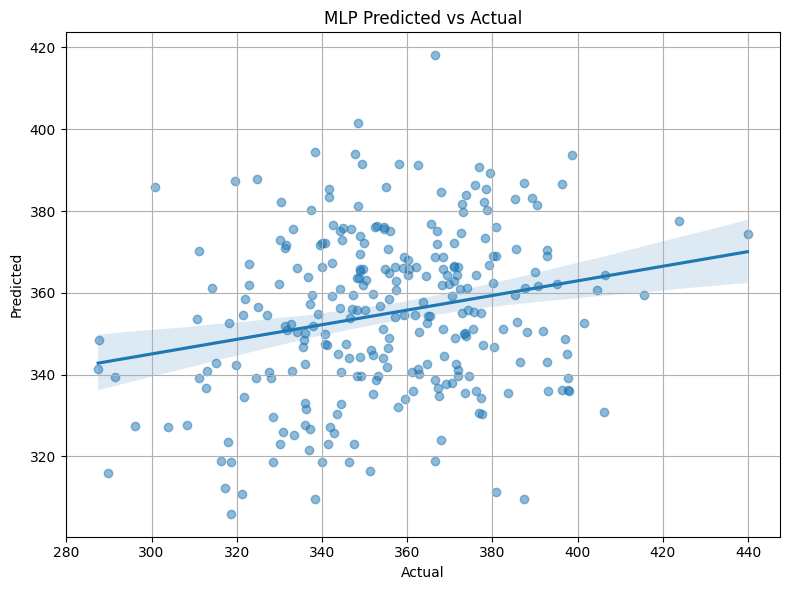

In [62]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

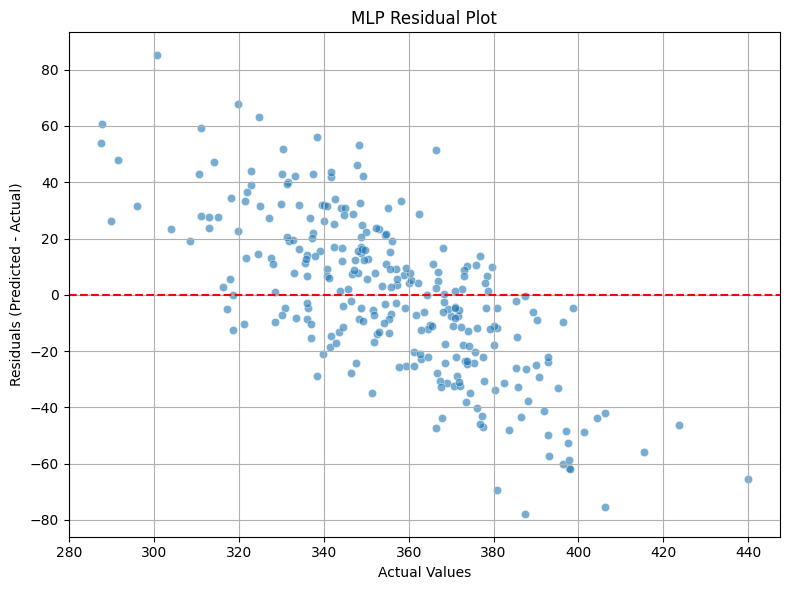

In [63]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()